# Task 1: Frequency-based baseline

## load train and test dataset from json

In [ ]:
import json


def extract_vocabulary_from_json(file_path):
    """Parses a standard JSON array file containing malware analysis sequences

    and extracts all unique API call strings.

    Args:
        file_path (str): Path to the standard JSON dataset file.

    Returns:
        set: A set containing all unique API call strings identified in the dataset.
    """
    vocab = set()

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            # Load the entire JSON array directly
            dataset = json.load(f)

            # Iterate over each sample object in the dataset list
            for sample in dataset:
                api_sequence = sample.get("api_call_sequence", [])
                vocab.update(api_sequence)

    except FileNotFoundError:
        print(f"Error: The file at '{file_path}' was not found.")
    except json.JSONDecodeError:
        print(
            f"Error: Failed to decode JSON from '{file_path}'. Please check its structural validity."
        )

    return vocab

In [ ]:
# ==================== Execution and Structural Analysis ====================

# Define file paths to your train and test datasets
# Replace these strings with your actual local file filenames
train_path = "train.json"
test_path = "test.json"

# Process both datasets to build their respective vocabularies
train_vocab = extract_vocabulary_from_json(train_path)
test_vocab = extract_vocabulary_from_json(test_path)

# Union both sets to determine the global vocabulary footprint
global_vocab = train_vocab.union(test_vocab)

# Calculate Out-of-Vocabulary (OOV) tokens that only appear at inference time
oov_in_test = test_vocab - train_vocab
oov_in_train = train_vocab - test_vocab
# Print descriptive statistical answers for your lab report
print("=== Dataset Vocabulary Profile ===")
print(f"Unique API calls in Training Set : {len(train_vocab)}")
print(f"Unique API calls in Test Set     : {len(test_vocab)}")
print(f"Global Vocabulary Size (Merged)  : {len(global_vocab)}")
print(f"API calls occurring ONLY in Test : {len(oov_in_test)}")
print(f"API calls occurring ONLY in Train: {len(oov_in_train)}")

# Display a brief sample of OOV tokens if they exist
if len(oov_in_test) > 0:
    print(f"\nSample of Out-of-Vocabulary APIs (Unseen in Train):")
    print(list(oov_in_test)[:10])

    # Display a brief sample of OOV tokens if they exist
if len(oov_in_train) > 0:
    print(f"\nSample of Out-of-Vocabulary APIs (Unseen in Test):")
    print(list(oov_in_train)[:10])


In [ ]:
from collections import Counter
import pandas as pd

def generate_frequency_dataframe(dataset, features):
    """Generates a frequency-based DataFrame mapped strictly to the training vocabulary."""
    matrix = []
    labels = []

    for sample in dataset:
        # Count frequencies of each API call in the current sequence
        counts = Counter(sample.get("api_call_sequence", []))

        # Extract counts strictly for the specified training feature columns
        # Unseen test APIs (OOV) are naturally ignored here as they are not in 'features'
        row_counts = [counts[api] for api in features]

        matrix.append(row_counts)
        labels.append(sample.get("is_malware"))

    # Create the DataFrame with API terms as columns
    df = pd.DataFrame(matrix, columns=features)
    # Append the target label column
    df["is_malware_label"] = labels
    return df

In [ ]:
# Define your input file paths
# 1. Load the dataset files
with open(train_path, "r") as f:
    train_data = json.load(f)

with open(test_path, "r") as f:
    test_data = json.load(f)
#print length of datasets to confirm loading
print(f"Number of samples in Training Set: {len(train_data)}")
print(f"Number of samples in Test Set:     {len(test_data)}")
# ==================== Execution ====================
# Generate frequency dataframes for both partitions
feature_columns = sorted(list(train_vocab))
df_train = generate_frequency_dataframe(train_data, feature_columns)
df_test = generate_frequency_dataframe(test_data, feature_columns)

# ==================== Verification ====================
print("=== Frequency DataFrames Shape ===")
print(f"Training DataFrame Shape: {df_train.shape}")  # Expected columns: 258 APIs + 1 label
print(f"Test DataFrame Shape:     {df_test.shape}")  # Expected columns: 258 APIs + 1 label

# Display a snippet of the training dataframe
df_train.head()

## One issueof this frequency-based approach is that it creates sparse vectors (i.e., vectors with many zeros per row): how many non-zero elements per row do you have on average in the training set? How many in the test set2? What is the ratio with respect to the number of elements per row?

In [ ]:
# Assuming df_train and df_test have 258 API columns and 1 label column ('is_malware')
# We select only the API feature columns for sparsity analysis

feature_cols = [col for col in df_train.columns if col != "is_malware_label"]
num_features = len(feature_cols)  # This should be 258
print(f"Number of API feature columns: {num_features}")

# 1. Calculate non-zero elements per row
# (df[feature_cols] != 0).sum(axis=1) counts non-zero entries for each row
train_nonzero_per_row = (df_train[feature_cols] != 0).sum(axis=1)
test_nonzero_per_row = (df_test[feature_cols] != 0).sum(axis=1)

# 2. Compute the average number of non-zero elements
avg_nonzero_train = train_nonzero_per_row.mean()
avg_nonzero_test = test_nonzero_per_row.mean()

# 3. Compute the ratio with respect to the total number of elements per row (258)
ratio_train = avg_nonzero_train / num_features
ratio_test = avg_nonzero_test / num_features

# ==================== Verification & Results ====================
print("=== Sparsity & Non-Zero Element Analysis ===")
print(f"Total number of features per row: {num_features}\n")

print(
    f"Training Set Average Non-Zero Elements: {avg_nonzero_train:.2f} rows"
)
print(f"Training Set Non-Zero Ratio           : {ratio_train:.4f} ({ratio_train*100:.2f}%)")
print(f"Training Set Sparsity (Zero Ratio)    : {(1 - ratio_train)*100:.2f}%\n")

print(f"Test Set Average Non-Zero Elements    : {avg_nonzero_test:.2f} rows")
print(f"Test Set Non-Zero Ratio               : {ratio_test:.4f} ({ratio_test*100:.2f}%)")
print(f"Test Set Sparsity (Zero Ratio)        : {(1 - ratio_test)*100:.2f}%")

## Finally, feed the frequency-based datasets to a classifier. Choose any classifier here (shallow non-neural; shallow neural; deep neural).

## Q: Report how you chose the hyperparameters of your classifier, and the final performance on the test set.
## Q: Is the final performance good- even ignoring the order of API calls and handling very sparse vectors?

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# ==================== 1. Prepare Data ====================
# Separate features (X) and labels (y)
# Ensure your column name matches your dataframe ('is_malware_label' or 'is_malware')
label_col = "is_malware_label"

X_train = df_train.drop(columns=[label_col])
y_train = df_train[label_col]

# Check the exact distribution of classes in the training set
class_counts = df_train[label_col].value_counts()
class_percentages = df_train[label_col].value_counts(normalize=True) * 100

print("=== Training Set Class Distribution ===")
for label, count in class_counts.items():
    label_name = "Goodware (0)" if label == 0 else "Malware (1)"
    percentage = class_percentages[label]
    print(f"{label_name:<13} : {count:<5} samples ({percentage:.2f}%)")

X_test = df_test.drop(columns=[label_col])
y_test = df_test[label_col]

print(f"Training features shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test features shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# ==================== 2. Hyperparameter Tuning ====================
# Define a grid of hyperparameters to experiment with
param_grid = {
    "n_estimators": [50, 100, 200],  # Number of trees in the forest
    "max_depth": [10, 20, None],  # Maximum depth of the tree
    "criterion": ["gini", "entropy"],  # Split evaluation metric
}

print("Starting Grid Search for Random Forest Hyperparameters...")
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# Use 3-fold Cross-Validation to systematically find the best parameters
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=3, scoring="f1", n_jobs=4, verbose=2
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters Found: {grid_search.best_params_}\n")

# ==================== 3. Evaluation on Test Set ====================
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Generate final performance reports
print("=== Final Performance on Test Set ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# Task 2: Feed Forward Neural Network (FFNN)

## Q:Do you have the same number of API calls for each sequence? If not, is the distribution of the number of API calls per sequence in the training set the same as the test one?

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract sequence lengths from the training and test datasets
# This utilizes a list comprehension to measure the length of each "api_call_sequence"
train_lengths = [len(sample["api_call_sequence"]) for sample in train_data]
test_lengths = [len(sample["api_call_sequence"]) for sample in test_data]

# Convert lists to Pandas Series to easily compute descriptive statistics
train_series = pd.Series(train_lengths)
test_series = pd.Series(test_lengths)

print("=== Training Set Sequence Length Stats ===")
print(train_series.describe())
print("\n=== Test Set Sequence Length Stats ===")
print(test_series.describe())

# 2. Plot the density histogram to compare distributions
plt.hist(
    train_lengths,
    bins=50,
    alpha=0.6,
    label="Train Set",
    density=True,
    color="#1f77b4",
)
plt.hist(
    test_lengths,
    bins=50,
    alpha=0.6,
    label="Test Set",
    density=True,
    color="#ff7f0e",
)

# Configure plot labels and styling
plt.title("Distribution of API Call Sequence Lengths", fontsize=12)
plt.xlabel("Number of API Calls per Sequence (Sequence Length)", fontsize=10)
plt.ylabel("Density", fontsize=10)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# 3. Save the plot for the lab report
plt.savefig("api_sequence_length_distribution.pdf", dpi=300)
print(
    "\n🎉 Visualization successfully saved as 'api_sequence_length_distribution.png'!"
)

## One last problem before running the FFNN: The API calls are strings, and hence you are handling categorical features. As you learned during lectures, you need to find a mapping from the categorical features to a numerical space the network can process. Use two approaches:


### Define the functions to be used for truncation and padding

In [ ]:
import pandas as pd

max_sequence_length = 90
pad_token = "[PAD]"

def pad_or_truncate_dataset_to_df(dataset, max_len=max_sequence_length, pad_token=pad_token):
    """Enforces a fixed length on raw API string sequences via truncation or

    padding, and returns a structured pandas DataFrame.
    """
    aligned_sequences = []
    labels = []

    for sample in dataset:
        # Get the raw string sequence
        seq = sample["api_call_sequence"]

        # Pure truncation or padding logic on strings
        if len(seq) >= max_len:
            aligned_seq = seq[:max_len]
        else:
            aligned_seq = seq + [pad_token] * (max_len - len(seq))

        aligned_sequences.append(aligned_seq)
        labels.append(sample["is_malware"])

    # Create DataFrame with columns from 0 to max_len-1
    df = pd.DataFrame(aligned_sequences, columns=[i for i in range(max_len)])

    # Append the label column
    df["is_malware"] = labels

    return df

### preprocess the training set and test set

In [ ]:
# define maximum sequence length (90) and use your api_to_id mapping to transform both datasets

# Process both partitions to enforce fixed sequence length
df_train_TP = pad_or_truncate_dataset_to_df(train_data, max_len=max_sequence_length)
df_test_TP = pad_or_truncate_dataset_to_df(test_data, max_len=max_sequence_length)
print("=== Sample of Transformed Training DataFrame ===")
print(df_train_TP.shape)
print(df_test_TP.shape)
print(df_train_TP.head(1))

## Sequential identifiers: map each API call to an arbitrary sequential ID. Remember to use consistent IDs (if you say that RegOpenKeyExA is 1, then it is always 1!).

In [ ]:
# Initialize the mapping dictionary, strictly reserving 0 for the padding token [PAD]
api_to_id = {pad_token: 0}

# Populate the dictionary with unique APIs from your train_vocab set
# Since train_vocab is a set, iterating through it naturally provides an arbitrary but consistent order
for current_id, api in enumerate(train_vocab, start=1):
    api_to_id[api] = current_id

# Verify the vocabulary generation
print(f"Total tokens in vocabulary (including [PAD]): {len(api_to_id)}")
print("Sample mappings (First 5 items):", dict(list(api_to_id.items())[:5]))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def transform_dataframe_to_sid(df, mapping, max_len):
    """Transforms a padded/truncated DataFrame of API strings into numerical X

    and y NumPy arrays using the mapping dictionary.
    """
    # 1. Select only the columns representing the sequential API calls (0 to 89)
    api_cols = [i for i in range(max_len)]

    # 2. Map the strings to historical sequential IDs element-wise
    # Using .get(x, 0) to safely assign 0 to any Out-Of-Vocabulary tokens in the test set
    X_mapped = df[api_cols].map(lambda x: mapping.get(x, 0))

    # 3. Convert to standard continuous NumPy arrays for deep learning heads
    X = X_mapped.to_numpy().astype(np.int64)
    y = df["is_malware"].to_numpy().astype(np.int64)

    return X, y

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Split the 16325 samples into pure train (80%) and validation (20%)
# Use new explicit variable names to avoid overwriting df_train_TP
df_train_pure, df_val_pure = train_test_split(
    df_train_TP,
    test_size=0.20,
    random_state=42,
    stratify=df_train_TP["is_malware"],
)

# 2. Process all partitions using your transform function
X_train, y_train = transform_dataframe_to_sid(
    df_train_pure, api_to_id, max_len=max_sequence_length
)
X_val, y_val = transform_dataframe_to_sid(
    df_val_pure, api_to_id, max_len=max_sequence_length
)
X_test, y_test = transform_dataframe_to_sid(
    df_test_TP, api_to_id, max_len=max_sequence_length
)

# 3. Verify the final corrected shapes of your matrices
print("=== Processed Data Shapes ===")
print(
    f"X_train shape: {X_train.shape} (Corrected: 16325 * 0.8 = 13060, 90)"
)
print(f"y_train shape: {y_train.shape} (Corrected: 13060,)")
print(f"X_val shape:    {X_val.shape}   (Corrected: 16325 * 0.2 = 3265, 90)")
print(f"y_val shape:    {y_val.shape}   (Corrected: 3265,)")
print(f"X_test shape:  {X_test.shape}  (Should be: (6505, 90))")
print(f"y_test shape:  {y_test.shape}  (Should be: (6505,))")

### define a ffnn model for learnable embedding approach

In [ ]:
import torch
import torch.nn as nn


class UnifiedFfnn(nn.Module):

    def __init__(
        self,
        vocab_size,
        max_len=90,
        use_embedding=True,
        embedding_dim=32,
        hidden_dim=128,
        dropout_rate=0.5,
    ):
        """Unified FFNN supporting both Sequential Identifiers directly and

        Learnable Embeddings with an added Embedding-level Dropout.
        """
        super().__init__()
        self.use_embedding = use_embedding

        if self.use_embedding:
            # Approach B: Learnable Embeddings
            self.embedding = nn.Embedding(
                num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=0
            )
            self.emb_dropout = nn.Dropout(dropout_rate)
            input_dim = max_len * embedding_dim
        else:
            # Approach A: Sequential Identifiers fed directly
            self.embedding = None
            self.emb_dropout = None
            input_dim = max_len

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer_dropout = nn.Dropout(dropout_rate)  # FC layer dropout
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        if self.use_embedding:
            x = self.embedding(x)  # (batch_size, max_len, embedding_dim)
            x = self.emb_dropout(
                x
            )  # <-- Solution 1: Randomly zero out 50% of the dense channels
        else:
            x = x.float()

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.layer_dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, TensorDataset

# =========================================================================
# EARLY STOPPING CLASS IMPLEMENTATION (With English Comments)
# =========================================================================
class EarlyStopping:
    """
    Early Stopping regularizer to safely terminate training when validation loss 
    stagnates or diverges to prevent overfitting.
    """
    def __init__(self, patience=5, delta=0):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf

    def __call__(self, val_loss, model, save_path="best_checkpoint.pt"):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model, save_path)
        elif score < self.best_score + self.delta:
            # No optimization improvement detected; consume 1 patience point
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True  # Trigger the Boolean signal to break training loop
        else:
            # Validation performance improved! Refresh best score and reset patience counter
            self.best_score = score
            self.save_checkpoint(val_loss, model, save_path)
            self.counter = 0

    def save_checkpoint(self, val_loss, model, save_path):
        """Saves model weights locally when there is a sequential decrease in validation loss."""
        torch.save(model.state_dict(), save_path)
        self.val_loss_min = val_loss


# =========================================================================
# INTEGRATED EXECUTION ENGINE V5 (With Early Stopping Defense)
# =========================================================================
import copy
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,  # Used to compute PR-AUC
    classification_report,    # Formats the precision/recall/f1 table natively
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,            # Used to compute ROC-AUC
)
from torch.utils.data import DataLoader, TensorDataset


# =========================================================================
# INTEGRATED EXECUTION ENGINE V7 (Ultimate Academic & Evaluation Edition)
# =========================================================================
def run_hyperparameter_tuning(
    X_train_arr,
    y_train_arr,
    X_val_arr,
    y_val_arr,
    X_test_arr,
    y_test_arr,
    experiments_list,
    model_class,
    epochs=30,
):
    """Universal grid-search engine that executes in-memory Early Stopping rollbacks

    and prints fully structured academic evaluation reports (with Confusion Matrix) live.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(
        f"📡 Execution Engine V7 (Comprehensive Report System) active on Device: {device}"
    )

    # Cast all split data matrices into standard PyTorch Tensors
    X_train_t = torch.tensor(X_train_arr, dtype=torch.long)
    y_train_t = torch.tensor(y_train_arr, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val_arr, dtype=torch.long)
    y_val_t = torch.tensor(y_val_arr, dtype=torch.float32).unsqueeze(1)

    # Keep Test partition isolated on device for direct blind inference later
    X_test_t = torch.tensor(X_test_arr, dtype=torch.long).to(device)
    y_test_t = torch.tensor(y_test_arr, dtype=torch.float32).unsqueeze(1)

    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False
    )

    performance_report = []
    loss_histories = {}

    for config in experiments_list:
        exp_name = config["name"]
        print(f"\n▶️ Optimizing Framework for: {exp_name}...")

        train_loader = DataLoader(
            TensorDataset(X_train_t, y_train_t),
            batch_size=config["batch"],
            shuffle=True,
        )

        model = model_class(**config["model_kwargs"]).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])

        history_train_loss = []
        history_val_loss = []

        best_val_loss = np.inf  # Fully compatible with NumPy 2.0+
        best_model_state = None
        patience = 5
        patience_counter = 0

        start_time = time.time()

        for epoch in range(epochs):
            # --- Training Routine ---
            model.train()
            running_train_loss = 0.0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                running_train_loss += loss.item() * batch_x.size(0)

            epoch_train_loss = running_train_loss / len(train_loader.dataset)
            history_train_loss.append(epoch_train_loss)

            # --- Validation Loss Routine ---
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for v_batch_x, v_batch_y in val_loader:
                    v_batch_x, v_batch_y = v_batch_x.to(device), v_batch_y.to(device)
                    v_outputs = model(v_batch_x)
                    v_loss = criterion(v_outputs, v_batch_y)
                    running_val_loss += v_loss.item() * v_batch_x.size(0)

            epoch_val_loss = running_val_loss / len(val_loader.dataset)
            history_val_loss.append(epoch_val_loss)

            if epoch_val_loss < best_val_loss:
                best_val_loss = epoch_val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(
                        f"    🛑 Early stopping triggered at Epoch {epoch+1}."
                    )
                    break

        duration = time.time() - start_time
        loss_histories[exp_name] = {
            "train": history_train_loss,
            "val": history_val_loss,
        }

        # --- 🔄 RAM Parameter Rollback ---
        model.load_state_dict(best_model_state)
        model.eval()

        with torch.no_grad():
            # 1. Evaluate on Validation Set (Switched to Academic Macro Mode)
            val_inputs = X_val_t.to(device)
            val_logits = model(val_inputs)
            val_preds = (torch.sigmoid(val_logits) >= 0.5).cpu().numpy().astype(int)
            val_true = y_val_t.numpy().astype(int)
            val_f1_macro = f1_score(
                val_true, val_preds, average="macro", zero_division=0
            )

            # 2. Automated Double-Blind Inference on pristine Test Set
            test_logits = model(X_test_t)
            test_probs = torch.sigmoid(test_logits).cpu().numpy()  # Real continuous probabilities
            test_preds = (test_probs >= 0.5).astype(int)
            test_true = y_test_t.cpu().numpy().astype(int)

            # --- Structural Metrics Calculations ---
            test_acc = accuracy_score(test_true, test_preds)
            test_f1_macro = f1_score(
                test_true, test_preds, average="macro", zero_division=0
            )
            test_roc_auc = roc_auc_score(test_true, test_probs)
            test_pr_auc = average_precision_score(test_true, test_probs)
            test_cm = confusion_matrix(test_true, test_preds)

        tn, fp, fn, tp = test_cm.ravel()
        meta_params = config["model_kwargs"]
        emb_display = (
            str(meta_params.get("embedding_dim", "N/A"))
            if meta_params.get("use_embedding", True)
            else "None (Raw IDs)"
        )

        # =========================================================================
        # 📊 LIVE ACADEMIC DISCOVERY OUTPUT (Perfect Replication of Target Layout)
        # =========================================================================
        print("\n" + "=" * 25 + f" [EVALUATION REPORT: {exp_name}] " + "=" * 25)
        
        # Part A: Standardized Precision / Recall / F1 classification report table
        print(classification_report(test_true, test_preds, target_names=["Benign", "Malware"], zero_division=0))
        # Part B: Structured 2x2 Confusion Matrix grid
        print("Confusion Matrix:")
        print(f"                 Predicted Benign   Predicted Malware")
        print(f"Actual Benign          {tn:<18} {fp:<18}")
        print(f"Actual Malware         {fn:<18} {tp:<18}\n")
        
        # Part C: Advanced comprehensive performance indicators (Formatted to 4 decimals)
        print(f"F1-macro : {test_f1_macro:.4f}")
        print(f"ROC-AUC  : {test_roc_auc:.4f}")
        print(f"PR-AUC   : {test_pr_auc:.4f}")
        print("=" * 76)

        # Append structured records to populate the definitive dataframe later
        performance_report.append(
            {
                "Experiment": exp_name,
                "Emb Dim": emb_display,
                "Batch": config["batch"],
                "Val Macro F1": f"{val_f1_macro*100:.2f}%",
                "TEST Acc": f"{test_acc*100:.2f}%",
                "TEST Macro F1": f"{test_f1_macro*100:.2f}%",
                "TEST ROC-AUC": f"{test_roc_auc*100:.2f}%",
                "TEST PR-AUC": f"{test_pr_auc*100:.2f}%",
                "Confusion Matrix (TP/FP/FN/TN)": f"[TP:{tp} FP:{fp} FN:{fn} TN:{tn}]",
                "Time": f"{duration:.1f}s",
            }
        )

    return pd.DataFrame(performance_report), loss_histories

In [ ]:
import os
import matplotlib.pyplot as plt


def plot_tuning_curves(loss_histories, save_filename="hyperparameter_tuning_curves.png"):
    """
    Generates structured comparative convergence plots from extracted tuning logs.
    Automatically adapts the X-axis per plot to support Early Stopping truncation
    and securely exports the final full canvas to a high-resolution local file.
    """
    num_plots = len(loss_histories)
    cols = 3  # Maximum of 3 subplots per row for optimal visibility
    rows = (num_plots + cols - 1) // cols

    # Dynamically scale total figure canvas height based on required row footprint
    plt.figure(figsize=(18, 4 * rows))

    for idx, (exp_name, histories) in enumerate(loss_histories.items(), start=1):
        plt.subplot(rows, cols, idx)

        # Dynamically extract the actual executed epochs to support early stopping
        actual_epochs = len(histories["train"])
        epoch_range = range(1, actual_epochs + 1)

        # Plot training loss tracking path with blue circular markers
        plt.plot(
            epoch_range,
            histories["train"],
            label="Train Loss",
            marker="o",
            color="royalblue",
            linewidth=2,
        )

        # Plot validation loss tracking path with crimson square markers
        plt.plot(
            epoch_range,
            histories["val"],
            label="Val Loss",
            marker="s",
            color="crimson",
            linewidth=2,
        )

        # Graph structural aesthetics and layout formatting
        plt.title(exp_name, fontsize=10, fontweight="bold", pad=8)
        plt.xlabel("Epochs", fontsize=9)
        plt.ylabel("Loss Score", fontsize=9)
        
        # Adapt ticks intelligently to avoid overcrowded label sequences
        if actual_epochs <= 15:
            plt.xticks(epoch_range)
        else:
            plt.xticks(range(1, actual_epochs + 1, max(1, actual_epochs // 10)))
            
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(fontsize=9)

    plt.tight_layout()
    
    # =========================================================================
    # 💾 CRITICAL EXPORT STAGE (Saves the plot securely before plt.show clears memory)
    # =========================================================================
    # dpi=300: High resolution standard for academic papers/theses
    # bbox_inches='tight': Ensures legends, titles and axis tags are never cropped
    plt.savefig(save_filename, dpi=300, bbox_inches="tight")
    print(f"💾 Absolute Grid Figures successfully saved at: '{os.path.abspath(save_filename)}'")
    
    # Finally, project the matrix display on the active screen
    plt.show()

In [ ]:
VOCAB_SIZE = len(api_to_id)
EPOCHS = 30  # Max upper bound capacity (Early stopping handles local truncation)

# Balanced Multi-Dimensional Hyperparameter Search Grid (Total: 16 Configurations)
# Controlled Constants: Learning Rate = 0.001 | Dropout = 0.5
assignment_experiments_grid = [
    # =========================================================================
    # 1. APPROACH A: Sequential Identifiers (4 Baseline Combinations)
    # Matrix: Hidden Dim (16, 32) x Batch Size (32, 64)
    # =========================================================================
    {
        "batch": 32, "lr": 0.001, "name": "Case 1: Seq ID (H16 | Batch 32)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": False, "embedding_dim": 8, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 1: Seq ID (H16 | Batch 64)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": False, "embedding_dim": 8, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 32, "lr": 0.001, "name": "Case 1: Seq ID (H32 | Batch 32)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": False, "embedding_dim": 8, "hidden_dim": 32, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 1: Seq ID (H32 | Batch 64)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": False, "embedding_dim": 8, "hidden_dim": 32, "dropout_rate": 0.5}
    },

    # =========================================================================
    # 2. APPROACH B: Learnable Embeddings (12 Full-Permutation Combinations)
    # Matrix: Hidden Dim (16, 32) x Embedding Dim (8, 16, 32) x Batch Size (32, 64)
    # =========================================================================
    # --- SUBGROUP B1: Hidden Capacity = 16 ---
    {
        "batch": 32, "lr": 0.001, "name": "Case 2: Emb (H16 | B32 | Dim 8)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 8, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 2: Emb (H16 | B64 | Dim 8)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 8, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 32, "lr": 0.001, "name": "Case 2: Emb (H16 | B32 | Dim 16)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 16, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 2: Emb (H16 | B64 | Dim 16)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 16, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 32, "lr": 0.001, "name": "Case 2: Emb (H16 | B32 | Dim 32)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 32, "hidden_dim": 16, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 2: Emb (H16 | B64 | Dim 32)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 32, "hidden_dim": 16, "dropout_rate": 0.5}
    },

    # --- SUBGROUP B2: Hidden Capacity = 32 ---
    {
        "batch": 32, "lr": 0.001, "name": "Case 2: Emb (H32 | B32 | Dim 8)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 8, "hidden_dim": 32, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 2: Emb (H32 | B64 | Dim 8)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 8, "hidden_dim": 32, "dropout_rate": 0.5}
    },
    {
        "batch": 32, "lr": 0.001, "name": "Case 2: Emb (H32 | B32 | Dim 16)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 16, "hidden_dim": 32, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 2: Emb (H32 | B64 | Dim 16)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 16, "hidden_dim": 32, "dropout_rate": 0.5}
    },
    {
        "batch": 32, "lr": 0.001, "name": "Case 2: Emb (H32 | B32 | Dim 32)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 32, "hidden_dim": 32, "dropout_rate": 0.5}
    },
    {
        "batch": 64, "lr": 0.001, "name": "Case 2: Emb (H32 | B64 | Dim 32)",
        "model_kwargs": {"vocab_size": VOCAB_SIZE, "max_len": 90, "use_embedding": True, "embedding_dim": 32, "hidden_dim": 32, "dropout_rate": 0.5}
    }
]

# =========================================================================
# PIPELINE EXECUTION
# =========================================================================
# Executing grid benchmarking using Engine V5 (Safe early stopping + checkpoint loading)
# Pass X_test and y_test straight into the arguments payload
df_final_matrix, complete_histories = run_hyperparameter_tuning(
    X_train_arr=X_train,
    y_train_arr=y_train,
    X_val_arr=X_val,
    y_val_arr=y_val,
    X_test_arr=X_test,  # Loaded directly into double-blind monitoring
    y_test_arr=y_test,
    experiments_list=assignment_experiments_grid,
    model_class=UnifiedFfnn,
    epochs=EPOCHS,
)

print("\n" + "=" * 35 + " 📊 DEFINITIVE CROSS-VAL AND BLIND TEST MATRIX " + "=" * 35)
print(df_final_matrix.to_string(index=False))

# Render curves with absolute resilience against dynamic early stopping cuts
plot_tuning_curves(complete_histories)


# Task 3: Recursive Neural Network (RNN)

## FFNN cannot model well sequences. Hence, try using a Recursive Neural Network (RNN) to model your problem.

### define a Simple one-directional RNN

In [ ]:
import os
import random
import numpy as np
import torch

def seed_everything(seed=42):
    # 1. Set seed for Python's built-in random module
    random.seed(seed)
    
    # 2. Set seed for NumPy operations
    np.random.seed(seed)
    
    # 3. Set seed for PyTorch global CPU and GPU operators
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # Safe for multi-GPU environments
    
    # 4. Enforce deterministic backend behavior in cuDNN
    # Note: This disables benchmarking and might slightly slow down RNN/LSTM operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. Set environment variables to eliminate hashing randomness
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Optional: Force strict determinism for specific PyTorch operations if needed
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    # torch.use_deterministic_algorithms(True)

# Execute before data loading and model initialization
seed_everything(seed=42)

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class SimpleRNNClassifier(nn.Module):
    # 🆕 CHANGED: Added 'dropout_p' parameter to control the drop probability (default: 0.5)
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1, dropout_p=0.5):
        """
        Simple unidirectional RNN for sequence classification with Dropout regularization.
        """
        super(SimpleRNNClassifier, self).__init__()
        
        # padding_idx=0 ensures that the padding token is mapped to a static zero vector
        # and its weights are not updated via gradients during backpropagation.
        # vocab_size + 1 prevents out-of-bounds indexing errors by reserving a slot for padding.
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        
        # Unidirectional vanilla RNN layer processing the sequence step-by-step.
        # batch_first=True enforces the standard (Batch, Sequence, Feature) tensor layout.
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=False, nonlinearity="tanh")
        
        # 🆕 ADDED: Explicit Dropout layer to prevent overfitting on sequential behavioral features
        self.dropout = nn.Dropout(p=dropout_p)
        
        # Linear layer mapping the final latent representation to a single raw classification logit.
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        # Input tensor shape x: (Batch_Size, Sequence_Length) e.g., (32, 90)
        
        # Step 1: Map discrete token IDs to dense continuous semantic vectors.
        # Tensor shape output: (Batch_Size, Sequence_Length, Embedding_Dim)
        embedded = self.embedding(x)
        
        # Step 2: Pack the padded sequence to dynamically strip away zero-padding tokens.
        # The 'lengths' metadata array must reside on the CPU to comply with PyTorch constraints.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # Step 3: Forward pass through the recurrent layers. 
        # The RNN automatically ceases internal computation once it hits each sample's true sequence boundary.
        packed_out, h_n = self.rnn(packed)
        
        # Step 4: Extract the unpolluted hidden state from the last layer at the last valid timestep.
        # Tensor shape output: (Batch_Size, Hidden_Size)
        hidden = h_n[-1]
        
        # 🆕 ADDED Step 4.5: Apply Dropout to the final hidden state vector before making a decision.
        # This will automatically turn ON during model.train() and OFF during model.eval().
        hidden = self.dropout(hidden)
        
        # Step 5: Compute raw classification logits. 
        # Sigmoid is omitted here to enable numerically stable log-sum-exp tracking in BCEWithLogitsLoss.
        out = self.fc(hidden)
        return out

### define a Simple  Bi-Directional RNN

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class BiRNNClassifier(nn.Module):
    # 🆕 CHANGED: Added 'dropout_p' parameter to control the drop probability (default: 0.5)
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1, dropout_p=0.5):
        """
        Simple bidirectional RNN for sequence classification with Dropout regularization.
        """
        super(BiRNNClassifier, self).__init__()
        
        # padding_idx=0 ensures that the padding token is mapped to a static zero vector
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        
        # This forces the RNN to process the sequence from both left-to-right and right-to-left.
        self.rnn = nn.RNN(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, bidirectional=True, nonlinearity="tanh")
        
        # 🆕 ADDED: Explicit Dropout layer to prevent overfitting on combined bidirectional features
        self.dropout = nn.Dropout(p=dropout_p)
        
        # Since it is bidirectional, the final feature vector concatenates both forward and backward representations.
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x, lengths):
        # Input tensor shape x: (Batch_Size, Sequence_Length)
        
        # Step 1: Map discrete token IDs to dense continuous semantic vectors.
        embedded = self.embedding(x)
        
        # Step 2: Pack the padded sequence to dynamically strip away zero-padding tokens.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # Step 3: Forward pass through the bidirectional recurrent layers.
        packed_out, h_n = self.rnn(packed)
        
        # Slicing and concatenating forward and backward hidden states.
        # h_n[-2] extracts the final forward state (at the end of the sequence)
        # h_n[-1] extracts the final backward state (at the beginning of the sequence)
        hidden_forward = h_n[-2]
        hidden_backward = h_n[-1]
        
        # Concatenate them along the feature dimension to form shape: (Batch_Size, Hidden_Size * 2)
        hidden = torch.cat((hidden_forward, hidden_backward), dim=-1)
        
        # 🆕 ADDED Step 3.5: Apply Dropout to the combined bidirectional feature vector before decision.
        # This will automatically turn ON during model.train() and OFF during model.eval().
        hidden = self.dropout(hidden)
        
        # Step 4: Compute raw classification logits using the combined bidirectional context.
        out = self.fc(hidden)
        return out

In [ ]:
### define a LSTM  one-directional 

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class UnidirectionalLSTMClassifier(nn.Module):
    # 🆕 CHANGED: Added 'dropout_p' parameter to control the drop probability (default: 0.5)
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1, dropout_p=0.5):
        """
        Standard unidirectional LSTM for sequence classification with Dropout regularization.
        Outputs raw logits for optimal numerical stability.
        """
        super(UnidirectionalLSTMClassifier, self).__init__()
        
        # padding_idx=0 ensures padding tokens remain static zero vectors and ignore gradients
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        
        # Vanilla single-direction LSTM layer
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=False)
        
        # 🆕 ADDED: Explicit Dropout layer to prevent overfitting on extracted sequential features
        self.dropout = nn.Dropout(p=dropout_p)
        
        # Classifier matches exactly the single hidden_size dimension
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        # Step 1: Feature Embedding -> (Batch_Size, Sequence_Length, Embedding_Dim)
        embedded = self.embedding(x)
        
        # Step 2: Strip away padding noise before feeding into LSTM
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # Step 3: Forward pass through LSTM
        # 💡 LSTM returns (output, (h_n, c_n)) instead of just h_n. 
        # h_n contains the short-term hidden states, c_n contains the long-term cell states (the conveyor belt).
        packed_out, (h_n, c_n) = self.lstm(packed)
        
        # Step 4: Extract the unpolluted hidden state from the last valid timestep of the top layer
        # Tensor shape: (Batch_Size, Hidden_Size)
        hidden = h_n[-1]
        
        # 🆕 ADDED Step 4.5: Apply Dropout to the final hidden state vector before making a decision.
        # This will automatically turn ON during model.train() and OFF during model.eval().
        hidden = self.dropout(hidden)
        
        # Step 5: Map to raw numerical logit
        out = self.fc(hidden)
        return out

### define a LSTM  bi-directional 

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class BidirectionalLSTMClassifier(nn.Module):
    # 🆕 CHANGED: Added 'dropout_p' parameter to control the drop probability (default: 0.5)
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1, num_layers=1, dropout_p=0.5):
        """
        High-performance bidirectional LSTM for sequence classification with Dropout regularization.
        Outputs raw logits for optimal numerical stability.
        """
        super(BidirectionalLSTMClassifier, self).__init__()
        
        # padding_idx=0 ensures padding tokens remain static zero vectors and ignore gradients
        self.embedding = nn.Embedding(num_embeddings=vocab_size + 1, embedding_dim=embedding_dim, padding_idx=0)
        
        # Activate the bidirectional switch
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size, num_layers=num_layers,
                            batch_first=True, bidirectional=True)
        
        # 🆕 ADDED: Explicit Dropout layer to prevent overfitting on combined bidirectional LSTM features
        self.dropout = nn.Dropout(p=dropout_p)
        
        # The FC input dimension must be doubled to support concatenated contexts
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x, lengths):
        # Step 1: Feature Embedding -> (Batch_Size, Sequence_Length, Embedding_Dim)
        embedded = self.embedding(x)
        
        # Step 2: Dynamic padding truncation via packing
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        # Step 3: Bi-LSTM Forward execution
        # h_n shape: (num_layers * 2, batch_size, hidden_size)
        packed_out, (h_n, c_n) = self.lstm(packed)
        
        # Step 4: Extract top layer's forward and backward hidden states
        # h_n[-2] is the final forward memory state (left-to-right)
        # h_n[-1] is the final backward memory state (right-to-left)
        hidden_forward = h_n[-2]
        hidden_backward = h_n[-1]
        
        # Concatenate forward and backward clues horizontally
        # Tensor shape output: (Batch_Size, Hidden_Size * 2)
        hidden = torch.cat((hidden_forward, hidden_backward), dim=-1)
        
        # 🆕 ADDED Step 4.5: Apply Dropout to the combined bidirectional feature vector before decision.
        # This will automatically turn ON during model.train() and OFF during model.eval().
        hidden = self.dropout(hidden)
        
        # Step 5: Final mapping to raw classification logits
        out = self.fc(hidden)
        return out

In [ ]:
# verify dataset used to train the RNNs and LSTMs is properly padded and has the correct shape
print("=== Dataset Shapes for RNN/LSTM Training ===")
print(f"X_train shape: {X_train.shape} (Should be: (13060, 90))")
print(f"y_train shape: {y_train.shape} (Should be: (13060,))")
print(f"X_val shape:    {X_val.shape}   (Should be: (3265, 90))")
print(f"y_val shape:    {y_val.shape}   (Should be: (3265,))")
print(f"X_test shape:  {X_test.shape}  (Should be: (6505, 90))")
print(f"y_test shape:  {y_test.shape}  (Should be: (6505,))")

In [ ]:
# Define hyper parameters for RNN and LSTM training
print("\n=== Hyperparameters for RNN/LSTM Training ===")
# define VOCAB_SIZE based on the actual vocabulary used in the embedding layers to prevent out-of-bounds errors
VOCAB_SIZE = len(train_vocab)  # Ensure this matches the actual vocabulary size used in embedding layers
print(f"VOCAB_SIZE: {VOCAB_SIZE} (Should be: {len(train_vocab)})")
#define baatch size, learning rate, embedding dimension, hidden size, and number of epochs
BATCH_SIZE = 32
LEARNING_RATE_RNN = 0.0005
LEARNING_RATE_LSTM = 0.001

EMBEDDING_DIM = 32
HIDDEN_SIZE = 32
NUM_EPOCHS = 30

print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"LEARNING_RATE_RNN: {LEARNING_RATE_RNN}")
print(f"LEARNING_RATE_LSTM: {LEARNING_RATE_LSTM}")
print(f"EMBEDDING_DIM: {EMBEDDING_DIM}")
print(f"HIDDEN_SIZE: {HIDDEN_SIZE}")
print(f"NUM_EPOCHS: {NUM_EPOCHS}")
# Initialize the loss function with integrated Sigmoid for maximum numerical stability
criterion = nn.BCEWithLogitsLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice for RNN/LSTM Training: {device}")

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import copy # Crucial for deep copying the best model weights

def train_classifier_v2(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    """
    Upgraded generic pipeline with Early Stopping and loss history tracking.
    Returns the absolute BEST model evaluated on the validation set, along with execution history.
    """
    # Dictionaries to log history for plotting later
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }
    
    # Early Stopping internal trackers
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_wts = copy.deepcopy(model.state_dict()) # Initial snapshot

    print(f"Starting training on {device} (Early Stopping Patience: {patience})\n" + "-"*50)

    for epoch in range(num_epochs):
        # ==================== TRAINING PHASE ====================
        model.train()
        running_train_loss, correct_train, total_train = 0.0, 0, 0
        
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch_x, batch_lengths, batch_y in train_bar:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            logits = model(batch_x, batch_lengths)
            loss = criterion(logits, batch_y)
            
            loss.backward()
            
            # 💡 Engineering Tip: Gradient clipping to prevent gradient explosion in RNNs
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            
            optimizer.step()
            
            running_train_loss += loss.item() * batch_x.size(0)
            preds = (logits >= 0.0).float()
            correct_train += (preds == batch_y).sum().item()
            total_train += batch_x.size(0)
            
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_train_loss = running_train_loss / total_train
        epoch_train_acc = correct_train / total_train

        # ==================== VALIDATION PHASE ====================
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for batch_x, batch_lengths, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device).float().unsqueeze(1)
                
                logits = model(batch_x, batch_lengths)
                loss = criterion(logits, batch_y)
                
                running_val_loss += loss.item() * batch_x.size(0)
                preds = (logits >= 0.0).float()
                correct_val += (preds == batch_y).sum().item()
                total_val += batch_x.size(0)

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        # ==================== LOG HISTORY ====================
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] -> [Train] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc*100:.2f}%  "
              f"[Val] Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc*100:.2f}%")

        # ==================== EARLY STOPPING LOGIC ====================
        if epoch_val_loss < best_val_loss:
            # Record breaking! Save the best checkpoint snapshot
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"🌟 Validation loss decreased. Saving optimal checkpoint model weights.")
        else:
            # Performance stagnated or degraded
            patience_counter += 1
            print(f"⚠️ Validation loss did not improve. EarlyStopping counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"🛑 Early stopping triggered at epoch {epoch+1}! Halting training loop.")
                break
        print("-" * 50)

    # 🏁 Final Rollback: Force-load the absolute best weights back into the model
    model.load_state_dict(best_model_wts)
    print("Successfully restored the optimal model weights evaluated during training.")
    
    # Returns both the tuned model and the history dict for plotting
    return model, history

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model_on_test_set_v2(model, test_loader, device, model_name="Model"):
    """
    Evaluates the model on the test set and extracts comprehensive metrics 
    for BOTH Benign (0) and Malicious (1) classes independently.
    """
    model.eval()
    all_preds, all_probs, all_trues = [], [], []
    
    with torch.no_grad():
        for batch_x, batch_lengths, batch_y in test_loader:
            batch_x = batch_x.to(device)
            logits = model(batch_x, batch_lengths)
            probs = torch.sigmoid(logits)
            preds = (logits >= 0.0).float()
            
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())
            all_trues.extend(batch_y.numpy().flatten())
            
    y_true = np.array(all_trues)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    # 1. Global Metrics
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    # 2. Per-Class Metrics (💡 The trick is average=None)
    # This returns a numpy array: [score_for_class_0, score_for_class_1]
    precisions = precision_score(y_true, y_pred, average=None, zero_division=0)
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    # Print Academic Performance Report
    print(f"\n" + "="*60)
    print(f" DETAILED PERFORMANCE REPORT: {model_name.upper()}")
    print(f"="*60)
    print(f"  Overall Test Accuracy: {accuracy * 100:.2f}%")
    print(f"  Overall Test ROC-AUC:  {roc_auc:.4f}")
    print("-" * 60)
    print(f"  [CLASS 0 - BENIGN APPS]")
    print(f"    Precision: {precisions[0] * 100:.2f}%  (When it says clean, how often it's right)")
    print(f"    Recall:    {recalls[0] * 100:.2f}%  (How many total benign apps were saved)")
    print(f"    F1-Score:  {f1_scores[0] * 100:.2f}%")
    print("-" * 60)
    print(f"  [CLASS 1 - MALICIOUS SOFTWARE]")
    print(f"    Precision: {precisions[1] * 100:.2f}%  (When it flags malware, how trustworthy it is)")
    print(f"    Recall:    {recalls[1] * 100:.2f}%  (Detection Rate - how much malware was caught)")
    print(f"    F1-Score:  {f1_scores[1] * 100:.2f}%")
    print(f"="*60)
    
    # Plot and Save Confusion Matrix to PDF
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malicious (1)"])
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d', colorbar=True)
    ax.set_title(f"{model_name} - Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
    
    pdf_filename = f"{model_name.lower().replace(' ', '_')}_confusion_matrix.pdf"
    fig.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    plt.show()
    
    # Pack metrics into a structured dictionary for multi-model DataFrame comparison later
    return {
        "accuracy": accuracy, "roc_auc": roc_auc,
        "b_precision": precisions[0], "b_recall": recalls[0], "b_f1": f1_scores[0],
        "m_precision": precisions[1], "m_recall": recalls[1], "m_f1": f1_scores[1]
    }

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curves_to_pdf(history, model_name="Model"):
    """
    Plots the training and validation loss curves side-by-side and exports the result as a PDF file.
    
    Parameters:
    history (dict): Dictionary containing 'train_loss' and 'val_loss' lists.
    model_name (str): Name of the model used for naming the plot and the PDF file.
    """
    # Generate the Epoch axis dynamically based on the log length
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Initialize the figure canvas size
    plt.figure(figsize=(9, 5))
    
    # Plot Training Loss: 'b-o' denotes blue line with circular markers
    plt.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2, markersize=5)
    
    # Plot Validation Loss: 'r-s' denotes red line with square markers
    plt.plot(epochs, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=5)
    
    # Decorate and style the plot for academic reporting
    plt.title(f'{model_name} - Loss Convergence Curves', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    
    # Enable dashed grid lines for better value readability
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Configure the legend layout
    plt.legend(fontsize=11, loc='upper right')
    
    # Adjust layout padding to prevent text clipping
    plt.tight_layout()
    
    # 🌟 Core Feature: Generate a clean filename and export to vector PDF format
    # bbox_inches='tight' ensures all labels fit perfectly inside the PDF frame without cropping
    pdf_filename = f"{model_name.lower().replace(' ', '_')}_loss_curves.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    print(f"🌟 Success! High-resolution plot saved as: {pdf_filename}")
    
    # Render the plot on screen
    plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SecuritySequenceDataset(Dataset):
    def __init__(self, X_data, y_data):
        """
        Custom Dataset designed for pre-padded 2D API sequences.
        Automatically calculates the true length of each sequence on initialization.
        """
        # Convert input to PyTorch LongTensors safely (handles both numpy arrays and lists)
        self.X = torch.tensor(X_data, dtype=torch.long) if not isinstance(X_data, torch.Tensor) else X_data.long()
        self.y = torch.tensor(y_data, dtype=torch.long) if not isinstance(y_data, torch.Tensor) else y_data.long()
        
        # 💡 Engineering Core: Calculate true sequence lengths by tracking non-zero API tokens.
        # (self.X != 0).sum(dim=1) counts valid tokens in each row.
        # torch.clamp(..., min=1) avoids a length of 0, which would crash pack_padded_sequence.
        self.lengths = torch.clamp((self.X != 0).sum(dim=1), min=1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Yields exactly 3 elements: (Features, True_Length, Label)
        return self.X[idx], self.lengths[idx], self.y[idx]


# =====================================================================
# 🚀 Step 1: Wrap your data arrays into PyTorch Datasets
# =====================================================================
train_dataset = SecuritySequenceDataset(X_train, y_train)
val_dataset   = SecuritySequenceDataset(X_val, y_val)
test_dataset  = SecuritySequenceDataset(X_test, y_test)

# =====================================================================
# 📦 Step 2: Instantiate DataLoaders for Batching
# =====================================================================
# shuffle=True forces the model to learn raw feature semantics rather than ordering bias
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# shuffle=False keeps evaluation sequential and perfectly reproducible
val_loader   = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print("=== Verifying DataLoader Output Shapes ===")
for batch_x, batch_lengths, batch_y in train_loader:
    print(f"Batch X shape:       {batch_x.shape}   -> (Expected: (32, 90))")
    print(f"Batch Lengths shape: {batch_lengths.shape}     -> (Expected: (32,))")
    print(f"Batch y shape:       {batch_y.shape}     -> (Expected: (32,))")
    
    print("\n--- Look at first 5 samples' true execution steps in this batch ---")
    print(batch_lengths[:5].tolist())
    break # Inspect only the first mini-batch
print("=" * 45)

### train rnn simple on directional first

In [ ]:
# define and train the unidirectional RNN classifier using the defined dataset and dataloader
rnn_one_directional = SimpleRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    output_size=1,
    num_layers=1
)

rnn_one_directional.to(device)

rnn_one_directional_optimizer = torch.optim.Adam(rnn_one_directional.parameters(), lr=LEARNING_RATE_RNN)

rnn_one_directional_trained, rnn_one_directional_history = train_classifier_v2(
    model=rnn_one_directional,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=rnn_one_directional_optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=5
)
plot_loss_curves_to_pdf(rnn_one_directional_history, model_name="Unidirectional RNN Classifier")


rnn_one_directional_metrics = evaluate_model_on_test_set_v2(
    model=rnn_one_directional_trained,
    test_loader=test_loader,
    device=device,
    model_name="Unidirectional RNN"
)
# 🌟 Elegant Print using JSON formatting
print("\n📊 Formatted JSON Metrics Summary:")
print("-" * 40)
print(json.dumps(rnn_one_directional_metrics, indent=4, default=str))
print("-" * 40)


In [ ]:
# define and train the bidirectional RNN classifier using the defined dataset and dataloader
rnn_bi_directional = BiRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    output_size=1,
    num_layers=1
)

rnn_bi_directional.to(device)

rnn_bi_directional_optimizer = torch.optim.Adam(rnn_bi_directional.parameters(), lr=LEARNING_RATE_RNN)

rnn_bi_directional_trained, rnn_bi_directional_history = train_classifier_v2(
    model=rnn_bi_directional,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=rnn_bi_directional_optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=5
)
plot_loss_curves_to_pdf(rnn_bi_directional_history, model_name="Bidirectional RNN Classifier")

rnn_bi_directional_metrics = evaluate_model_on_test_set_v2(
    model=rnn_bi_directional_trained,
    test_loader=test_loader,
    device=device,
    model_name="Bidirectional RNN"
)
# 🌟 Elegant Print using JSON formatting
print("\n📊 Formatted JSON Metrics Summary:")
print("-" * 40)
print(json.dumps(rnn_bi_directional_metrics, indent=4, default=str))
print("-" * 40)


### train rnn simple on uni LSTM first

In [ ]:
# define and train the bidirectional RNN classifier using the defined dataset and dataloader
lstm_unidirectional = UnidirectionalLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    output_size=1,
    num_layers=1
)

lstm_unidirectional.to(device)

lstm_unidirectional_optimizer = torch.optim.Adam(lstm_unidirectional.parameters(), lr=LEARNING_RATE_LSTM)

lstm_unidirectional_trained, lstm_unidirectional_history = train_classifier_v2(
    model=lstm_unidirectional,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=lstm_unidirectional_optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=5
)
plot_loss_curves_to_pdf(lstm_unidirectional_history, model_name="Unidirectional LSTM Classifier")

lstm_unidirectional_metrics = evaluate_model_on_test_set_v2(
    model=lstm_unidirectional_trained,
    test_loader=test_loader,
    device=device,
    model_name="Unidirectional LSTM"
)
# 🌟 Elegant Print using JSON formatting
print("\n📊 Formatted JSON Metrics Summary:")
print("-" * 40)
print(json.dumps(lstm_unidirectional_metrics, indent=4, default=str))
print("-" * 40)


### train rnn simple on bi LSTM first

In [ ]:
# define and train the bidirectional RNN classifier using the defined dataset and dataloader
lstm_bidirectional = BidirectionalLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    output_size=1,
    num_layers=1
)

lstm_bidirectional.to(device)

lstm_bidirectional_optimizer = torch.optim.Adam(lstm_bidirectional.parameters(), lr=LEARNING_RATE_LSTM)

lstm_bidirectional_trained, lstm_bidirectional_history = train_classifier_v2(
    model=lstm_bidirectional,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=lstm_bidirectional_optimizer,
    num_epochs=NUM_EPOCHS,
    device=device,
    patience=5
)
plot_loss_curves_to_pdf(lstm_bidirectional_history, model_name="Bidirectional LSTM Classifier")

lstm_bidirectional_metrics = evaluate_model_on_test_set_v2(
    model=lstm_bidirectional_trained,
    test_loader=test_loader,
    device=device,
    model_name="Bidirectional LSTM"
)
# 🌟 Elegant Print using JSON formatting
print("\n📊 Formatted JSON Metrics Summary:")
print("-" * 40)
print(json.dumps(lstm_bidirectional_metrics, indent=4, default=str))
print("-" * 40)


# Task 4: Graph Neural Network (GNN)

### load train json and test json

In [1]:
# import necessary libraries for graph-based models (if needed in future extensions)
import json
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import random
import os
import numpy as np
import torch

def seed_everything(seed=42):
    """
    Fixes all random seeds across Python, NumPy, and PyTorch to ensure 
    100% reproducible experimental results.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # Mult-GPU safety
    
    # Crucial for PyTorch/CUDA deterministic backends
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Optional: Force PyTorch Geometric to use deterministic algorithms where possible
    # Note: Some older PyG/PyTorch versions might throw a warning if certain atomic operations don't support determinism.
    # torch.use_deterministic_algorithms(True) 
    
    print(f"🔒 All random seeds locked successfully to: {seed}")

seed_everything(seed=42)

🔒 All random seeds locked successfully to: 42


In [3]:
def load_json_dataset(file_path):
    """
    Loads a dataset from a JSON file.
    Supports both standard JSON arrays and JSON Lines (one JSON object per line) formats.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return data
    except json.JSONDecodeError:
        # Fallback logic if the file is formatted as JSON Lines (one JSON per line)
        data = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    data.append(json.loads(line))
        return data

In [4]:
#load dataset from json
#load the raw datasets for potential graph-based model training or analysis
raw_train_data = load_json_dataset('train.json')
test_data = load_json_dataset('test.json')

In [7]:
# Step 2: Extract Global Vocabulary and Create String-to-ID Mapping
# Use a set to collect all unique API calls across the training dataset
unique_api_calls = set()

for item in raw_train_data:
    # Safely extract using the corrected key 'api_call_sequence'
    sequence = item.get('api_call_sequence', [])
    unique_api_calls.update(sequence)

# Convert the set to a sorted list for reproducible ID assignment
sorted_vocab = sorted(list(unique_api_calls))

# Create the global mapping dictionary
# Note: We start indexing from 1, reserving 0 for Out-of-Vocabulary (OOV) tokens
global_vocab_to_id = {api_name: idx + 1 for idx, api_name in enumerate(sorted_vocab)}

# Add an explicit OOV token representation
global_vocab_to_id['<OOV>'] = 0

# Print vocabulary statistics
print(f"Total unique API calls found in training set: {len(sorted_vocab)}")
print(f"Vocabulary size (including OOV token): {len(global_vocab_to_id)}")

# Show a quick preview of the mapping
print("\n--- Vocabulary Mapping Preview (First 5 Items) ---")
preview_items = list(global_vocab_to_id.items())[:10]
for api_name, api_id in preview_items:
    print(f"API: '{api_name}' ---> ID: {api_id}")

Total unique API calls found in training set: 258
Vocabulary size (including OOV token): 259

--- Vocabulary Mapping Preview (First 5 Items) ---
API: 'CertOpenStore' ---> ID: 1
API: 'CertOpenSystemStoreW' ---> ID: 2
API: 'CoCreateInstance' ---> ID: 3
API: 'CoCreateInstanceEx' ---> ID: 4
API: 'CoGetClassObject' ---> ID: 5
API: 'CoInitializeEx' ---> ID: 6
API: 'CoInitializeSecurity' ---> ID: 7
API: 'CoUninitialize' ---> ID: 8
API: 'CopyFileA' ---> ID: 9
API: 'CopyFileExW' ---> ID: 10


In [8]:
# =====================================================================
# STEP 1.5: Stratified Split for Validation Set
# =====================================================================
# Extract the target labels for stratification
train_labels = [item.get('is_malware', 0) for item in raw_train_data]

# Split raw_train_data into train_data (80%) and val_data (20%)
# 'stratify=train_labels' ensures identical class distribution in both sets
train_data, val_data = train_test_split(
    raw_train_data,
    test_size=0.2,
    stratify=train_labels,
    random_state=42  # Fixed seed for reproducibility
)

print(f"Original Train Samples: {len(raw_train_data)}")
print(f"├── Stratified Train Set: {len(train_data)}")
print(f"└── Stratified Val Set:   {len(val_data)}")
print(f"Test Set Samples:       {len(test_data)}")

Original Train Samples: 16325
├── Stratified Train Set: 13060
└── Stratified Val Set:   3265
Test Set Samples:       6505


In [9]:
import numpy as np

def generate_graph_data(json_data, global_vocab_to_id):
    """
    Transforms raw JSON data into dense adjacency matrices, node features, 
    and one-hot encoded labels.
    """
    adj_matrices = []
    features = []
    labels = []
    
    for item in json_data:
        # Extract the sequence and the malware flag
        seq = item.get('api_call_sequence', [])
        is_malware = item.get('is_malware', 0)
        
        # 1. Identify unique APIs in this specific sequence to define our nodes
        unique_apis = list(set(seq))
        num_nodes = len(unique_apis)
        
        # Create a local mapping to map API string to a local matrix index (0 to N-1)
        local_api_map = {api: idx for idx, api in enumerate(unique_apis)}
        
        # 2. Build Node Features matrix: shape [num_nodes, 1]
        # Stores the global vocabulary integer ID for each unique API node
        node_feats = np.array([[global_vocab_to_id.get(api, 0)] for api in unique_apis], dtype=np.int64)
        
        # 3. Build Dense Adjacency Matrix: shape [num_nodes, num_nodes]
        # Edges are unweighted; we assign 1 if a transition occurs at least once
        adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.int64)
        for t in range(len(seq) - 1):
            u_str = seq[t]
            v_str = seq[t + 1]
            
            u_local = local_api_map[u_str]
            v_local = local_api_map[v_str]
            
            adj_matrix[u_local][v_local] = 1 # Unweighted edge representation
            
        # 4. Create One-Hot Encoded Graph Label
        # Required to match your dataset's `.nonzero()[0]` extraction logic
        if is_malware == 1:
            one_hot_label = np.array([0, 1], dtype=np.int64)  # Index 1 represents Malware
        else:
            one_hot_label = np.array([1, 0], dtype=np.int64)  # Index 0 represents Goodware
            
        # Append processed components to their respective master lists
        adj_matrices.append(adj_matrix)
        features.append(node_feats)
        labels.append(one_hot_label)
        
    return adj_matrices, features, labels

# Execute processing for both training and testing partitions
print("Processing training sequences into graph matrices...")
train_adj, train_feat, train_label = generate_graph_data(train_data, global_vocab_to_id)
print("Processing completed for training set. Sample graph stats:")
print(f"Sample Adjacency Matrix Shape: {len(train_adj)}")
print(f"Sample Node Features Shape: {len(train_feat)}")
print(f"Sample One-Hot Label: {len(train_label[0])} (Should be 2)")
print("Processing testing sequences into graph matrices...")
print("Processing validation sequences into graph matrices...")
val_adj, val_feat, val_label = generate_graph_data(val_data, global_vocab_to_id)
print("Processing completed for validation set. Sample graph stats:")
print(f"Sample Adjacency Matrix Shape: {len(val_adj)}")
print(f"Sample Node Features Shape: {len(val_feat)}")
print(f"Sample One-Hot Label: {len(val_label[0])} (Should be 2)")
test_adj, test_feat, test_label = generate_graph_data(test_data, global_vocab_to_id)
print("Processing completed for testing set. Sample graph stats:")
print(f"Sample Adjacency Matrix Shape: {len(test_adj)}")
print(f"Sample Node Features Shape: {len(test_feat)}")
print(f"Sample One-Hot Label: {len(test_label[0])} (Should be 2)")


Processing training sequences into graph matrices...
Processing completed for training set. Sample graph stats:
Sample Adjacency Matrix Shape: 13060
Sample Node Features Shape: 13060
Sample One-Hot Label: 2 (Should be 2)
Processing testing sequences into graph matrices...
Processing validation sequences into graph matrices...
Processing completed for validation set. Sample graph stats:
Sample Adjacency Matrix Shape: 3265
Sample Node Features Shape: 3265
Sample One-Hot Label: 2 (Should be 2)
Processing completed for testing set. Sample graph stats:
Sample Adjacency Matrix Shape: 6505
Sample Node Features Shape: 6505
Sample One-Hot Label: 2 (Should be 2)


In [10]:
from torch_geometric.data import Data, Dataset
import torch
import numpy as np

class GraphDataset(Dataset):
    def __init__(self, adj_matrices, features, labels, transform=None):
        """
        Initialize dataset by pre-processing all graphs into PyG `Data` format.
        
        Args:
            adj_matrices (list of np.array): List of adjacency matrices.
            features (list of np.array): List of node feature matrices.
            labels (list of int): List of graph labels.
            transform (callable, optional): Optional transform to apply to data.
        """
        super().__init__(transform)
        self.graphs = []  # Store processed graphs

        for i in range(len(adj_matrices)):
            # Convert adjacency matrix to edge index
            edge_index = torch.tensor(np.array(adj_matrices[i].nonzero()), dtype=torch.long)
            
            # Convert node features
            x = torch.tensor(features[i], dtype=torch.long)

            # Ensure `y` is a single integer label
            #labels[i].nonzero()[0] to encode the label from a one-hot-encoding rappresentation 
            #into a numerical version
            y = torch.tensor(labels[i].nonzero()[0], dtype=torch.long).unsqueeze(0) 

            # Create Data object and store it
            self.graphs.append(Data(x=x, edge_index=edge_index, y=y))

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        return self.graphs[idx]  # Return pre-processed graph


In [11]:
train_dataset = GraphDataset(train_adj, train_feat, train_label)
val_dataset = GraphDataset(val_adj, val_feat, val_label)
test_dataset = GraphDataset(test_adj, test_feat, test_label)
print(f"Train dataset length: {len(train_dataset)}, Validation dataset length: {len(val_dataset)}, Test dataset length: {len(test_dataset)}")

print("\n--- First Graph Sample from Train Dataset ---")
print(train_dataset[0])
print(train_dataset[1])
print(train_dataset[2])
print(train_dataset[3])

Train dataset length: 13060, Validation dataset length: 3265, Test dataset length: 6505

--- First Graph Sample from Train Dataset ---
Data(x=[21, 1], edge_index=[2, 41], y=[1, 1])
Data(x=[16, 1], edge_index=[2, 21], y=[1, 1])
Data(x=[14, 1], edge_index=[2, 24], y=[1, 1])
Data(x=[27, 1], edge_index=[2, 57], y=[1, 1])


In [12]:
# Extract the batch from the dataloader to check how it handles the graphs internally
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=False)
batch = next(iter(train_loader))
# Get the number of graphs in the batch
num_graphs = batch.y.size(0)

# Extract individual graphs
graphs = []
for i in range(num_graphs):
    print("Graph",i)
    # Get the node indices for graph i
    node_mask = batch.batch == i
    node_indices = node_mask.nonzero(as_tuple=True)[0]
    print("Number of nodes:", node_mask.sum())

    # Extract nodes and features
    x_i = batch.x[node_indices]

    # Extract edges that belong to this graph
    edge_mask = torch.isin(batch.edge_index[0], node_indices)  # Only source nodes
    print("Number of edges:", edge_mask.sum())
    edge_index_i = batch.edge_index[:, edge_mask]

    # Adjust indices so they start from 0
    mapping = {old.item(): new for new, old in enumerate(node_indices)}
    edge_index_i = torch.tensor([[mapping[n.item()] for n in edge_index_i[0]],
                                 [mapping[n.item()] for n in edge_index_i[1]]], dtype=torch.long)
    
    print("Label",batch.y[i])
    # Extract label
    y_i = batch.y[i]

Graph 0
Number of nodes: tensor(21)
Number of edges: tensor(41)
Label tensor([1])
Graph 1
Number of nodes: tensor(16)
Number of edges: tensor(21)
Label tensor([1])


### 3. Visualize an Example Graph We can visualize one of the graphs from the dataset to ensure everything looks correct.

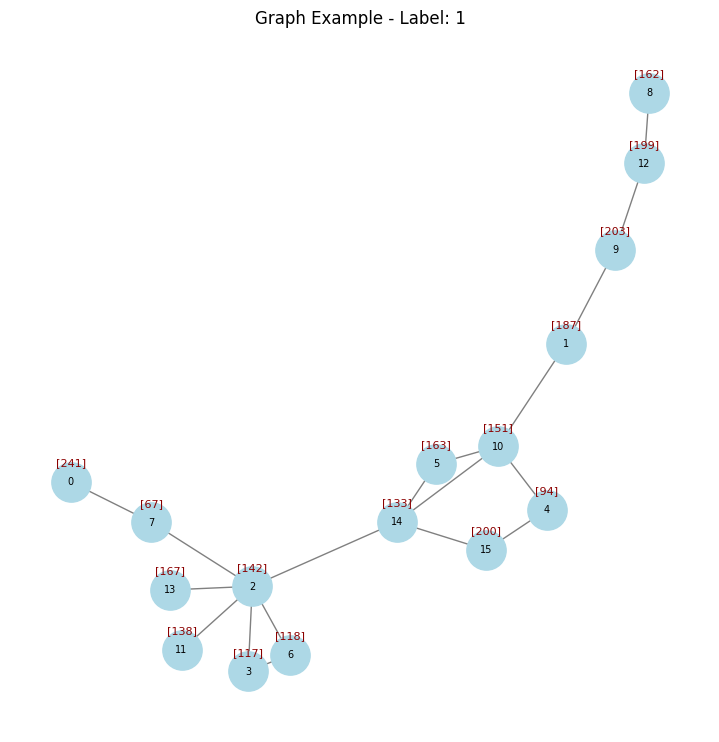

Data(x=[16, 1], edge_index=[2, 21], y=[1, 1])
[[0, 7], [1, 10], [2, 6], [2, 7], [2, 11], [2, 13], [3, 2], [4, 10], [5, 14], [6, 3], [7, 0], [8, 12], [9, 1], [10, 5], [11, 2], [12, 9], [13, 2], [14, 2], [14, 10], [14, 15], [15, 4]]


In [13]:
#Plot the graph using the networkx library
def plot_graph(data):
    """Visualize a PyTorch Geometric graph with node and edge features."""
    G = to_networkx(data, to_undirected=True)
    
    # Get node positions for consistent layout
    pos = nx.spring_layout(G, seed=42)

    # Draw the graph structure
    plt.figure(figsize=(7, 7))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', 
            node_size=800, font_size=7)

    # Format node features
    node_labels = {i: f"{[round(f, 2) for f in data.x[i].tolist()]}" for i in range(data.x.shape[0])}

    # Display node features slightly above nodes
    offset = 0.05  # Adjust for better visibility
    pos_shifted = {k: (v[0], v[1] + offset) for k, v in pos.items()}
    nx.draw_networkx_labels(G, pos_shifted, labels=node_labels, font_size=8, font_color="darkred")

    # Add edge features if available
    if hasattr(data, "edge_attr") and data.edge_attr is not None:
        edge_labels = {(u, v): f"{[round(e, 2) for e in data.edge_attr[idx].tolist()]}" 
                       for idx, (u, v) in enumerate(data.edge_index.T.tolist())}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="darkblue")

    plt.title(f"Graph Example - Label: {data.y.item()}")
    plt.show()

# Plot the smallest graph
plot_graph(train_dataset[1])
print(train_dataset[1])
print(train_dataset[1].edge_index.t().tolist())


In [14]:
# Create DataLoader for batching
# NOTICE: This data loader is from torch_geometric.loader!! It is not from torch.utils.data
# define batch size for graph data loading
GNN_BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=GNN_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=GNN_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=GNN_BATCH_SIZE, shuffle=False)

print(f"Train loader: {len(train_loader)}, Validation loader: {len(val_loader)}, Test loader: {len(test_loader)}")

Train loader: 409, Validation loader: 103, Test loader: 204


Define the model
 GCN
 GraphSage
 Gat

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool, global_add_pool

# =========================================================================
# 1. GCN Model (Graph Convolutional Network) with Embedding & Dropout

class GCN(torch.nn.Module):
    def __init__(self, vocabulary_size, embedding_dim, hidden_dim, output_dim, global_aggr='mean', dropout_p=0.4):
        """
        Graph Convolutional Network (GCN) for Graph-Level Classification.
        
        Args:
            vocabulary_size (int): Total size of the vocabulary (unique API IDs).
            embedding_dim (int): Dimension of the dense vector for each node.
            hidden_dim (int): Dimension of the hidden layers (for hyperparameter tuning).
            output_dim (int): Number of target classes (e.g., 2 for malware vs goodware).
            global_aggr (str): Global aggregation function ('mean', 'max', or 'sum').
            dropout_p (float): Probability of an element to be zeroed in the Dropout layer.
        """
        super(GCN, self).__init__()
        
        # Store the global aggregation strategy in lowercase to avoid typos
        self.global_aggr = global_aggr.lower()
        
        # Trainable Embedding layer (Node IDs -> Dense Continuous Vectors)
        self.embedding = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=embedding_dim, padding_idx=0)
        
        # GCN Conv layers (fixed to a 2-layer architecture to mitigate oversmoothing)
        self.conv1 = GCNConv(embedding_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        
        # Dropout layer to regularize the network and prevent overfitting
        self.dropout = nn.Dropout(p=dropout_p)
        
        # Fully connected layer for final graph-level classification
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        # Unpack the PyTorch Geometric DataBatch assets
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Step 1: Dynamic embedding lookup and dimension squeezing
        # Reshape x from [Total_Nodes, 1] to [Total_Nodes] before embedding lookup
        x = x.squeeze(-1)  
        x = self.embedding(x)  # Output shape: [Total_Nodes, embedding_dim]
        
        # Step 2: First Graph Convolution + ReLU activation + Dropout
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        
        # Step 3: Second Graph Convolution + ReLU activation
        x = F.relu(self.conv2(x, edge_index))
        
        # Step 4: Dynamic Global Readout (Pooling) based on chosen strategy
        # Output shape transitions from Node-level to Graph-level: [Batch_Size, hidden_dim]
        if self.global_aggr == 'mean':
            x = global_mean_pool(x, batch)
        elif self.global_aggr == 'max':
            x = global_max_pool(x, batch)
        elif self.global_aggr in ['sum', 'add']:
            x = global_add_pool(x, batch)
        else:
            raise ValueError(f"Unsupported global aggregation function: '{self.global_aggr}'. Choose from 'mean', 'max', 'sum'.")
        
        # Step 5: Linear Classification layer (outputs raw logits)
        x = self.fc(x)
        return x
# =========================================================================
# 2. GraphSAGE Model (Graph Sample and Aggregate) with Configurable Local and Global Aggregation Functions
class GraphSAGE(torch.nn.Module):
    def __init__(self, vocabulary_size, embedding_dim, hidden_dim, output_dim, local_aggr='mean', global_aggr='mean', dropout_p=0.4):
        """
        GraphSAGE Model with Configurable Local and Global Aggregation Functions.
        
        Args:
            vocabulary_size (int): Total size of the vocabulary (unique API IDs).
            embedding_dim (int): Dimension of the dense vector for each node.
            hidden_dim (int): Dimension of the hidden layers.
            output_dim (int): Number of final classes (2 for binary classification).
            local_aggr (str): Local neighborhood aggregation strategy for SAGEConv ('mean', 'max', 'sum').
            global_aggr (str): Global readout aggregation strategy for graph pooling ('mean', 'max', 'sum').
            dropout_p (float): Probability of an element to be zeroed in the Dropout layer.
        """
        super(GraphSAGE, self).__init__()
        
        # Store global aggregation strategy in lowercase
        self.global_aggr = global_aggr.lower()
        
        # Trainable Embedding layer
        self.embedding = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=embedding_dim, padding_idx=0)
        
        # GraphSAGE Conv layers with dynamic local aggregation via the 'aggr' parameter
        # Supported PyG options include: 'mean', 'max', 'sum' (add)
        self.conv1 = SAGEConv(embedding_dim, hidden_dim, aggr=local_aggr)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr=local_aggr)
        
        # Dropout layer
        self.dropout = nn.Dropout(p=dropout_p)
        
        # Final fully connected layer for graph classification
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        # Unpack PyTorch Geometric DataBatch assets
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Step 1: Dynamic embedding lookup with safe dimension squeezing
        x = x.squeeze(-1)  # Reshape from [Total_Nodes, 1] to [Total_Nodes]
        x = self.embedding(x)  # Output shape: [Total_Nodes, embedding_dim]
        
        # Step 2: First GraphSAGE Convolution + ReLU + Dropout
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        
        # Step 3: Second GraphSAGE Convolution + ReLU
        x = F.relu(self.conv2(x, edge_index))
        
        # Step 4: Dynamic Global Readout (Pooling) stage
        # Graph-level feature aggregation: [Total_Nodes, hidden_dim] -> [Batch_Size, hidden_dim]
        if self.global_aggr == 'mean':
            x = global_mean_pool(x, batch)
        elif self.global_aggr == 'max':
            x = global_max_pool(x, batch)
        elif self.global_aggr in ['sum', 'add']:
            x = global_add_pool(x, batch)
        else:
            raise ValueError(f"Unsupported global aggregation: '{self.global_aggr}'. Choose from 'mean', 'max', 'sum'.")
        
        # Step 5: Classification head
        x = self.fc(x)
        return x


# =========================================================================
# 3. GAT Model (Graph Attention Network) with Embedding & Dropout
# =========================================================================
class GAT(torch.nn.Module):
    def __init__(self, vocabulary_size, embedding_dim, hidden_dim, output_dim, heads=8, global_aggr='mean', dropout_p=0.4):
        """
        Graph Attention Network (GAT) with Configurable Attention Heads and Global Readout.
        
        Args:
            vocabulary_size (int): Total size of the vocabulary (unique API IDs).
            embedding_dim (int): Dimension of the dense vector for each node.
            hidden_dim (int): Dimension of the hidden layers.
            output_dim (int): Number of final classes (2 for binary classification).
            heads (int): Number of multi-head attention streams for the first layer.
            global_aggr (str): Global readout aggregation strategy for graph pooling ('mean', 'max', 'sum').
            dropout_p (float): Probability of an element to be zeroed in the Dropout layer.
        """
        super(GAT, self).__init__()
        
        # Store global aggregation strategy in lowercase
        self.global_aggr = global_aggr.lower()
        
        # Trainable Embedding layer
        self.embedding = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=embedding_dim, padding_idx=0)
        
        # First GAT layer concatenates multi-head outputs: feature projection scales to (hidden_dim * heads)
        self.conv1 = GATConv(embedding_dim, hidden_dim, heads=heads, concat=True, dropout=dropout_p)
        
        # Second GAT layer averages outputs: input dim must match conv1's output space exactly
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False, dropout=dropout_p)
        
        # Dropout layer for final regularizations
        self.dropout = nn.Dropout(p=dropout_p)
        
        # Final fully connected layer for graph classification
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        # Unpack PyTorch Geometric DataBatch assets
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Step 1: Dynamic embedding lookup with safe dimension squeezing
        x = x.squeeze(-1)  # Reshape from [Total_Nodes, 1] to [Total_Nodes]
        x = self.embedding(x)  # Output shape: [Total_Nodes, embedding_dim]
        
        # Step 2: First GAT Layer execution with ELU activation + Dropout
        # Output shape: [Total_Nodes, hidden_dim * heads]
        x = F.elu(self.conv1(x, edge_index))
        x = self.dropout(x)
        
        # Step 3: Second GAT Layer execution with ELU activation
        # Output shape: [Total_Nodes, hidden_dim]
        x = F.elu(self.conv2(x, edge_index))
        
        # Step 4: Dynamic Global Readout (Pooling) stage
        # Graph-level feature aggregation: [Total_Nodes, hidden_dim] -> [Batch_Size, hidden_dim]
        if self.global_aggr == 'mean':
            x = global_mean_pool(x, batch)
        elif self.global_aggr == 'max':
            x = global_max_pool(x, batch)
        elif self.global_aggr in ['sum', 'add']:
            x = global_add_pool(x, batch)
        else:
            raise ValueError(f"Unsupported global aggregation: '{self.global_aggr}'. Choose from 'mean', 'max', 'sum'.")
        
        # Step 5: Classification head outputting raw logits
        x = self.fc(x)
        return x

## Define Training Loop and Testing function

In [16]:
# Function to visualize model performance by creating a confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names, dataset_name, model_name):
    """
    Creates and displays a confusion matrix to evaluate classification performance.
    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        class_names: List of class names for axis labels
    """
    cm = confusion_matrix(y_true, y_pred)  # Compute confusion matrix

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix +" +dataset_name+ " "+ model_name)
    plt.show()

import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, num_epochs, criterion, patience=10, min_delta=0.001):
    """
    Train the GNN model with Early Stopping and track training/validation losses.
    """
    start_time = time.time()
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    epochs_no_improvement = 0

    # Training loop with progress bar
    for epoch in tqdm(range(num_epochs), desc="Training Epochs"):  
        train_loss = 0
        val_loss = 0
        
        # ─── TRAINING STAGE ───
        model.train()  
        for batch in train_loader:
            batch = batch.to(device)  
            optimizer.zero_grad()  
            
            outputs = model(batch)  
            # FIX: Use safe squeeze(-1) to maintain 1D tensor shape [Batch_Size]
            loss = criterion(outputs, batch.y.squeeze(-1))  
            
            # FIX: Removed retain_graph=True to prevent massive CUDA memory leaks
            loss.backward()  
            optimizer.step()  
            
            # FIX: Use batch.num_graphs instead of batch.size(0)
            train_loss += loss.item() * batch.num_graphs
            
        train_loss /= len(train_dataset)
        train_losses.append(train_loss)  

        # ─── VALIDATION STAGE ───
        model.eval()  
        with torch.no_grad():  
            for batch in val_loader:
                batch = batch.to(device)  
                val_outputs = model(batch)  
                
                # FIX: Use safe squeeze(-1)
                loss = criterion(val_outputs, batch.y.squeeze(-1))  
                # FIX: Use batch.num_graphs instead of batch.size(0)
                val_loss += loss.item() * batch.num_graphs
                
            val_loss /= len(val_dataset)
            val_losses.append(val_loss)  

        # ─── EARLY STOPPING LOGIC ───
        if best_val_loss - val_loss > min_delta:
            best_val_loss = val_loss
            epochs_no_improvement = 0
            # Saving the best model checkpoint securely
            torch.save(model.state_dict(), 'best_model.pth')  
        else:
            epochs_no_improvement += 1
            if epochs_no_improvement >= patience:
                print(f'\n[Early Stopping] Triggered at epoch {epoch + 1}. No improvement over {patience} consecutive epochs.')
                print(f'Epoch {epoch+1}/{num_epochs} | Final Train Loss: {train_losses[-1]:.4f} | Final Val Loss: {val_losses[-1]:.4f}')
                break  

        # Print metrics every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')

    end_time = time.time()
    print(f'\nTraining complete. Execution time: {end_time - start_time:.2f} seconds.')

    # ─── POST-TRAINING RESTORATION ───
    # Safely load the best weights recorded during the training process
    try:
        model.load_state_dict(torch.load('best_model.pth', map_location=device))
        print("Successfully restored the best model weights from 'best_model.pth'.")
    except FileNotFoundError:
        print("Warning: 'best_model.pth' not found. Keeping current model weights.")

    # ─── LOSS CURVE PLOTTING ───
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curve (GNN)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return

import time
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report

def testing_model(model, dataloader, device, dataset_name, model_name):
    """
    Evaluate the model on a given dataloader, compute accuracy,
    and print a comprehensive classification report.
    
    Args:
        model: The trained model.
        dataloader: DataLoader for the dataset.
        device: Device to run the model on (CPU or GPU).
        dataset_name (str): Name of the dataset for plot title.
        model_name (str): Name of the model for plot title.
    
    Returns:
        float: Accuracy of the model on the test dataset.
    """
    # Record the start time
    start_time = time.time()
   
    model.eval()  # Set the model to evaluation mode
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():  # Disable gradient computation for efficiency
        for batch in dataloader:
            batch = batch.to(device)  # Move batch to GPU
            outputs = model(batch)
            _, predicted = torch.max(outputs, 1)  # Get the class with highest score
            
            # FIX: Use .view(-1) to prevent 0D scalar crash if last batch_size = 1
            all_labels.extend(batch.y.view(-1).cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    
    # Compute accuracy percentage
    accuracy = accuracy_score(all_labels, all_predictions) * 100

    # Define class names dynamically based on labels present
    unique_labels = np.unique(all_labels)
    class_names = [f"Class {cls}" for cls in unique_labels]

    # ─── ADDED: Print Classification Report ───
    print("\n" + "="*60)
    print(f"📊 Classification Report - {dataset_name} ({model_name})")
    print("="*60)
    # If your dataset has 0 as Benign and 1 as Malware, you can also manually pass
    # target_names=['Benign', 'Malware'] if unique_labels length matches.
    print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))
    print("="*60 + "\n")

    # Plot the confusion matrix
    plot_confusion_matrix(all_labels, all_predictions, class_names, dataset_name, model_name)
    
    # Record the end time
    end_time = time.time()
    print(f'The function took {end_time - start_time:.4f} seconds to execute.')    
    
    return accuracy

### define some hyper parameter for GCN training

In [17]:
# some common hyperparameters for GNN training
# Fix hidden_dim to isolate variables (e.g., fixed to 64)
# =========================================================================
# =========================================================================
# 1. Define Global Control Constants & Hyperparameter Search Space
# =========================================================================
FIXED_EMBEDDING_DIM = 32
FIXED_HIDDEN_DIM = 64
MAX_EPOCHS = 100
PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_sizes = [FIXED_EMBEDDING_DIM]  
global_aggregations = ['mean', 'max', 'sum']

🚀 Starting Grid Search Exploration for GCN Variations...

start experiment ───▶ [Embedding Size: 32] | [Global Aggregation: mean]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:11<03:19,  2.10s/it]

Epoch 5/100 | Train Loss: 0.1198 | Val Loss: 0.1276


Training Epochs:  10%|█         | 10/100 [00:22<03:03,  2.04s/it]

Epoch 10/100 | Train Loss: 0.1158 | Val Loss: 0.1259


...

Epoch 20/100 | Train Loss: 0.1131 | Val Loss: 0.1180


Training Epochs:  25%|██▌       | 25/100 [01:11<04:29,  3.59s/it]

Epoch 25/100 | Train Loss: 0.1103 | Val Loss: 0.1155


Training Epochs:  27%|██▋       | 27/100 [01:21<03:40,  3.02s/it]


[Early Stopping] Triggered at epoch 28. No improvement over 15 consecutive epochs.
Epoch 28/100 | Final Train Loss: 0.1138 | Final Val Loss: 0.1238

Training complete. Execution time: 81.55 seconds.
Successfully restored the best model weights from 'best_model.pth'.


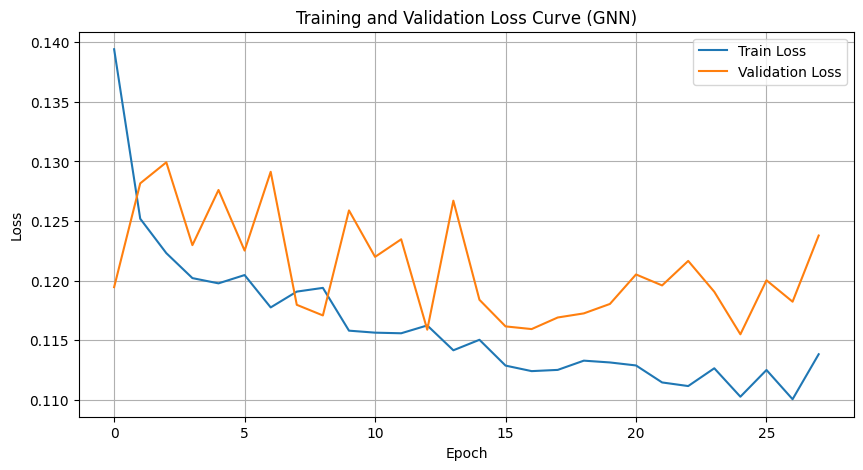

Evaluating GCN-E32-Amean on Train Dataset...

📊 Classification Report - Train (GCN-E32-Amean)
              precision    recall  f1-score   support

     Class 0     0.4103    0.0327    0.0606       489
     Class 1     0.9637    0.9982    0.9806     12571

    accuracy                         0.9620     13060
   macro avg     0.6870    0.5154    0.5206     13060
weighted avg     0.9430    0.9620    0.9462     13060




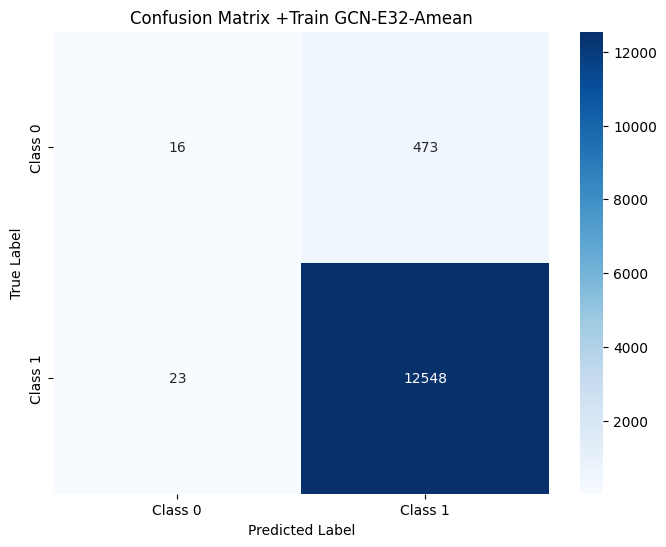

The function took 1.3520 seconds to execute.
Evaluating GCN-E32-Amean on Validation Dataset...

📊 Classification Report - Validation (GCN-E32-Amean)
              precision    recall  f1-score   support

     Class 0     0.4286    0.0738    0.1259       122
     Class 1     0.9652    0.9962    0.9804      3143

    accuracy                         0.9617      3265
   macro avg     0.6969    0.5350    0.5532      3265
weighted avg     0.9451    0.9617    0.9485      3265




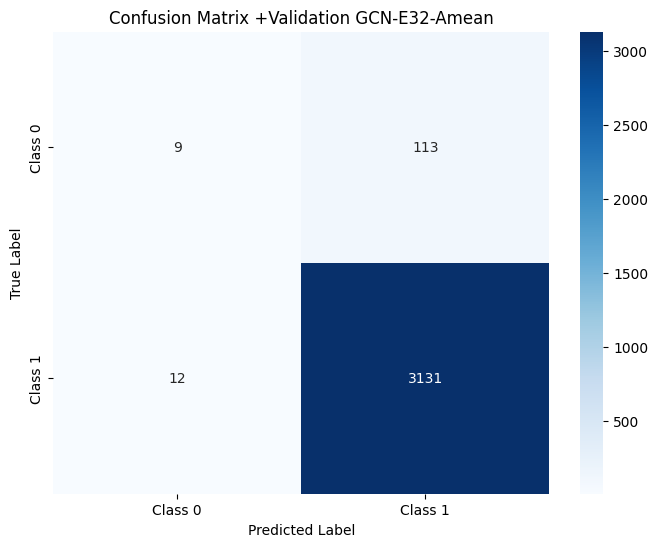

The function took 0.3741 seconds to execute.
Evaluating GCN-E32-Amean on Test Dataset...

📊 Classification Report - Test (GCN-E32-Amean)
              precision    recall  f1-score   support

     Class 0     0.4545    0.0412    0.0755       243
     Class 1     0.9641    0.9981    0.9808      6262

    accuracy                         0.9623      6505
   macro avg     0.7093    0.5196    0.5281      6505
weighted avg     0.9450    0.9623    0.9470      6505




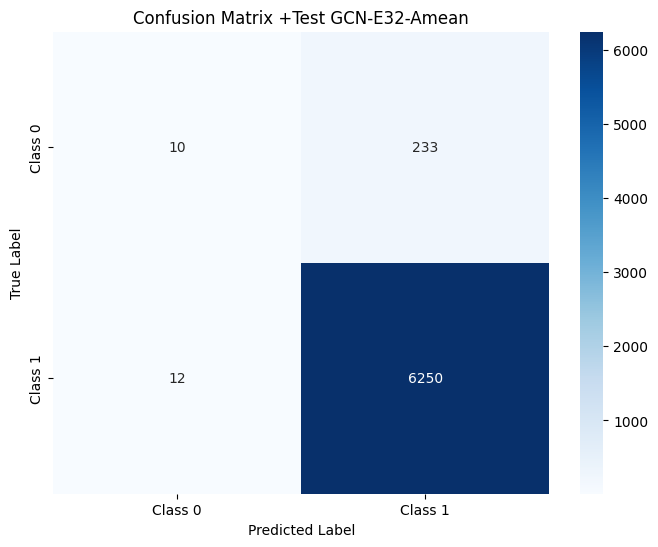

The function took 0.6485 seconds to execute.
▶▶▶ Result | Train: 96.20% | Val: 96.17% | Test: 96.23%

start experiment ───▶ [Embedding Size: 32] | [Global Aggregation: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:11<03:31,  2.23s/it]

Epoch 5/100 | Train Loss: 0.1195 | Val Loss: 0.1221


Training Epochs:  10%|█         | 10/100 [00:23<03:58,  2.65s/it]

Epoch 10/100 | Train Loss: 0.1153 | Val Loss: 0.1223


...

Epoch 20/100 | Train Loss: 0.1159 | Val Loss: 0.1302


Training Epochs:  25%|██▌       | 25/100 [01:10<02:50,  2.27s/it]

Epoch 25/100 | Train Loss: 0.1161 | Val Loss: 0.1345


Training Epochs:  29%|██▉       | 29/100 [01:19<03:15,  2.75s/it]


[Early Stopping] Triggered at epoch 30. No improvement over 15 consecutive epochs.
Epoch 30/100 | Final Train Loss: 0.1144 | Final Val Loss: 0.1218

Training complete. Execution time: 79.67 seconds.
Successfully restored the best model weights from 'best_model.pth'.


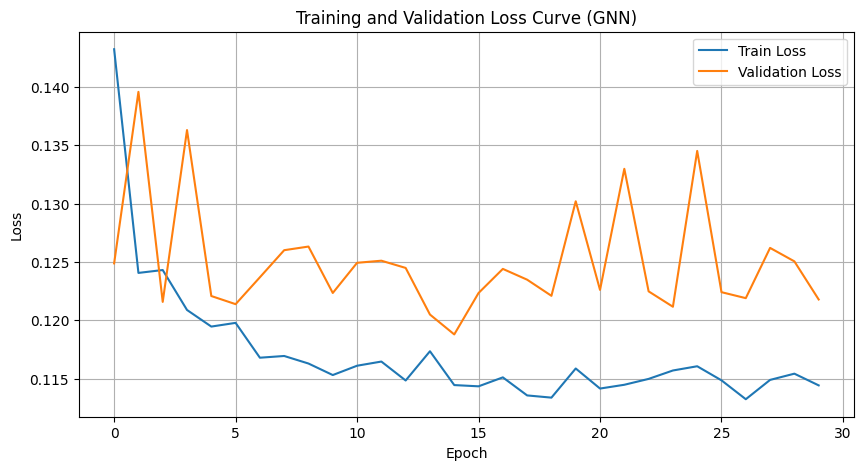

Evaluating GCN-E32-Amax on Train Dataset...

📊 Classification Report - Train (GCN-E32-Amax)
              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000       489
     Class 1     0.9626    1.0000    0.9809     12571

    accuracy                         0.9626     13060
   macro avg     0.4813    0.5000    0.4905     13060
weighted avg     0.9265    0.9626    0.9442     13060




/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

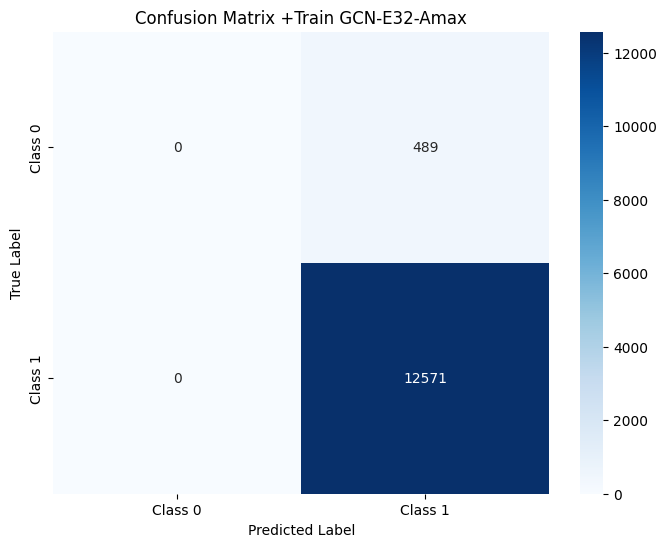

The function took 1.0774 seconds to execute.
Evaluating GCN-E32-Amax on Validation Dataset...

📊 Classification Report - Validation (GCN-E32-Amax)
              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000       122
     Class 1     0.9626    1.0000    0.9810      3143

    accuracy                         0.9626      3265
   macro avg     0.4813    0.5000    0.4905      3265
weighted avg     0.9267    0.9626    0.9443      3265




/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

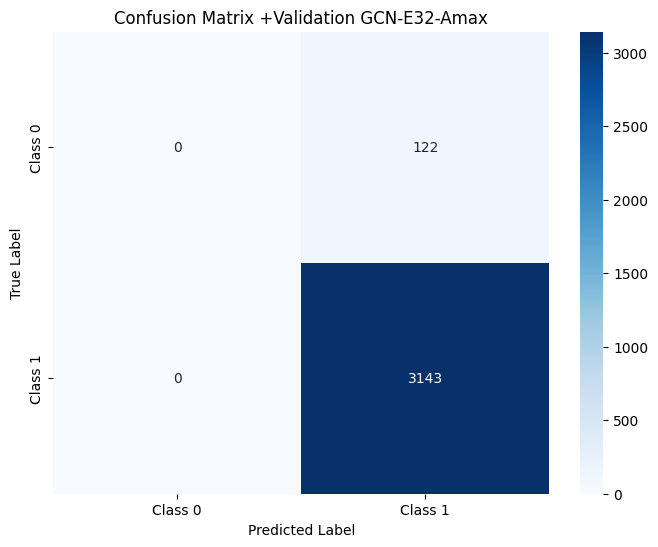

The function took 0.3032 seconds to execute.
Evaluating GCN-E32-Amax on Test Dataset...

📊 Classification Report - Test (GCN-E32-Amax)
              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000       243
     Class 1     0.9626    1.0000    0.9810      6262

    accuracy                         0.9626      6505
   macro avg     0.4813    0.5000    0.4905      6505
weighted avg     0.9267    0.9626    0.9443      6505




/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

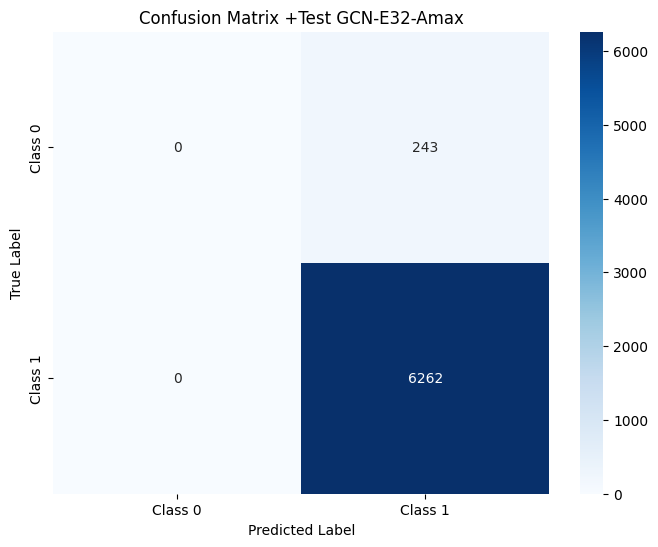

The function took 0.6547 seconds to execute.
▶▶▶ Result | Train: 96.26% | Val: 96.26% | Test: 96.26%

start experiment ───▶ [Embedding Size: 32] | [Global Aggregation: sum]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:09<02:56,  1.86s/it]

Epoch 5/100 | Train Loss: 0.1084 | Val Loss: 0.1036


Training Epochs:  10%|█         | 10/100 [00:19<02:56,  1.96s/it]

Epoch 10/100 | Train Loss: 0.0976 | Val Loss: 0.1041


...

Epoch 15/100 | Train Loss: 0.0945 | Val Loss: 0.1056


Training Epochs:  20%|██        | 20/100 [00:38<02:29,  1.87s/it]

Epoch 20/100 | Train Loss: 0.0926 | Val Loss: 0.1425


Training Epochs:  21%|██        | 21/100 [00:42<02:39,  2.02s/it]


[Early Stopping] Triggered at epoch 22. No improvement over 15 consecutive epochs.
Epoch 22/100 | Final Train Loss: 0.0896 | Final Val Loss: 0.1109

Training complete. Execution time: 42.45 seconds.
Successfully restored the best model weights from 'best_model.pth'.


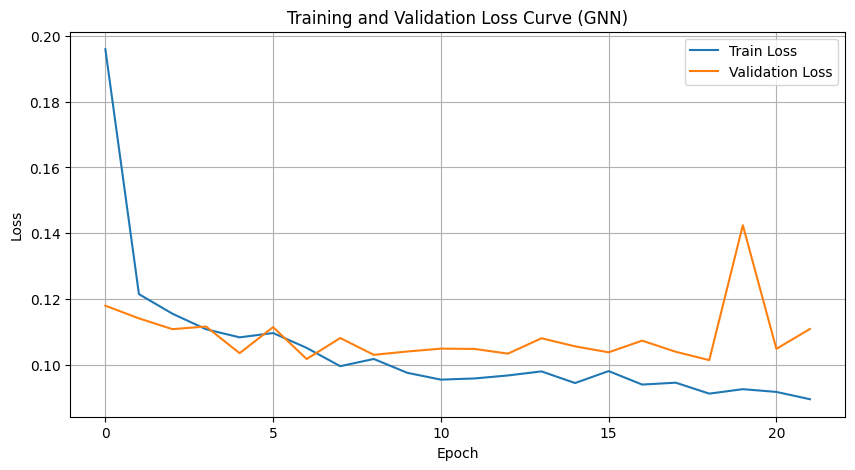

Evaluating GCN-E32-Asum on Train Dataset...

📊 Classification Report - Train (GCN-E32-Asum)
              precision    recall  f1-score   support

     Class 0     0.8472    0.2495    0.3855       489
     Class 1     0.9716    0.9982    0.9847     12571

    accuracy                         0.9702     13060
   macro avg     0.9094    0.6239    0.6851     13060
weighted avg     0.9669    0.9702    0.9623     13060




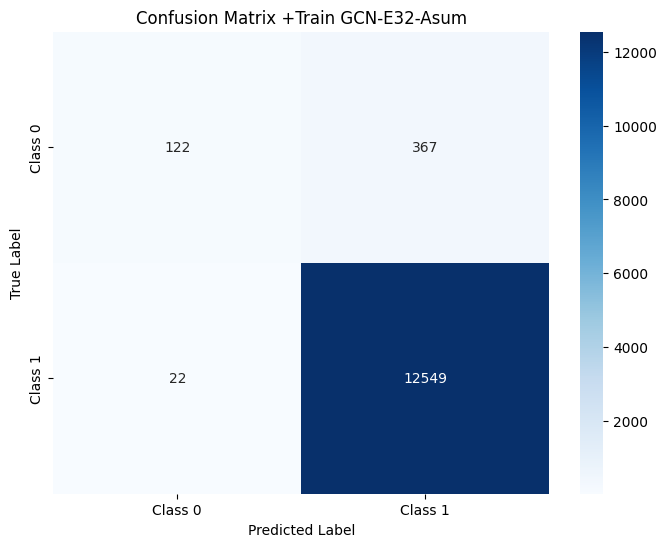

The function took 1.1095 seconds to execute.
Evaluating GCN-E32-Asum on Validation Dataset...

📊 Classification Report - Validation (GCN-E32-Asum)
              precision    recall  f1-score   support

     Class 0     0.8438    0.2213    0.3506       122
     Class 1     0.9706    0.9984    0.9843      3143

    accuracy                         0.9694      3265
   macro avg     0.9072    0.6099    0.6675      3265
weighted avg     0.9659    0.9694    0.9606      3265




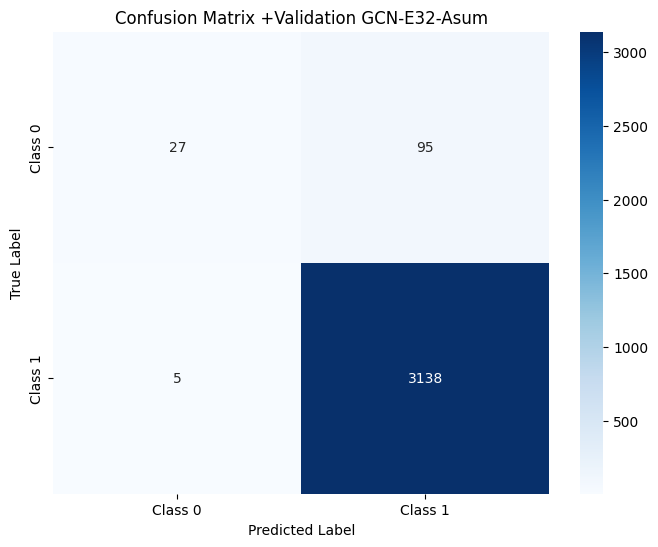

The function took 0.3239 seconds to execute.
Evaluating GCN-E32-Asum on Test Dataset...

📊 Classification Report - Test (GCN-E32-Asum)
              precision    recall  f1-score   support

     Class 0     0.7759    0.1852    0.2990       243
     Class 1     0.9693    0.9979    0.9834      6262

    accuracy                         0.9676      6505
   macro avg     0.8726    0.5916    0.6412      6505
weighted avg     0.9621    0.9676    0.9578      6505




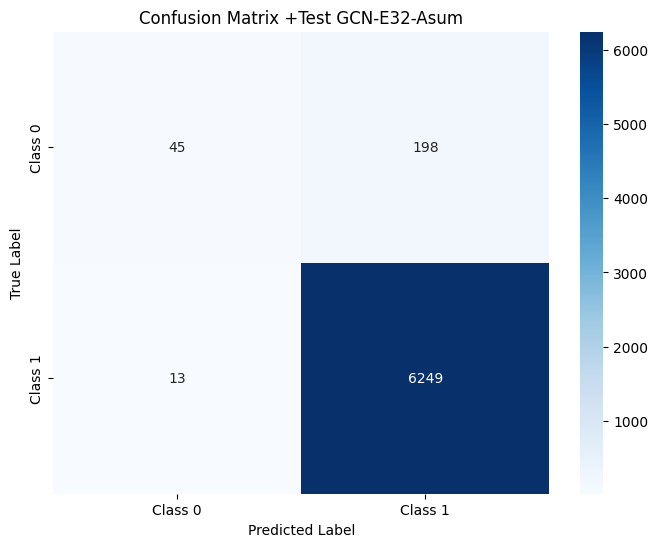

The function took 0.6906 seconds to execute.
▶▶▶ Result | Train: 97.02% | Val: 96.94% | Test: 96.76%

🏆 ALL EXPERIMENTS COMPLETED! FINAL MULTI-METRIC SUMMARY TABLE:
 Embedding_Dim Global_Aggregation  Train_Acc_%  Val_Acc_%  Test_Acc_%
            32               mean        96.20      96.17       96.23
            32                max        96.26      96.26       96.26
            32                sum        97.02      96.94       96.76

Results successfully saved to 'gcn_hyperparameter_tuning_results.csv'


In [18]:
import pandas as pd
import torch
# DataFrame to collect and store all final experimental results
experimental_summary = []

print("============================================================")
print("🚀 Starting Grid Search Exploration for GCN Variations...")
print("============================================================")

# =========================================================================
# 2. Grid Search Execution Loop
# =========================================================================
for emb_dim in embedding_sizes:
    for aggr in global_aggregations:
        print(f"\nstart experiment ───▶ [Embedding Size: {emb_dim}] | [Global Aggregation: {aggr}]")
        print("-" * 70)
        
        # 🚨 CRITICAL STEP: Re-initialize the model shell with current hyperparameters
        model = GCN(
            vocabulary_size=len(global_vocab_to_id),
            embedding_dim=emb_dim,
            hidden_dim=FIXED_HIDDEN_DIM,
            output_dim=2,
            global_aggr=aggr,
            dropout_p=0.4
        ).to(device)
        
        # 🚨 CRITICAL STEP: Re-instantiate the optimizer for the NEW model parameters
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        criterion = torch.nn.CrossEntropyLoss()
        
        # 3. Execute Training with Early Stopping
        # Your custom training_loop automatically loads the best weights before exiting
        training_loop(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            device=device,
            optimizer=optimizer,
            num_epochs=MAX_EPOCHS,
            criterion=criterion,
            patience=PATIENCE,
            min_delta=0.001
        )
        
        # 4. Multi-Dataset Diagnostic Evaluation (Train vs Val vs Test)
        # This gives full visibility into Overfitting / Underfitting behaviors per configuration
        current_model_tag = f"GCN-E{emb_dim}-A{aggr}"
        
        print(f"Evaluating {current_model_tag} on Train Dataset...")
        train_acc = testing_model(model, train_loader, device, "Train", current_model_tag)
        
        print(f"Evaluating {current_model_tag} on Validation Dataset...")
        val_acc = testing_model(model, val_loader, device, "Validation", current_model_tag)
        
        print(f"Evaluating {current_model_tag} on Test Dataset...")
        test_acc = testing_model(model, test_loader, device, "Test", current_model_tag)
        
        print(f"▶▶▶ Result | Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Test: {test_acc:.2f}%")
        
        # 5. Append comprehensive metric records into our summary list
        experimental_summary.append({
            'Embedding_Dim': emb_dim,
            'Global_Aggregation': aggr,
            'Train_Acc_%': round(train_acc, 2),
            'Val_Acc_%': round(val_acc, 2),
            'Test_Acc_%': round(test_acc, 2)
        })

# =========================================================================
# 3. Present Final Comprehensive Summary Table
# =========================================================================
df_results = pd.DataFrame(experimental_summary)
print("\n" + "="*80)
print("🏆 ALL EXPERIMENTS COMPLETED! FINAL MULTI-METRIC SUMMARY TABLE:")
print("="*80)
print(df_results.to_string(index=False))

# Save results to CSV for your report charts or Excel formatting
df_results.to_csv('gcn_hyperparameter_tuning_results.csv', index=False)
print("\nResults successfully saved to 'gcn_hyperparameter_tuning_results.csv'")

🚀 Starting Streamlined Grid Search for GraphSAGE (9 Variations)...

Start Experiment ───▶ [Local: mean] | [Global: mean]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:11<03:33,  2.25s/it]

Epoch 5/100 | Train Loss: 0.1091 | Val Loss: 0.1441


Training Epochs:  10%|█         | 10/100 [00:22<03:15,  2.17s/it]

Epoch 10/100 | Train Loss: 0.0989 | Val Loss: 0.0968


...

Epoch 15/100 | Train Loss: 0.0946 | Val Loss: 0.0965


Training Epochs:  20%|██        | 20/100 [00:43<02:48,  2.10s/it]

Epoch 20/100 | Train Loss: 0.0916 | Val Loss: 0.0971


Training Epochs:  24%|██▍       | 24/100 [00:54<02:53,  2.28s/it]


[Early Stopping] Triggered at epoch 25. No improvement over 15 consecutive epochs.
Epoch 25/100 | Final Train Loss: 0.0905 | Final Val Loss: 0.0965

Training complete. Execution time: 54.67 seconds.
Successfully restored the best model weights from 'best_model.pth'.


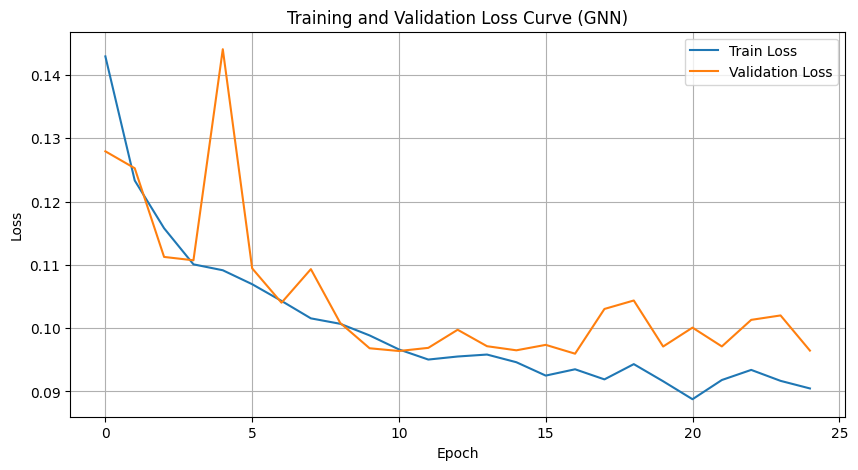


📊 Classification Report - Train (SAGE-L_mean-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7589    0.2188    0.3397       489
     Class 1     0.9704    0.9973    0.9837     12571

    accuracy                         0.9681     13060
   macro avg     0.8646    0.6081    0.6617     13060
weighted avg     0.9625    0.9681    0.9596     13060




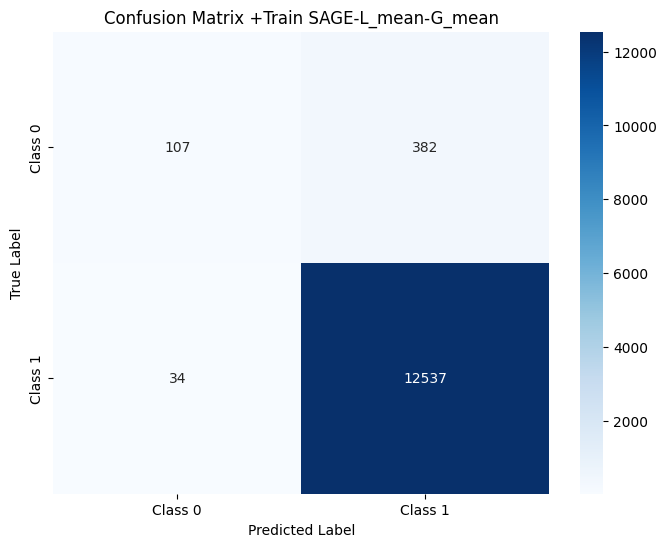

The function took 1.0846 seconds to execute.

📊 Classification Report - Validation (SAGE-L_mean-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7500    0.1967    0.3117       122
     Class 1     0.9697    0.9975    0.9834      3143

    accuracy                         0.9675      3265
   macro avg     0.8598    0.5971    0.6475      3265
weighted avg     0.9615    0.9675    0.9583      3265




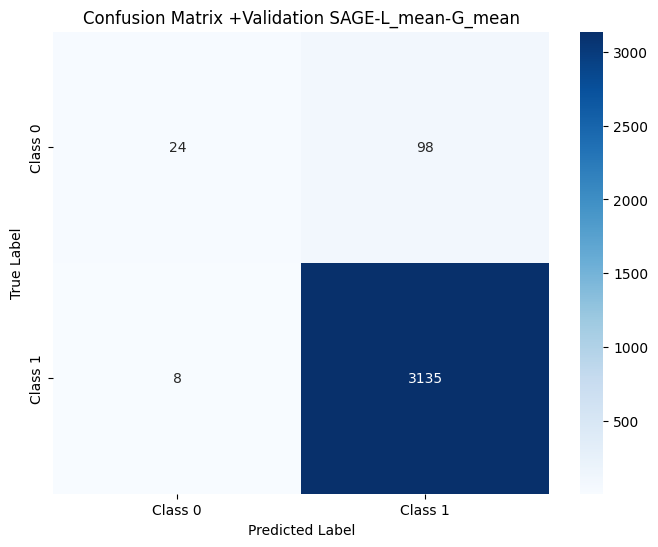

The function took 0.3240 seconds to execute.

📊 Classification Report - Test (SAGE-L_mean-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7843    0.1646    0.2721       243
     Class 1     0.9685    0.9982    0.9832      6262

    accuracy                         0.9671      6505
   macro avg     0.8764    0.5814    0.6276      6505
weighted avg     0.9617    0.9671    0.9566      6505




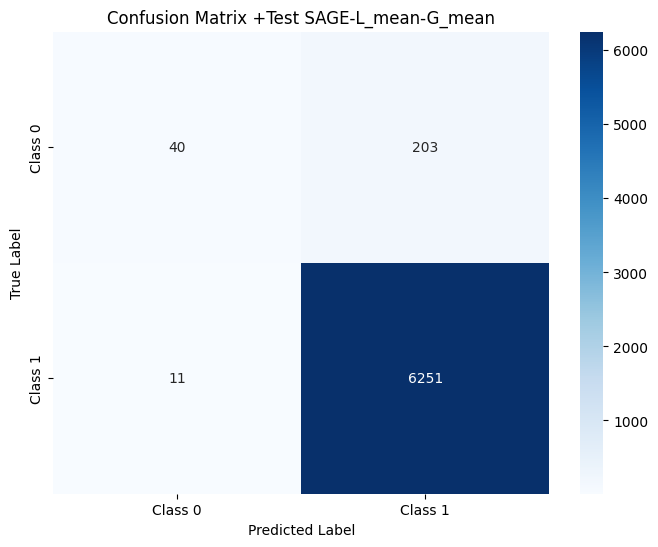

The function took 0.5534 seconds to execute.

Start Experiment ───▶ [Local: mean] | [Global: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:11<03:50,  2.42s/it]

Epoch 5/100 | Train Loss: 0.1021 | Val Loss: 0.1134


Training Epochs:  10%|█         | 10/100 [00:23<03:26,  2.29s/it]

Epoch 10/100 | Train Loss: 0.0914 | Val Loss: 0.1148


...

Epoch 45/100 | Train Loss: 0.0774 | Val Loss: 0.0911


Training Epochs:  50%|█████     | 50/100 [01:57<01:40,  2.02s/it]

Epoch 50/100 | Train Loss: 0.0736 | Val Loss: 0.0971


Training Epochs:  52%|█████▏    | 52/100 [02:03<01:54,  2.38s/it]


[Early Stopping] Triggered at epoch 53. No improvement over 15 consecutive epochs.
Epoch 53/100 | Final Train Loss: 0.0772 | Final Val Loss: 0.0940

Training complete. Execution time: 123.95 seconds.
Successfully restored the best model weights from 'best_model.pth'.


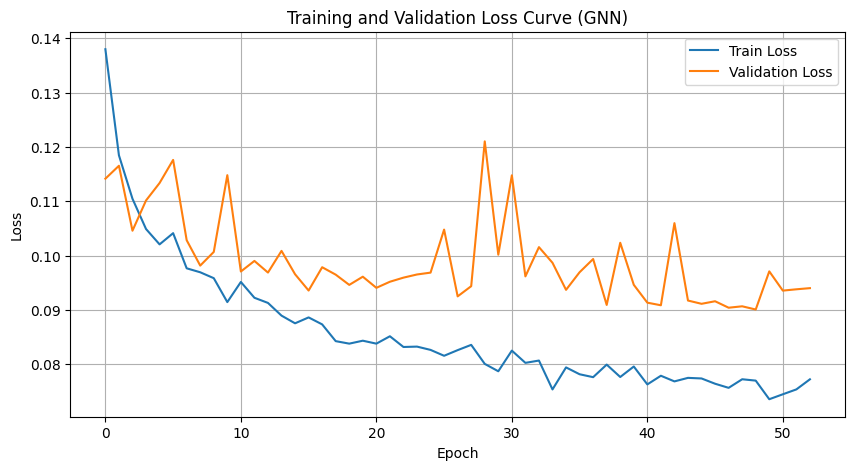


📊 Classification Report - Train (SAGE-L_mean-G_max)
              precision    recall  f1-score   support

     Class 0     0.8962    0.4765    0.6222       489
     Class 1     0.9800    0.9979    0.9888     12571

    accuracy                         0.9783     13060
   macro avg     0.9381    0.7372    0.8055     13060
weighted avg     0.9769    0.9783    0.9751     13060




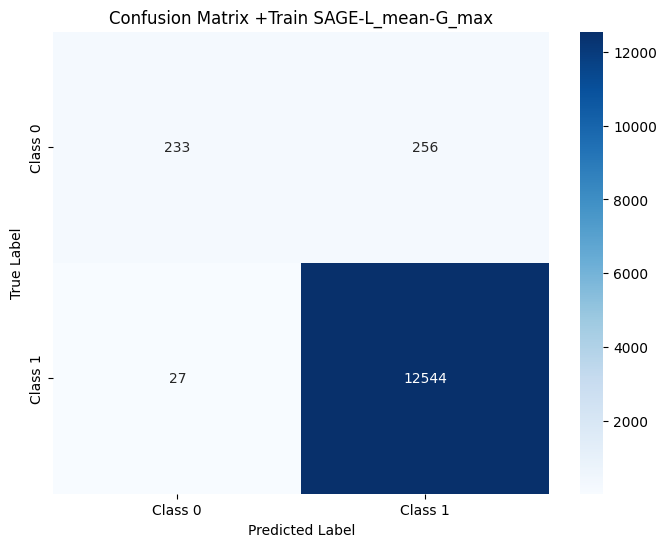

The function took 0.9960 seconds to execute.

📊 Classification Report - Validation (SAGE-L_mean-G_max)
              precision    recall  f1-score   support

     Class 0     0.7143    0.3279    0.4494       122
     Class 1     0.9744    0.9949    0.9846      3143

    accuracy                         0.9700      3265
   macro avg     0.8444    0.6614    0.7170      3265
weighted avg     0.9647    0.9700    0.9646      3265




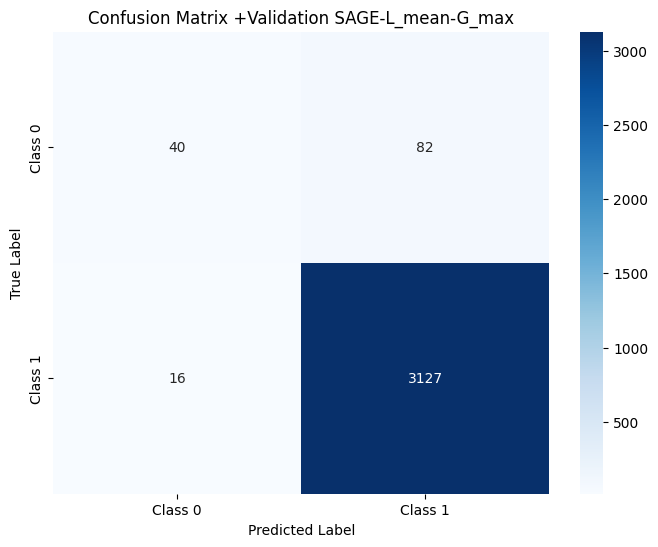

The function took 0.3629 seconds to execute.

📊 Classification Report - Test (SAGE-L_mean-G_max)
              precision    recall  f1-score   support

     Class 0     0.7404    0.3169    0.4438       243
     Class 1     0.9741    0.9957    0.9848      6262

    accuracy                         0.9703      6505
   macro avg     0.8572    0.6563    0.7143      6505
weighted avg     0.9653    0.9703    0.9646      6505




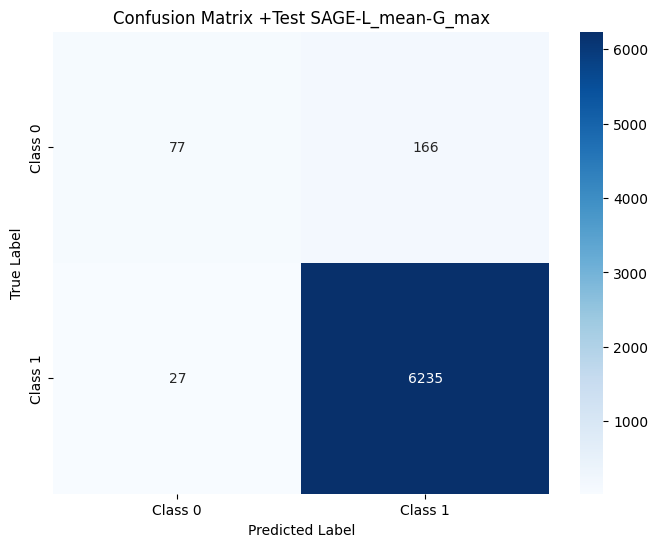

The function took 0.5953 seconds to execute.

Start Experiment ───▶ [Local: mean] | [Global: sum]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:08<02:51,  1.80s/it]

Epoch 5/100 | Train Loss: 0.0946 | Val Loss: 0.1096


Training Epochs:  10%|█         | 10/100 [00:22<04:10,  2.78s/it]

Epoch 10/100 | Train Loss: 0.0794 | Val Loss: 0.0932


...

Epoch 60/100 | Train Loss: 0.0620 | Val Loss: 0.0938


Training Epochs:  65%|██████▌   | 65/100 [03:20<01:40,  2.87s/it]

Epoch 65/100 | Train Loss: 0.0603 | Val Loss: 0.0848


Training Epochs:  65%|██████▌   | 65/100 [03:23<01:49,  3.13s/it]


[Early Stopping] Triggered at epoch 66. No improvement over 15 consecutive epochs.
Epoch 66/100 | Final Train Loss: 0.0630 | Final Val Loss: 0.1293

Training complete. Execution time: 203.18 seconds.
Successfully restored the best model weights from 'best_model.pth'.


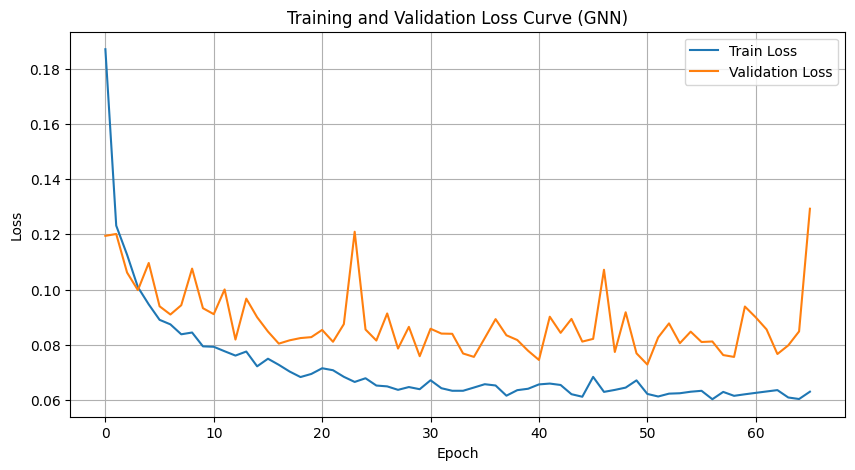


📊 Classification Report - Train (SAGE-L_mean-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8929    0.6646    0.7620       489
     Class 1     0.9871    0.9969    0.9920     12571

    accuracy                         0.9845     13060
   macro avg     0.9400    0.8308    0.8770     13060
weighted avg     0.9836    0.9845    0.9834     13060




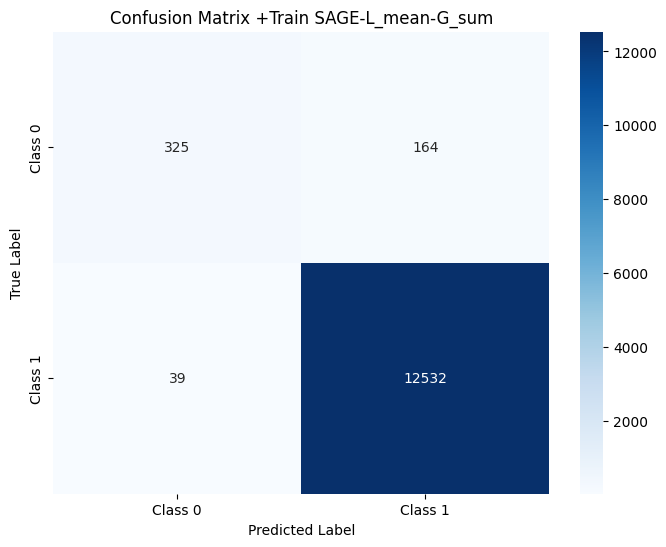

The function took 1.5451 seconds to execute.

📊 Classification Report - Validation (SAGE-L_mean-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8507    0.4672    0.6032       122
     Class 1     0.9797    0.9968    0.9882      3143

    accuracy                         0.9770      3265
   macro avg     0.9152    0.7320    0.7957      3265
weighted avg     0.9749    0.9770    0.9738      3265




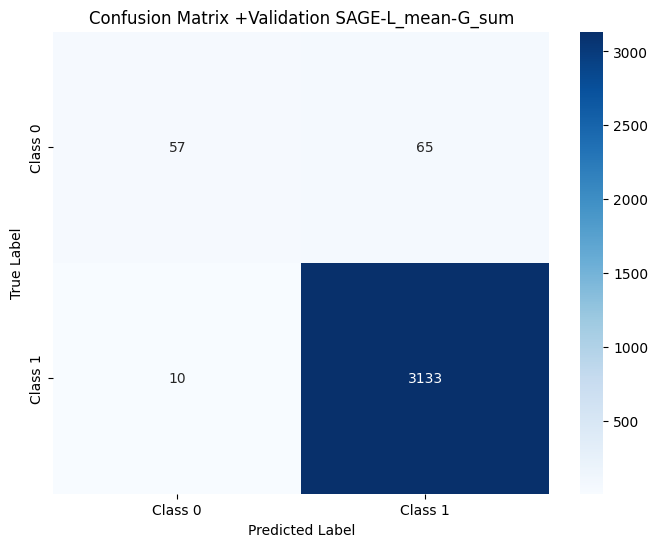

The function took 0.5280 seconds to execute.

📊 Classification Report - Test (SAGE-L_mean-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7662    0.4856    0.5945       243
     Class 1     0.9803    0.9943    0.9872      6262

    accuracy                         0.9752      6505
   macro avg     0.8733    0.7399    0.7908      6505
weighted avg     0.9723    0.9752    0.9726      6505




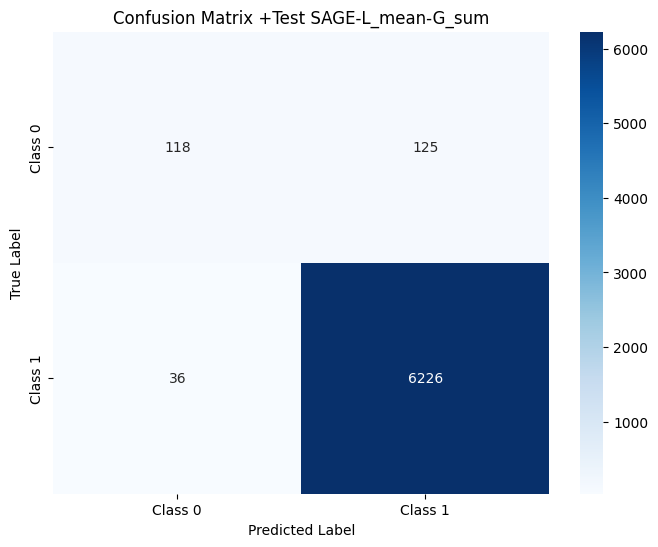

The function took 0.9335 seconds to execute.

Start Experiment ───▶ [Local: max] | [Global: mean]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:16<05:13,  3.30s/it]

Epoch 5/100 | Train Loss: 0.0877 | Val Loss: 0.0917


Training Epochs:  10%|█         | 10/100 [00:32<04:51,  3.24s/it]

Epoch 10/100 | Train Loss: 0.0757 | Val Loss: 0.0813


...

Epoch 30/100 | Train Loss: 0.0643 | Val Loss: 0.0795


Training Epochs:  35%|███▌      | 35/100 [01:58<03:39,  3.37s/it]

Epoch 35/100 | Train Loss: 0.0656 | Val Loss: 0.0800


Training Epochs:  35%|███▌      | 35/100 [02:01<03:46,  3.49s/it]


[Early Stopping] Triggered at epoch 36. No improvement over 15 consecutive epochs.
Epoch 36/100 | Final Train Loss: 0.0649 | Final Val Loss: 0.0738

Training complete. Execution time: 121.98 seconds.
Successfully restored the best model weights from 'best_model.pth'.


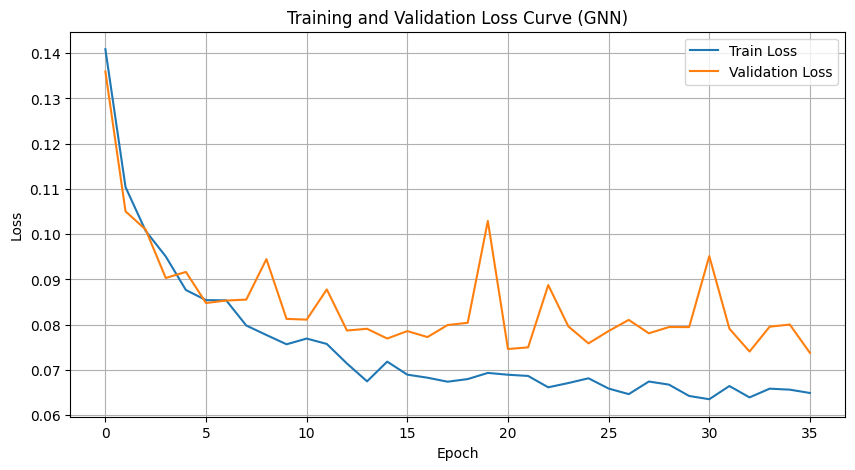


📊 Classification Report - Train (SAGE-L_max-G_mean)
              precision    recall  f1-score   support

     Class 0     0.8641    0.5460    0.6692       489
     Class 1     0.9826    0.9967    0.9896     12571

    accuracy                         0.9798     13060
   macro avg     0.9233    0.7713    0.8294     13060
weighted avg     0.9782    0.9798    0.9776     13060




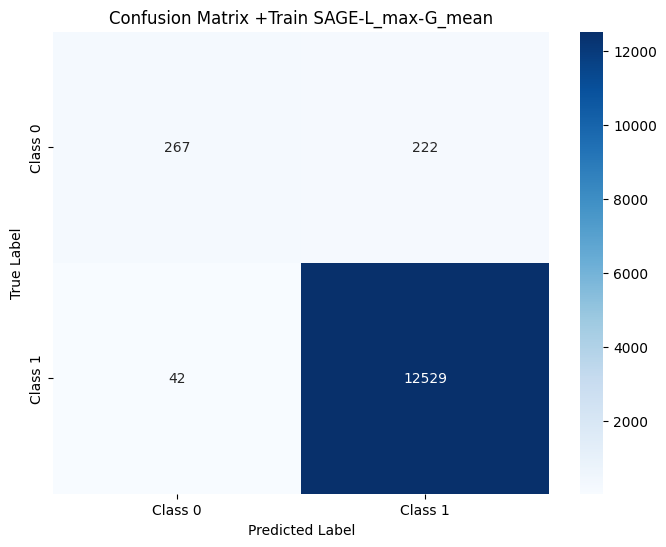

The function took 1.5439 seconds to execute.

📊 Classification Report - Validation (SAGE-L_max-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7857    0.4508    0.5729       122
     Class 1     0.9790    0.9952    0.9871      3143

    accuracy                         0.9749      3265
   macro avg     0.8824    0.7230    0.7800      3265
weighted avg     0.9718    0.9749    0.9716      3265




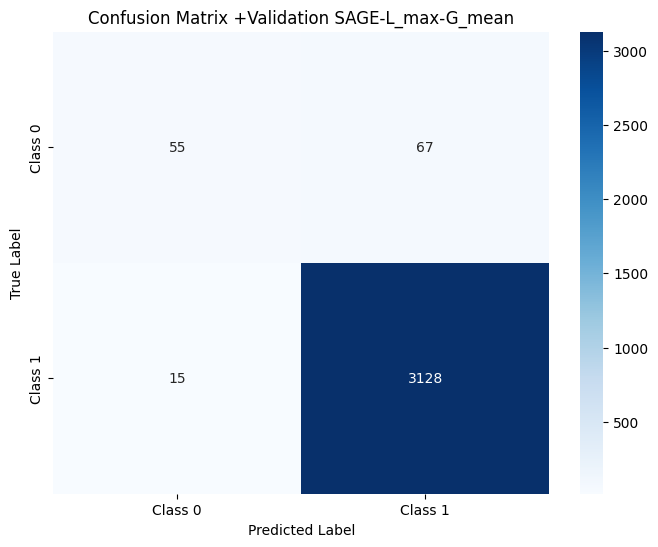

The function took 0.4872 seconds to execute.

📊 Classification Report - Test (SAGE-L_max-G_mean)
              precision    recall  f1-score   support

     Class 0     0.6870    0.3704    0.4813       243
     Class 1     0.9760    0.9935    0.9846      6262

    accuracy                         0.9702      6505
   macro avg     0.8315    0.6819    0.7330      6505
weighted avg     0.9652    0.9702    0.9658      6505




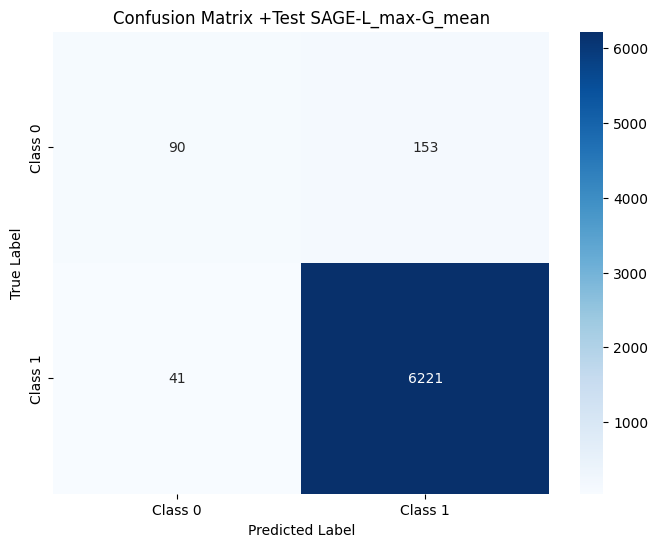

The function took 0.7789 seconds to execute.

Start Experiment ───▶ [Local: max] | [Global: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:17<05:37,  3.56s/it]

Epoch 5/100 | Train Loss: 0.0924 | Val Loss: 0.0922


Training Epochs:  10%|█         | 10/100 [00:34<05:06,  3.40s/it]

Epoch 10/100 | Train Loss: 0.0725 | Val Loss: 0.0750


...

Epoch 25/100 | Train Loss: 0.0617 | Val Loss: 0.0853


Training Epochs:  30%|███       | 30/100 [01:42<03:58,  3.41s/it]

Epoch 30/100 | Train Loss: 0.0604 | Val Loss: 0.0779


Training Epochs:  31%|███       | 31/100 [01:49<04:03,  3.54s/it]


[Early Stopping] Triggered at epoch 32. No improvement over 15 consecutive epochs.
Epoch 32/100 | Final Train Loss: 0.0552 | Final Val Loss: 0.0721

Training complete. Execution time: 109.61 seconds.
Successfully restored the best model weights from 'best_model.pth'.


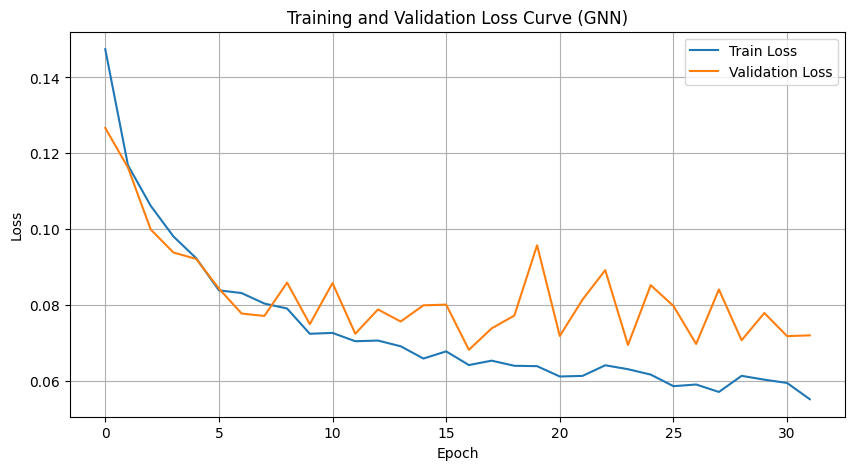


📊 Classification Report - Train (SAGE-L_max-G_max)
              precision    recall  f1-score   support

     Class 0     0.9038    0.5767    0.7041       489
     Class 1     0.9838    0.9976    0.9906     12571

    accuracy                         0.9819     13060
   macro avg     0.9438    0.7872    0.8474     13060
weighted avg     0.9808    0.9819    0.9799     13060




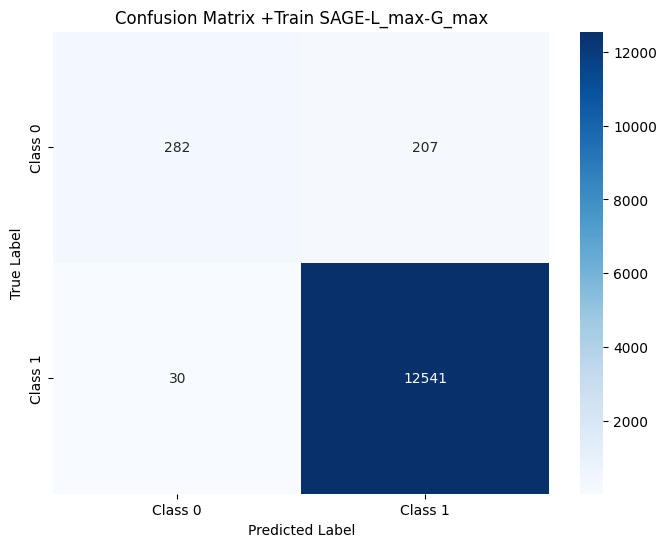

The function took 1.6553 seconds to execute.

📊 Classification Report - Validation (SAGE-L_max-G_max)
              precision    recall  f1-score   support

     Class 0     0.8955    0.4918    0.6349       122
     Class 1     0.9806    0.9978    0.9891      3143

    accuracy                         0.9789      3265
   macro avg     0.9381    0.7448    0.8120      3265
weighted avg     0.9774    0.9789    0.9759      3265




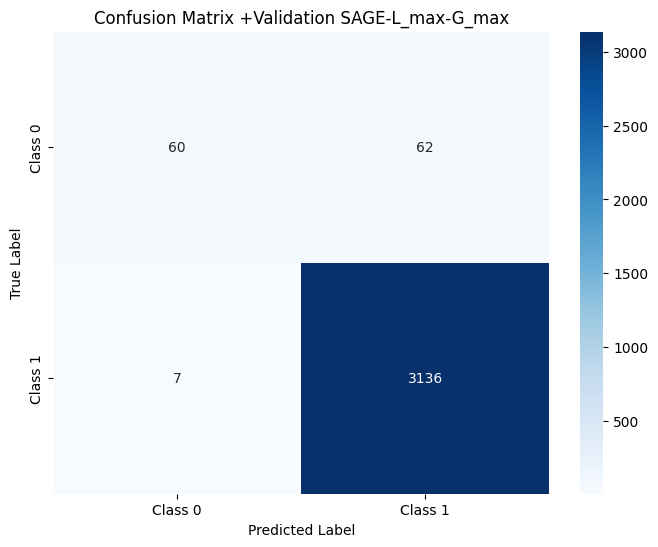

The function took 0.5409 seconds to execute.

📊 Classification Report - Test (SAGE-L_max-G_max)
              precision    recall  f1-score   support

     Class 0     0.7710    0.4156    0.5401       243
     Class 1     0.9777    0.9952    0.9864      6262

    accuracy                         0.9736      6505
   macro avg     0.8744    0.7054    0.7632      6505
weighted avg     0.9700    0.9736    0.9697      6505




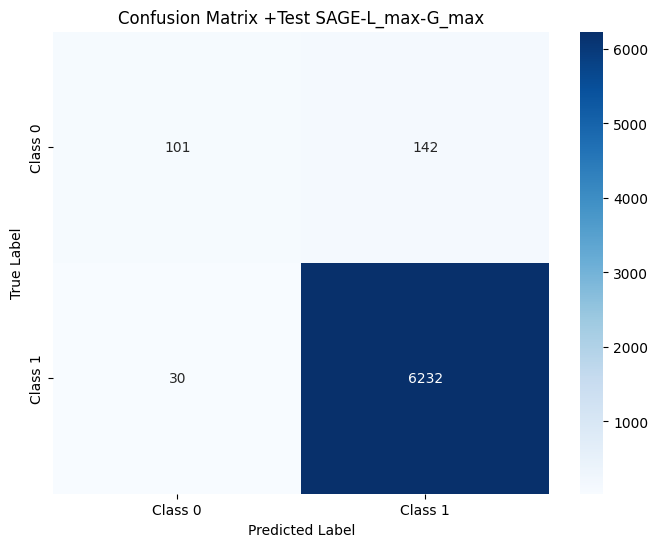

The function took 0.8711 seconds to execute.

Start Experiment ───▶ [Local: max] | [Global: sum]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:18<05:54,  3.73s/it]

Epoch 5/100 | Train Loss: 0.0907 | Val Loss: 0.0958


Training Epochs:  10%|█         | 10/100 [00:36<05:28,  3.65s/it]

Epoch 10/100 | Train Loss: 0.0663 | Val Loss: 0.0800


...

Epoch 45/100 | Train Loss: 0.0551 | Val Loss: 0.0704


Training Epochs:  50%|█████     | 50/100 [02:44<02:37,  3.14s/it]

Epoch 50/100 | Train Loss: 0.0530 | Val Loss: 0.0705


Training Epochs:  53%|█████▎    | 53/100 [02:57<02:37,  3.35s/it]


[Early Stopping] Triggered at epoch 54. No improvement over 15 consecutive epochs.
Epoch 54/100 | Final Train Loss: 0.0528 | Final Val Loss: 0.0749

Training complete. Execution time: 177.42 seconds.
Successfully restored the best model weights from 'best_model.pth'.


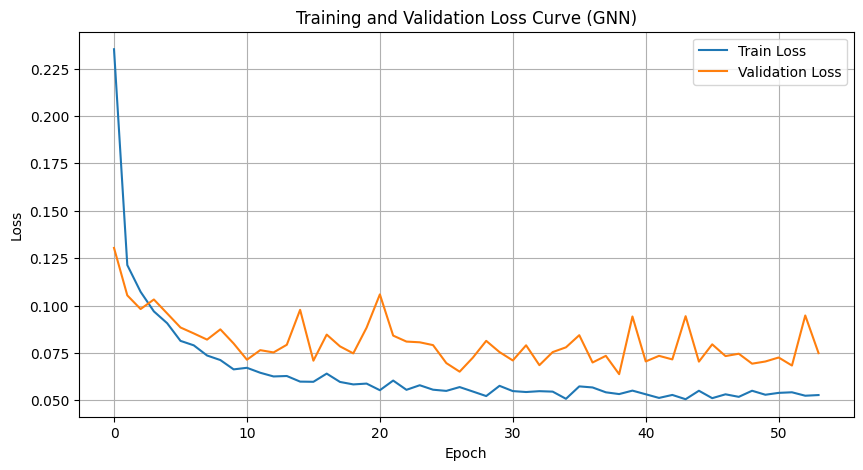


📊 Classification Report - Train (SAGE-L_max-G_sum)
              precision    recall  f1-score   support

     Class 0     0.9031    0.7239    0.8036       489
     Class 1     0.9893    0.9970    0.9931     12571

    accuracy                         0.9868     13060
   macro avg     0.9462    0.8605    0.8984     13060
weighted avg     0.9861    0.9868    0.9860     13060




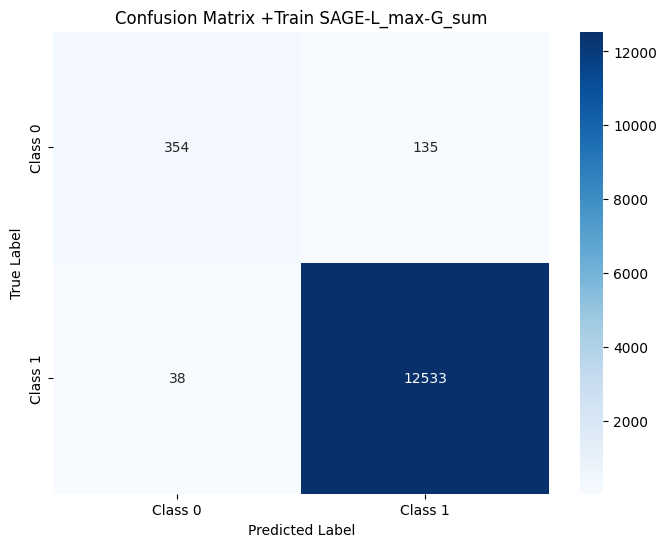

The function took 1.4200 seconds to execute.

📊 Classification Report - Validation (SAGE-L_max-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8519    0.5656    0.6798       122
     Class 1     0.9834    0.9962    0.9897      3143

    accuracy                         0.9801      3265
   macro avg     0.9176    0.7809    0.8348      3265
weighted avg     0.9784    0.9801    0.9781      3265




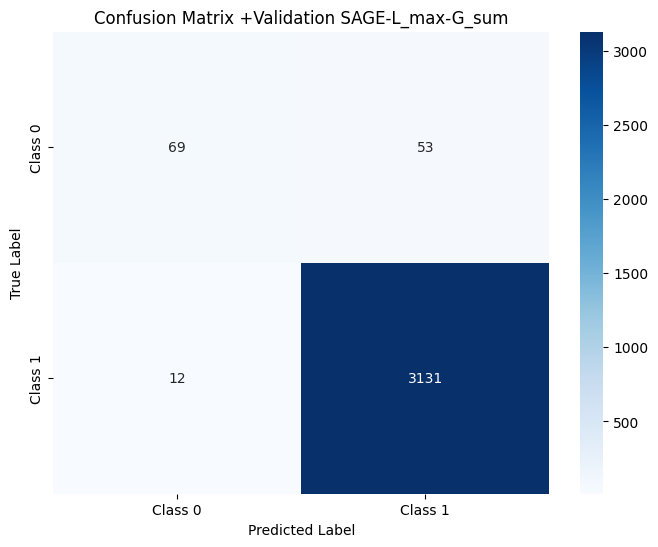

The function took 0.4563 seconds to execute.

📊 Classification Report - Test (SAGE-L_max-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7459    0.5556    0.6368       243
     Class 1     0.9829    0.9927    0.9878      6262

    accuracy                         0.9763      6505
   macro avg     0.8644    0.7741    0.8123      6505
weighted avg     0.9741    0.9763    0.9747      6505




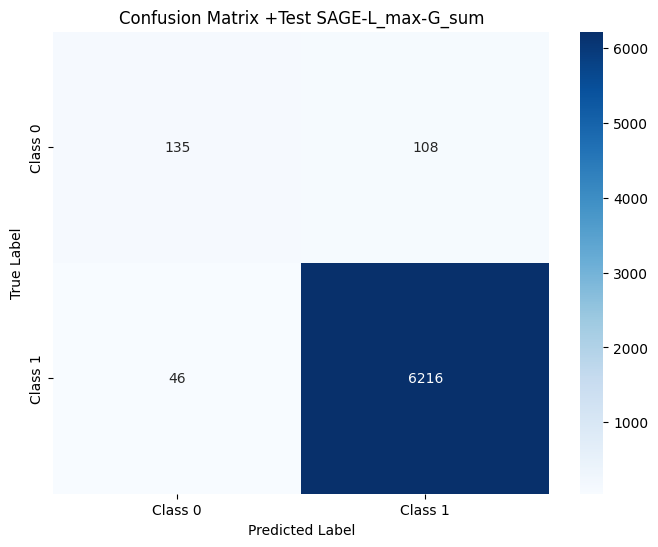

The function took 0.6743 seconds to execute.

Start Experiment ───▶ [Local: sum] | [Global: mean]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:14<04:25,  2.79s/it]

Epoch 5/100 | Train Loss: 0.0876 | Val Loss: 0.0878


Training Epochs:  10%|█         | 10/100 [00:29<04:25,  2.95s/it]

Epoch 10/100 | Train Loss: 0.0764 | Val Loss: 0.0935


...

Epoch 30/100 | Train Loss: 0.0623 | Val Loss: 0.0739


Training Epochs:  35%|███▌      | 35/100 [01:40<03:04,  2.83s/it]

Epoch 35/100 | Train Loss: 0.0603 | Val Loss: 0.0876


Training Epochs:  36%|███▌      | 36/100 [01:46<03:08,  2.95s/it]


[Early Stopping] Triggered at epoch 37. No improvement over 15 consecutive epochs.
Epoch 37/100 | Final Train Loss: 0.0622 | Final Val Loss: 0.0762

Training complete. Execution time: 106.07 seconds.
Successfully restored the best model weights from 'best_model.pth'.


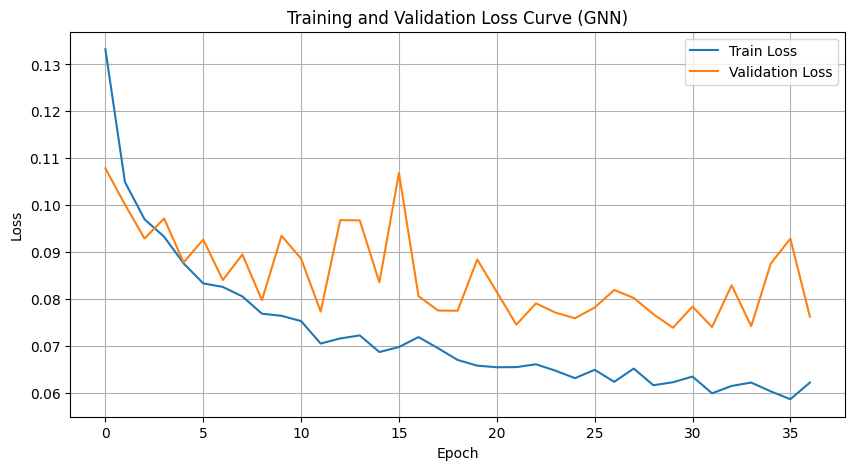


📊 Classification Report - Train (SAGE-L_sum-G_mean)
              precision    recall  f1-score   support

     Class 0     0.9189    0.4867    0.6364       489
     Class 1     0.9804    0.9983    0.9893     12571

    accuracy                         0.9792     13060
   macro avg     0.9497    0.7425    0.8128     13060
weighted avg     0.9781    0.9792    0.9761     13060




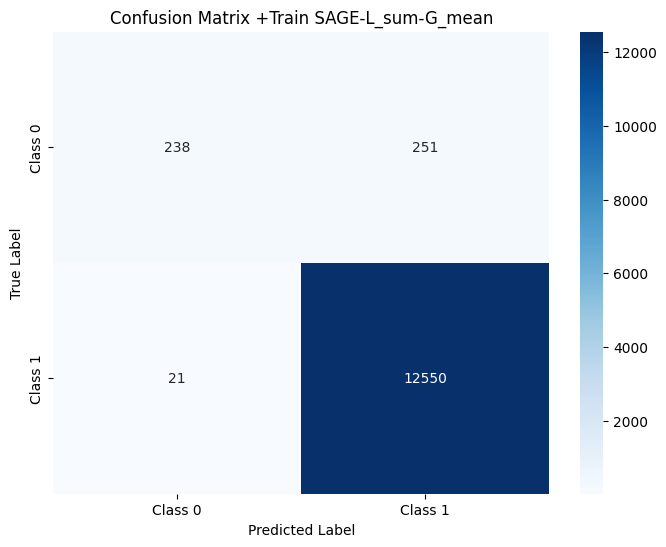

The function took 1.4601 seconds to execute.

📊 Classification Report - Validation (SAGE-L_sum-G_mean)
              precision    recall  f1-score   support

     Class 0     0.8507    0.4672    0.6032       122
     Class 1     0.9797    0.9968    0.9882      3143

    accuracy                         0.9770      3265
   macro avg     0.9152    0.7320    0.7957      3265
weighted avg     0.9749    0.9770    0.9738      3265




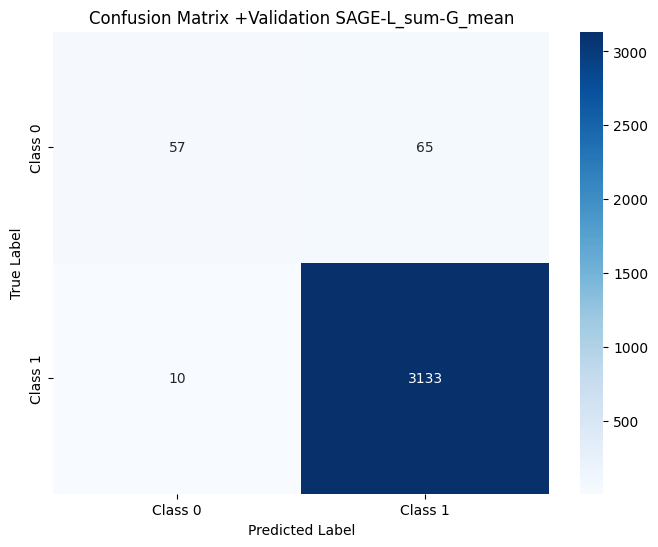

The function took 3.8961 seconds to execute.

📊 Classification Report - Test (SAGE-L_sum-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7966    0.3868    0.5208       243
     Class 1     0.9767    0.9962    0.9863      6262

    accuracy                         0.9734      6505
   macro avg     0.8866    0.6915    0.7535      6505
weighted avg     0.9699    0.9734    0.9689      6505




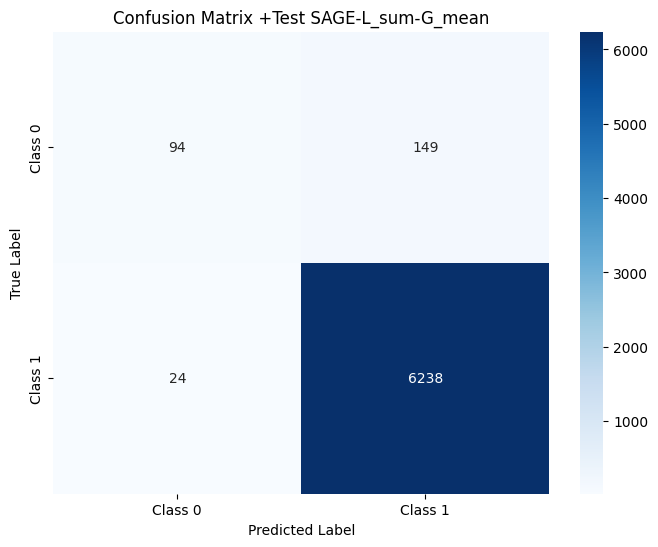

The function took 0.8613 seconds to execute.

Start Experiment ───▶ [Local: sum] | [Global: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:15<04:53,  3.09s/it]

Epoch 5/100 | Train Loss: 0.0817 | Val Loss: 0.0740


Training Epochs:  10%|█         | 10/100 [00:29<04:21,  2.90s/it]

Epoch 10/100 | Train Loss: 0.0681 | Val Loss: 0.0694


...

Epoch 35/100 | Train Loss: 0.0570 | Val Loss: 0.0656


Training Epochs:  40%|████      | 40/100 [01:21<01:27,  1.46s/it]

Epoch 40/100 | Train Loss: 0.0560 | Val Loss: 0.0647


Training Epochs:  40%|████      | 40/100 [01:22<02:03,  2.06s/it]


[Early Stopping] Triggered at epoch 41. No improvement over 15 consecutive epochs.
Epoch 41/100 | Final Train Loss: 0.0590 | Final Val Loss: 0.0934

Training complete. Execution time: 82.52 seconds.
Successfully restored the best model weights from 'best_model.pth'.


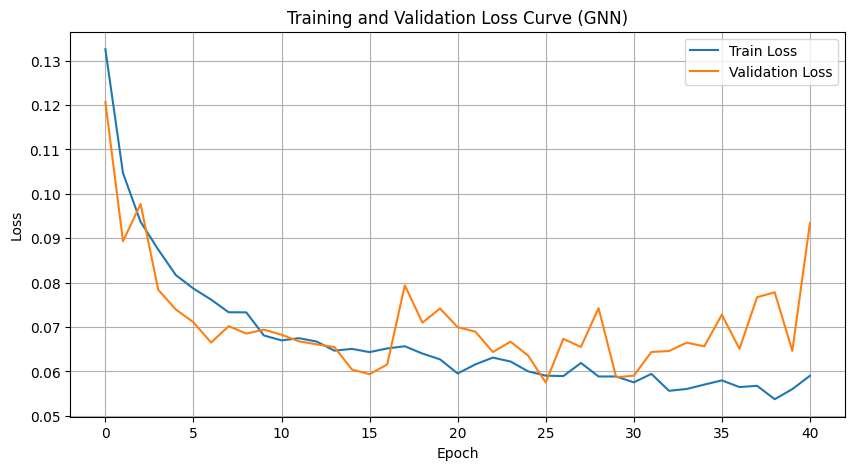


📊 Classification Report - Train (SAGE-L_sum-G_max)
              precision    recall  f1-score   support

     Class 0     0.9408    0.6830    0.7915       489
     Class 1     0.9878    0.9983    0.9930     12571

    accuracy                         0.9865     13060
   macro avg     0.9643    0.8407    0.8923     13060
weighted avg     0.9860    0.9865    0.9855     13060




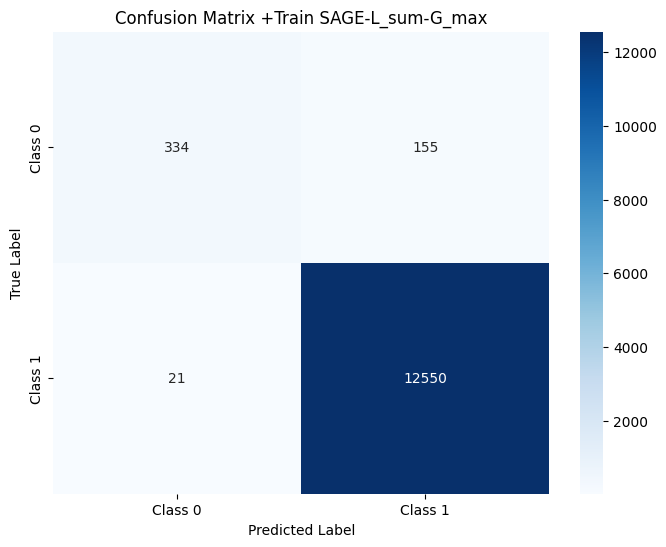

The function took 0.7177 seconds to execute.

📊 Classification Report - Validation (SAGE-L_sum-G_max)
              precision    recall  f1-score   support

     Class 0     0.8690    0.5984    0.7087       122
     Class 1     0.9846    0.9965    0.9905      3143

    accuracy                         0.9816      3265
   macro avg     0.9268    0.7974    0.8496      3265
weighted avg     0.9803    0.9816    0.9800      3265




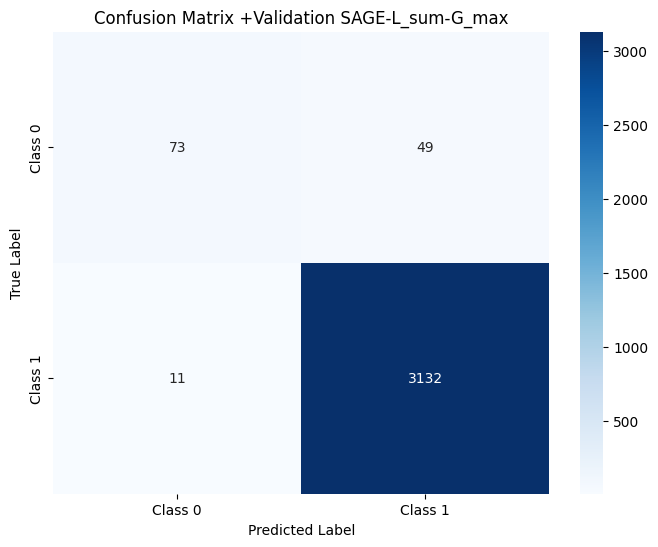

The function took 0.2171 seconds to execute.

📊 Classification Report - Test (SAGE-L_sum-G_max)
              precision    recall  f1-score   support

     Class 0     0.8027    0.4856    0.6051       243
     Class 1     0.9803    0.9954    0.9878      6262

    accuracy                         0.9763      6505
   macro avg     0.8915    0.7405    0.7965      6505
weighted avg     0.9737    0.9763    0.9735      6505




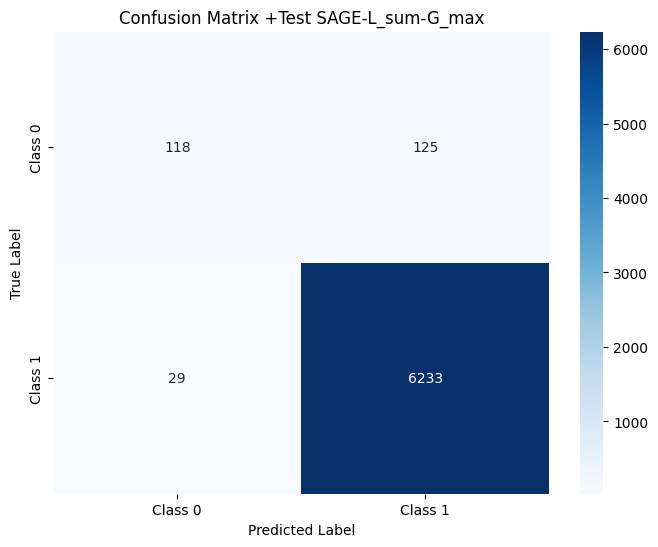

The function took 0.3980 seconds to execute.

Start Experiment ───▶ [Local: sum] | [Global: sum]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:06<02:03,  1.30s/it]

Epoch 5/100 | Train Loss: 0.0888 | Val Loss: 0.1046


Training Epochs:  10%|█         | 10/100 [00:12<01:56,  1.29s/it]

Epoch 10/100 | Train Loss: 0.0777 | Val Loss: 0.0815


...

Epoch 20/100 | Train Loss: 0.0659 | Val Loss: 0.0862


Training Epochs:  25%|██▌       | 25/100 [00:33<01:38,  1.31s/it]

Epoch 25/100 | Train Loss: 0.0632 | Val Loss: 0.0735


Training Epochs:  27%|██▋       | 27/100 [00:37<01:41,  1.39s/it]


[Early Stopping] Triggered at epoch 28. No improvement over 15 consecutive epochs.
Epoch 28/100 | Final Train Loss: 0.0650 | Final Val Loss: 0.0729

Training complete. Execution time: 37.54 seconds.
Successfully restored the best model weights from 'best_model.pth'.


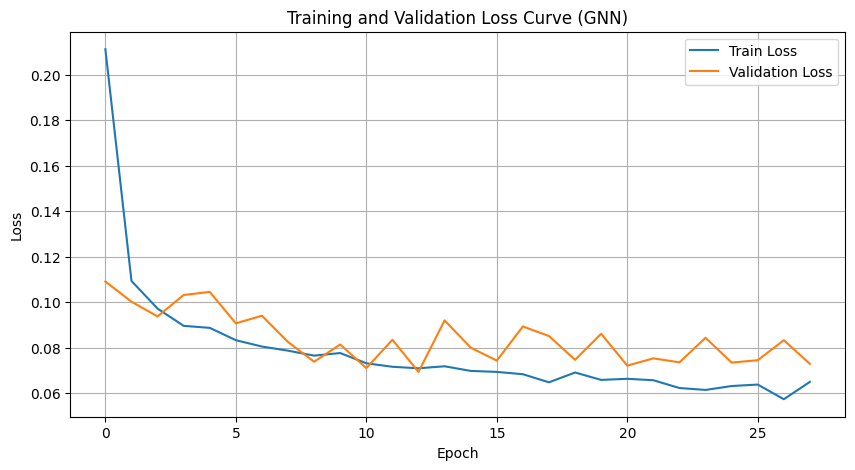


📊 Classification Report - Train (SAGE-L_sum-G_sum)
              precision    recall  f1-score   support

     Class 0     0.9199    0.5869    0.7166       489
     Class 1     0.9842    0.9980    0.9910     12571

    accuracy                         0.9826     13060
   macro avg     0.9520    0.7925    0.8538     13060
weighted avg     0.9817    0.9826    0.9808     13060




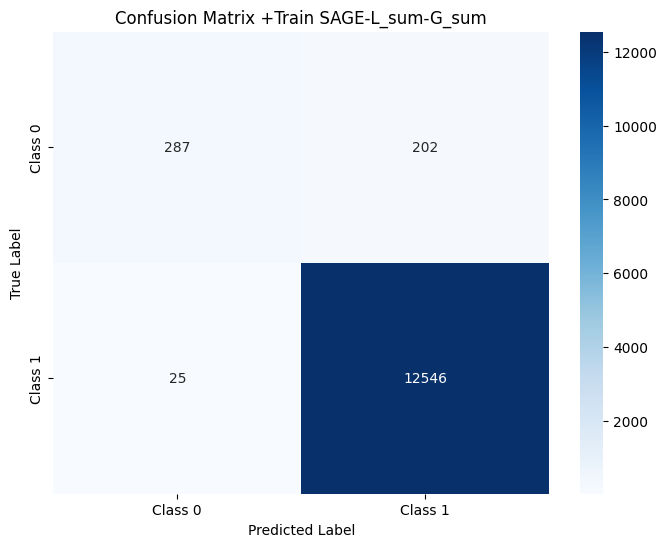

The function took 0.6882 seconds to execute.

📊 Classification Report - Validation (SAGE-L_sum-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8400    0.5164    0.6396       122
     Class 1     0.9815    0.9962    0.9888      3143

    accuracy                         0.9783      3265
   macro avg     0.9108    0.7563    0.8142      3265
weighted avg     0.9762    0.9783    0.9757      3265




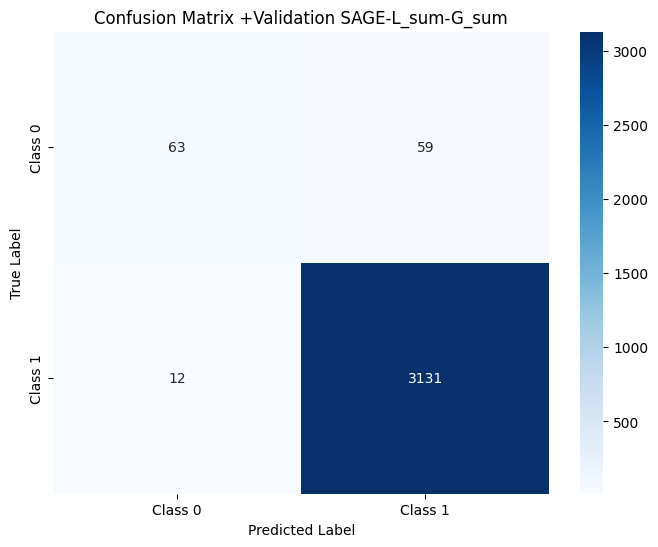

The function took 0.2228 seconds to execute.

📊 Classification Report - Test (SAGE-L_sum-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8188    0.4650    0.5932       243
     Class 1     0.9796    0.9960    0.9877      6262

    accuracy                         0.9762      6505
   macro avg     0.8992    0.7305    0.7905      6505
weighted avg     0.9736    0.9762    0.9730      6505




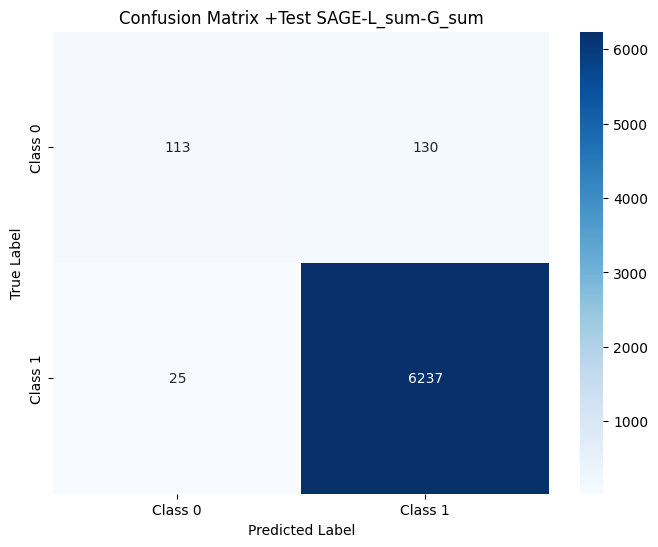

The function took 0.3840 seconds to execute.

🏆 ALL GRAPHSAGE EXPERIMENTS COMPLETED!
Local_Aggregation Global_Aggregation  Train_Acc_%  Val_Acc_%  Test_Acc_%
             mean               mean        96.81      96.75       96.71
             mean                max        97.83      97.00       97.03
             mean                sum        98.45      97.70       97.52
              max               mean        97.98      97.49       97.02
              max                max        98.19      97.89       97.36
              max                sum        98.68      98.01       97.63
              sum               mean        97.92      97.70       97.34
              sum                max        98.65      98.16       97.63
              sum                sum        98.26      97.83       97.62


In [19]:
import pandas as pd
import torch

# Fix critical hyperparameters to isolate topological variables
OPTIMIZER_LR = 0.005      # Golden learning rate optimized for GraphSAGE mixed aggregations

# 2D aggregation search space focusing exclusively on topological pooling (3 x 3 = 9 variations)
local_aggregations = ['mean', 'max', 'sum']
global_aggregations = ['mean', 'max', 'sum']

# List to collect and store metric records for all configurations
experimental_summary = []

print("============================================================")
print("🚀 Starting Streamlined Grid Search for GraphSAGE (9 Variations)...")
print("============================================================")

for local_aggr in local_aggregations:
    for global_aggr in global_aggregations:
        
        print(f"\nStart Experiment ───▶ [Local: {local_aggr}] | [Global: {global_aggr}]")
        print("-" * 70)
        
        # Initialize GraphSAGE model instance with the current hyperparameter mix
        model = GraphSAGE(
            vocabulary_size=len(global_vocab_to_id),
            embedding_dim=FIXED_EMBEDDING_DIM,
            hidden_dim=FIXED_HIDDEN_DIM,
            output_dim=2,
            local_aggr=local_aggr,
            global_aggr=global_aggr,
            dropout_p=0.4
        ).to(device)
        
        # Reset the optimizer to bind cleanly to the new model parameter tree
        optimizer = torch.optim.Adam(model.parameters(), lr=OPTIMIZER_LR, weight_decay=5e-4)
        criterion = torch.nn.CrossEntropyLoss()
        
        # Stage 1: Execute Training Pipeline with Early Stopping
        training_loop(
            model=model, train_loader=train_loader, val_loader=val_loader,
            train_dataset=train_dataset, val_dataset=val_dataset,
            device=device, optimizer=optimizer, num_epochs=MAX_EPOCHS,
            criterion=criterion, patience=PATIENCE, min_delta=0.001
        )
        
        # Stage 2: Multi-Dataset Diagnostic Evaluation (Train vs Validation vs Test)
        current_model_tag = f"SAGE-L_{local_aggr}-G_{global_aggr}"
        train_acc = testing_model(model, train_loader, device, "Train", current_model_tag)
        val_acc = testing_model(model, val_loader, device, "Validation", current_model_tag)
        test_acc = testing_model(model, test_loader, device, "Test", current_model_tag)
        
        # Stage 3: Append current metrics into our summary tracking list
        experimental_summary.append({
            'Local_Aggregation': local_aggr,
            'Global_Aggregation': global_aggr,
            'Train_Acc_%': round(train_acc, 2),
            'Val_Acc_%': round(val_acc, 2),
            'Test_Acc_%': round(test_acc, 2)
        })

# Output the final comprehensive summary table to the console
df_results = pd.DataFrame(experimental_summary)
print("\n" + "=" * 80)
print("🏆 ALL GRAPHSAGE EXPERIMENTS COMPLETED!")
print("=" * 80)
print(df_results.to_string(index=False))

# Export results to a dedicated CSV file for report data visualization
df_results.to_csv('graphsage_aggregation_results.csv', index=False)

🚀 Starting Streamlined Grid Search for GAT (9 Variations)...
🔧 Configured Learning Rate: 0.002

Start Experiment ───▶ [Heads: 1] | [Global Readout: mean]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:11<03:36,  2.27s/it]

Epoch 5/100 | Train Loss: 0.1316 | Val Loss: 0.1211


Training Epochs:  10%|█         | 10/100 [00:23<03:27,  2.30s/it]

Epoch 10/100 | Train Loss: 0.1186 | Val Loss: 0.1095


...

Epoch 30/100 | Train Loss: 0.1104 | Val Loss: 0.1093


Training Epochs:  35%|███▌      | 35/100 [01:17<02:15,  2.09s/it]

Epoch 35/100 | Train Loss: 0.1092 | Val Loss: 0.1095


Training Epochs:  38%|███▊      | 38/100 [01:27<02:22,  2.30s/it]


[Early Stopping] Triggered at epoch 39. No improvement over 15 consecutive epochs.
Epoch 39/100 | Final Train Loss: 0.1104 | Final Val Loss: 0.1074

Training complete. Execution time: 87.38 seconds.
Successfully restored the best model weights from 'best_model.pth'.


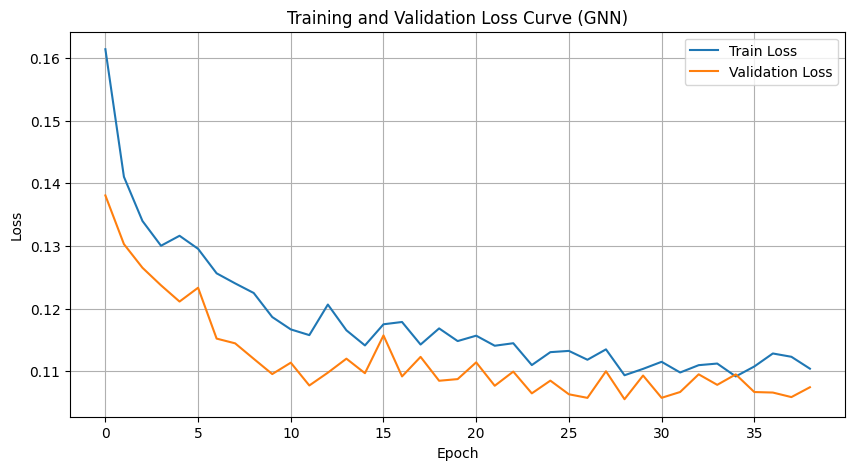


📊 Classification Report - Train (GAT-H_1-G_mean)
              precision    recall  f1-score   support

     Class 0     0.8958    0.1759    0.2940       489
     Class 1     0.9689    0.9992    0.9838     12571

    accuracy                         0.9684     13060
   macro avg     0.9324    0.5875    0.6389     13060
weighted avg     0.9662    0.9684    0.9580     13060




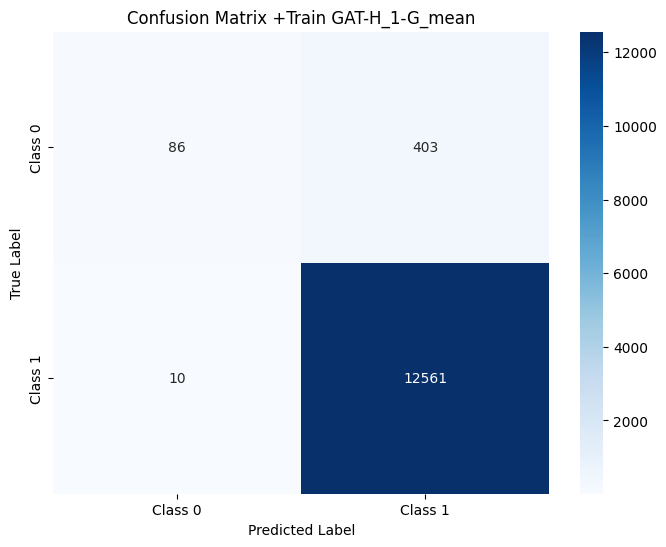

The function took 1.1563 seconds to execute.

📊 Classification Report - Validation (GAT-H_1-G_mean)
              precision    recall  f1-score   support

     Class 0     0.8214    0.1885    0.3067       122
     Class 1     0.9694    0.9984    0.9837      3143

    accuracy                         0.9681      3265
   macro avg     0.8954    0.5935    0.6452      3265
weighted avg     0.9639    0.9681    0.9584      3265




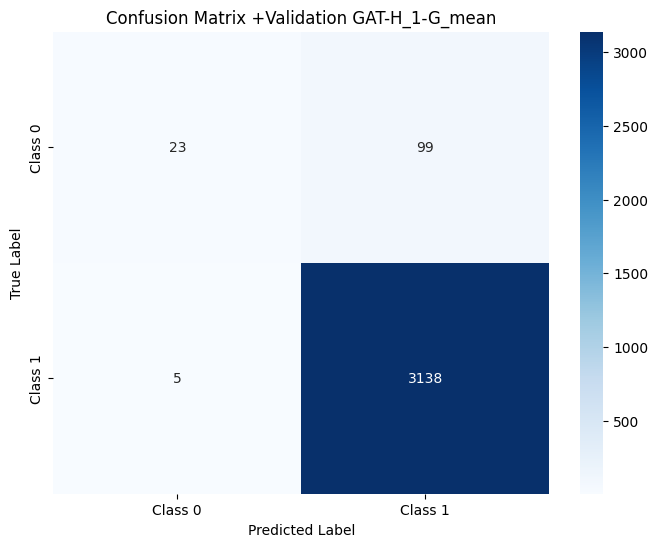

The function took 0.3314 seconds to execute.

📊 Classification Report - Test (GAT-H_1-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7941    0.1111    0.1949       243
     Class 1     0.9666    0.9989    0.9825      6262

    accuracy                         0.9657      6505
   macro avg     0.8804    0.5550    0.5887      6505
weighted avg     0.9602    0.9657    0.9531      6505




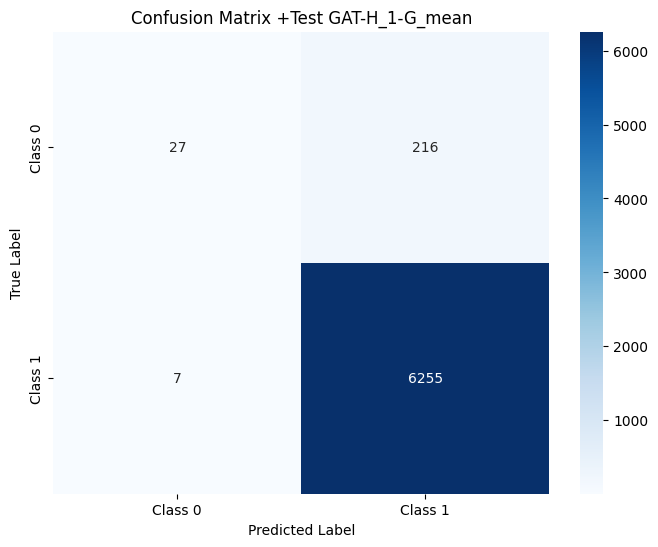

The function took 0.5868 seconds to execute.
▶▶▶ Result | Train: 96.84% | Val: 96.81% | Test: 96.57%

Start Experiment ───▶ [Heads: 1] | [Global Readout: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:11<03:31,  2.23s/it]

Epoch 5/100 | Train Loss: 0.1262 | Val Loss: 0.1372


Training Epochs:  10%|█         | 10/100 [00:22<03:18,  2.20s/it]

Epoch 10/100 | Train Loss: 0.1186 | Val Loss: 0.1214


...

Epoch 35/100 | Train Loss: 0.1087 | Val Loss: 0.1180


Training Epochs:  40%|████      | 40/100 [01:30<02:10,  2.17s/it]

Epoch 40/100 | Train Loss: 0.1040 | Val Loss: 0.1161


Training Epochs:  42%|████▏     | 42/100 [01:37<02:15,  2.33s/it]


[Early Stopping] Triggered at epoch 43. No improvement over 15 consecutive epochs.
Epoch 43/100 | Final Train Loss: 0.1068 | Final Val Loss: 0.1205

Training complete. Execution time: 97.90 seconds.
Successfully restored the best model weights from 'best_model.pth'.


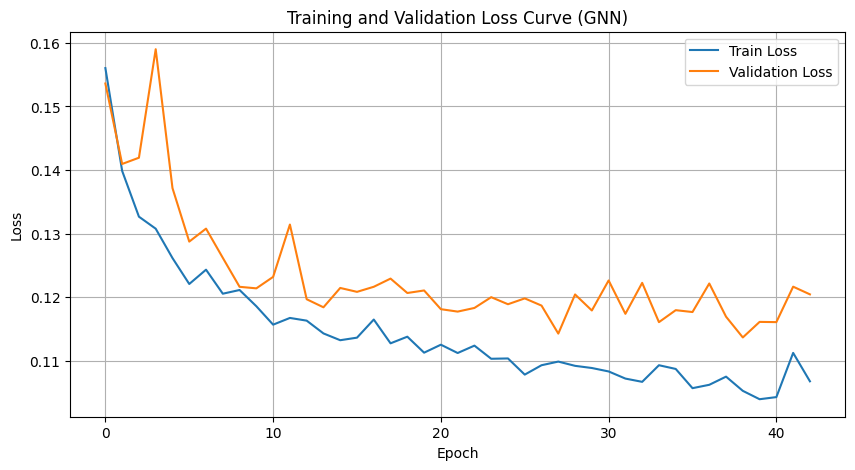


📊 Classification Report - Train (GAT-H_1-G_max)
              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000       489
     Class 1     0.9626    1.0000    0.9809     12571

    accuracy                         0.9626     13060
   macro avg     0.4813    0.5000    0.4905     13060
weighted avg     0.9265    0.9626    0.9442     13060




/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

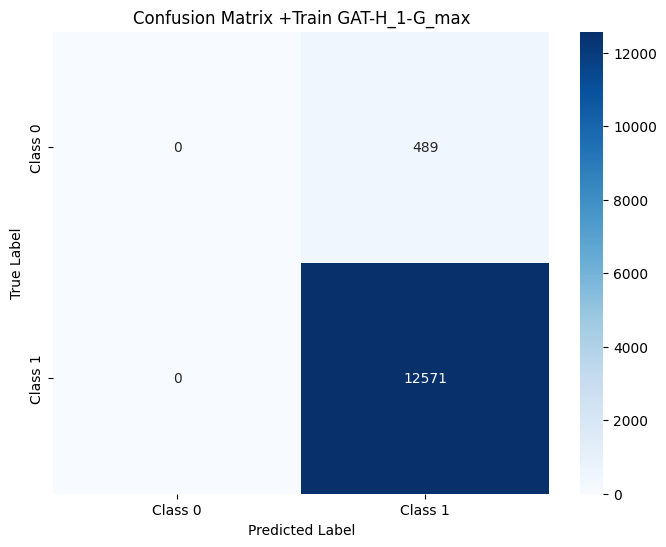

The function took 1.1426 seconds to execute.

📊 Classification Report - Validation (GAT-H_1-G_max)
              precision    recall  f1-score   support

     Class 0     0.0000    0.0000    0.0000       122
     Class 1     0.9626    1.0000    0.9810      3143

    accuracy                         0.9626      3265
   macro avg     0.4813    0.5000    0.4905      3265
weighted avg     0.9267    0.9626    0.9443      3265




/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

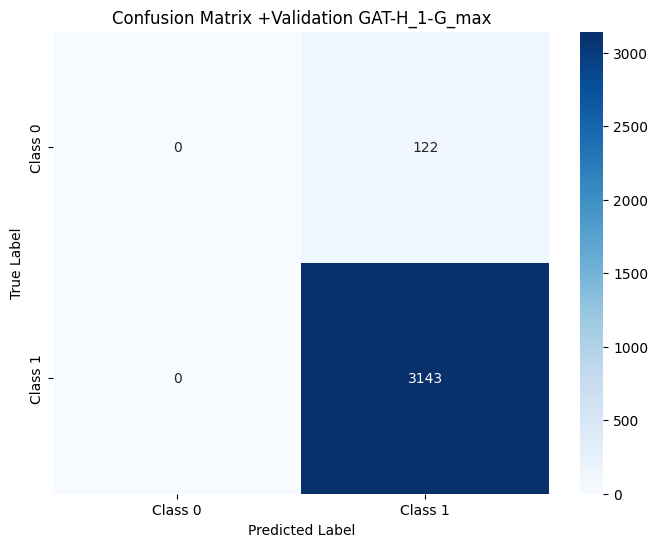

The function took 0.3556 seconds to execute.

📊 Classification Report - Test (GAT-H_1-G_max)
              precision    recall  f1-score   support

     Class 0     1.0000    0.0041    0.0082       243
     Class 1     0.9628    1.0000    0.9810      6262

    accuracy                         0.9628      6505
   macro avg     0.9814    0.5021    0.4946      6505
weighted avg     0.9642    0.9628    0.9447      6505




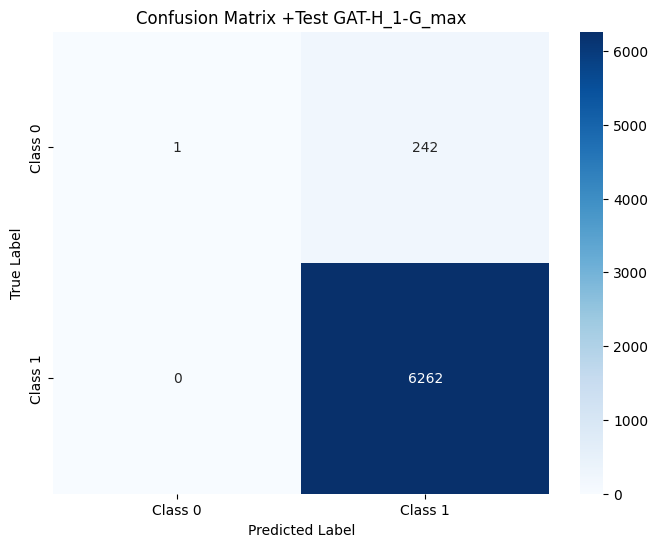

The function took 0.6069 seconds to execute.
▶▶▶ Result | Train: 96.26% | Val: 96.26% | Test: 96.28%

Start Experiment ───▶ [Heads: 1] | [Global Readout: sum]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:10<03:28,  2.20s/it]

Epoch 5/100 | Train Loss: 0.1217 | Val Loss: 0.1102


Training Epochs:  10%|█         | 10/100 [00:21<03:13,  2.15s/it]

Epoch 10/100 | Train Loss: 0.1145 | Val Loss: 0.1098


...

Epoch 15/100 | Train Loss: 0.1128 | Val Loss: 0.1079


Training Epochs:  20%|██        | 20/100 [00:43<02:50,  2.14s/it]

Epoch 20/100 | Train Loss: 0.1106 | Val Loss: 0.1076


Training Epochs:  20%|██        | 20/100 [00:45<03:03,  2.29s/it]


[Early Stopping] Triggered at epoch 21. No improvement over 15 consecutive epochs.
Epoch 21/100 | Final Train Loss: 0.1088 | Final Val Loss: 0.1032

Training complete. Execution time: 45.87 seconds.
Successfully restored the best model weights from 'best_model.pth'.


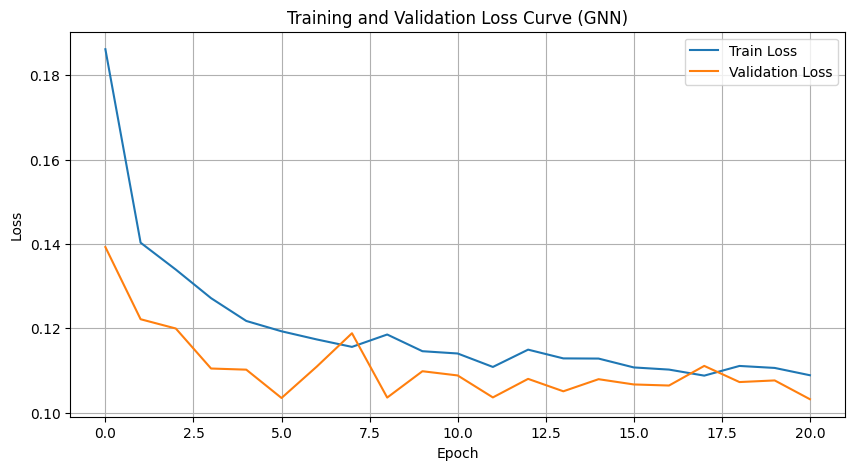


📊 Classification Report - Train (GAT-H_1-G_sum)
              precision    recall  f1-score   support

     Class 0     0.9070    0.1595    0.2713       489
     Class 1     0.9683    0.9994    0.9836     12571

    accuracy                         0.9679     13060
   macro avg     0.9376    0.5794    0.6275     13060
weighted avg     0.9660    0.9679    0.9569     13060




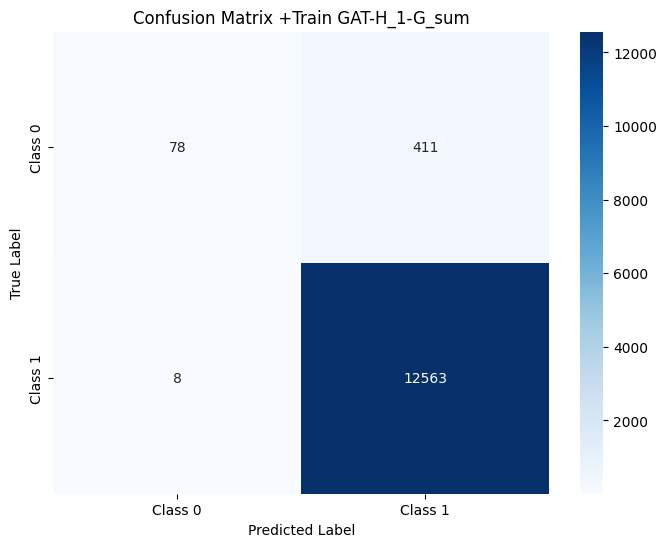

The function took 1.1134 seconds to execute.

📊 Classification Report - Validation (GAT-H_1-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7826    0.1475    0.2483       122
     Class 1     0.9679    0.9984    0.9829      3143

    accuracy                         0.9666      3265
   macro avg     0.8753    0.5730    0.6156      3265
weighted avg     0.9610    0.9666    0.9555      3265




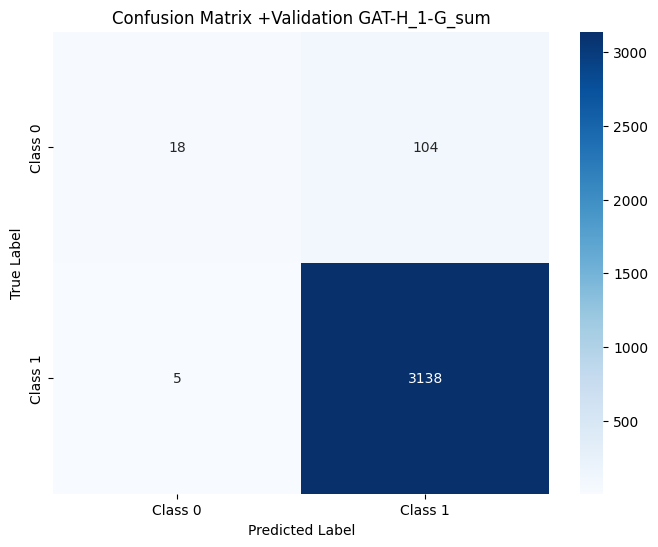

The function took 0.3209 seconds to execute.

📊 Classification Report - Test (GAT-H_1-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7500    0.0988    0.1745       243
     Class 1     0.9662    0.9987    0.9822      6262

    accuracy                         0.9651      6505
   macro avg     0.8581    0.5487    0.5784      6505
weighted avg     0.9581    0.9651    0.9520      6505




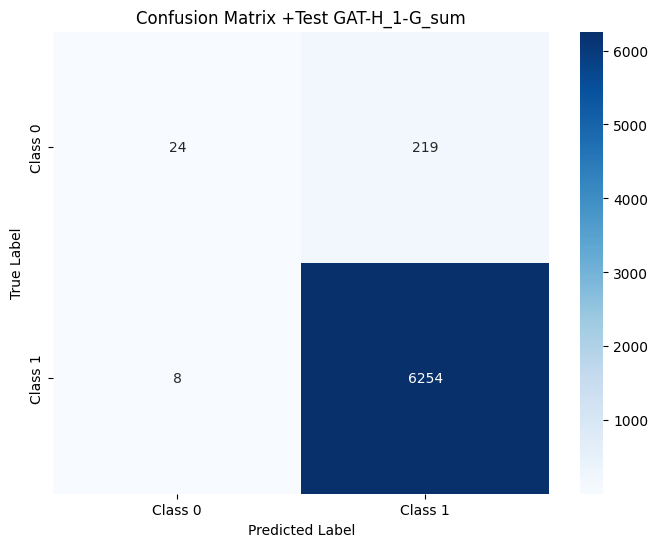

The function took 0.5795 seconds to execute.
▶▶▶ Result | Train: 96.79% | Val: 96.66% | Test: 96.51%

Start Experiment ───▶ [Heads: 4] | [Global Readout: mean]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:11<03:54,  2.46s/it]

Epoch 5/100 | Train Loss: 0.1210 | Val Loss: 0.1171


Training Epochs:  10%|█         | 10/100 [00:22<03:18,  2.21s/it]

Epoch 10/100 | Train Loss: 0.1162 | Val Loss: 0.1147


...

Epoch 25/100 | Train Loss: 0.1138 | Val Loss: 0.1134


Training Epochs:  30%|███       | 30/100 [01:06<02:30,  2.16s/it]

Epoch 30/100 | Train Loss: 0.1096 | Val Loss: 0.1126


Training Epochs:  32%|███▏      | 32/100 [01:13<02:36,  2.30s/it]


[Early Stopping] Triggered at epoch 33. No improvement over 15 consecutive epochs.
Epoch 33/100 | Final Train Loss: 0.1079 | Final Val Loss: 0.1148

Training complete. Execution time: 73.74 seconds.
Successfully restored the best model weights from 'best_model.pth'.


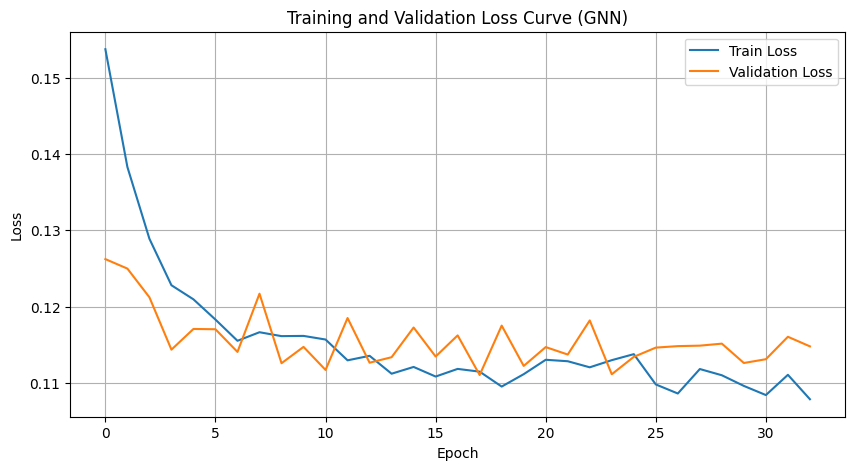


📊 Classification Report - Train (GAT-H_4-G_mean)
              precision    recall  f1-score   support

     Class 0     0.9067    0.1391    0.2411       489
     Class 1     0.9676    0.9994    0.9833     12571

    accuracy                         0.9672     13060
   macro avg     0.9371    0.5693    0.6122     13060
weighted avg     0.9653    0.9672    0.9555     13060




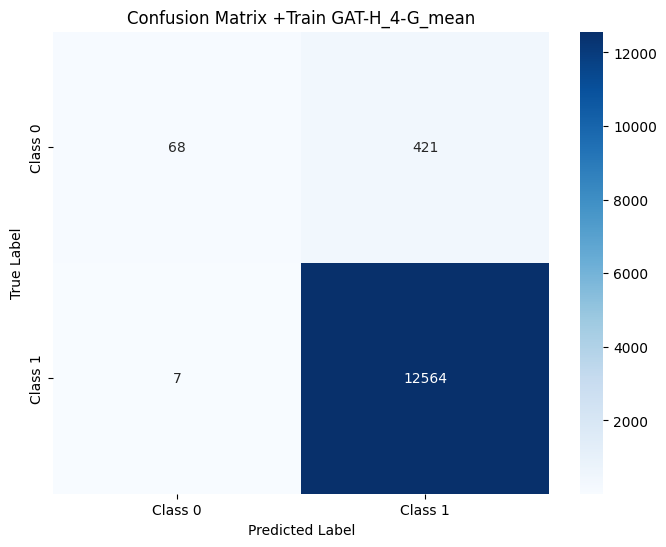

The function took 1.1345 seconds to execute.

📊 Classification Report - Validation (GAT-H_4-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7500    0.1230    0.2113       122
     Class 1     0.9670    0.9984    0.9825      3143

    accuracy                         0.9657      3265
   macro avg     0.8585    0.5607    0.5969      3265
weighted avg     0.9589    0.9657    0.9537      3265




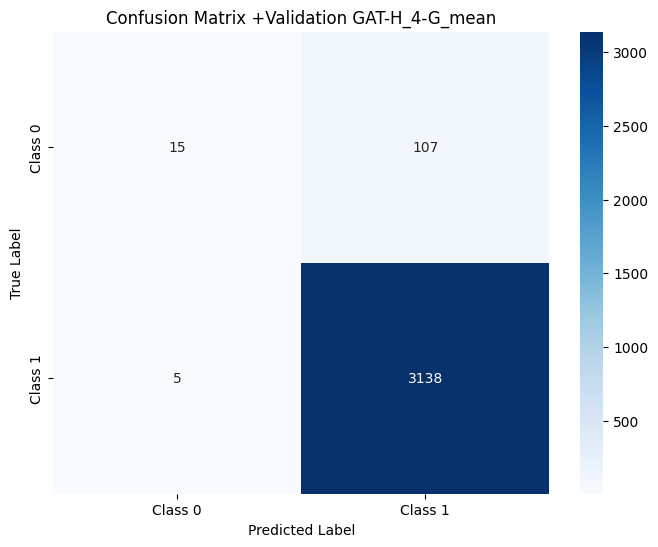

The function took 0.3420 seconds to execute.

📊 Classification Report - Test (GAT-H_4-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7857    0.0905    0.1624       243
     Class 1     0.9659    0.9990    0.9822      6262

    accuracy                         0.9651      6505
   macro avg     0.8758    0.5448    0.5723      6505
weighted avg     0.9591    0.9651    0.9516      6505




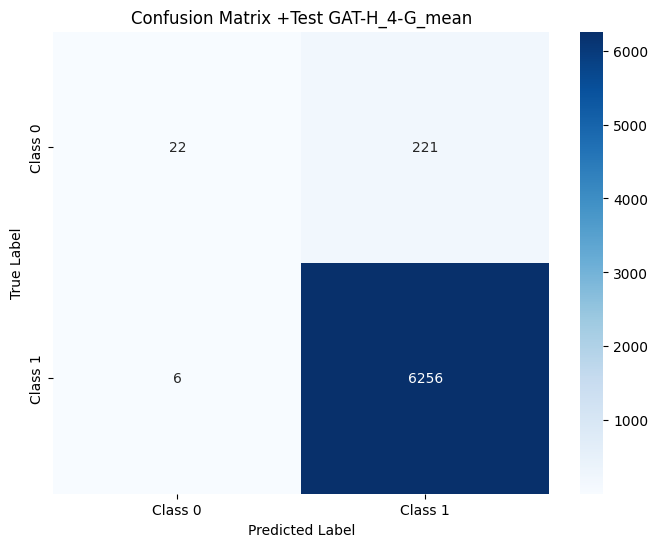

The function took 0.5981 seconds to execute.
▶▶▶ Result | Train: 96.72% | Val: 96.57% | Test: 96.51%

Start Experiment ───▶ [Heads: 4] | [Global Readout: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:12<03:37,  2.29s/it]

Epoch 5/100 | Train Loss: 0.1247 | Val Loss: 0.1286


Training Epochs:  10%|█         | 10/100 [00:23<03:22,  2.25s/it]

Epoch 10/100 | Train Loss: 0.1140 | Val Loss: 0.1148


...

Epoch 45/100 | Train Loss: 0.1031 | Val Loss: 0.1063


Training Epochs:  50%|█████     | 50/100 [01:54<01:52,  2.24s/it]

Epoch 50/100 | Train Loss: 0.1014 | Val Loss: 0.1078


Training Epochs:  51%|█████     | 51/100 [01:59<01:54,  2.34s/it]


[Early Stopping] Triggered at epoch 52. No improvement over 15 consecutive epochs.
Epoch 52/100 | Final Train Loss: 0.1022 | Final Val Loss: 0.1060

Training complete. Execution time: 119.32 seconds.
Successfully restored the best model weights from 'best_model.pth'.


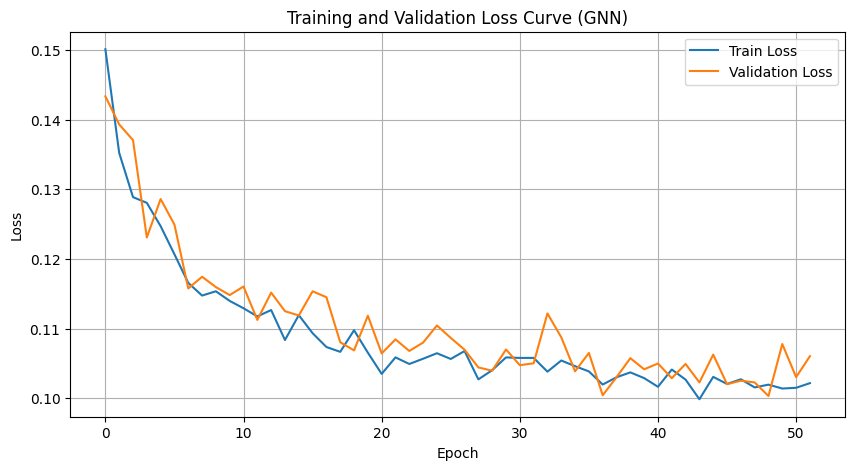


📊 Classification Report - Train (GAT-H_4-G_max)
              precision    recall  f1-score   support

     Class 0     0.9383    0.1554    0.2667       489
     Class 1     0.9682    0.9996    0.9836     12571

    accuracy                         0.9680     13060
   macro avg     0.9532    0.5775    0.6252     13060
weighted avg     0.9671    0.9680    0.9568     13060




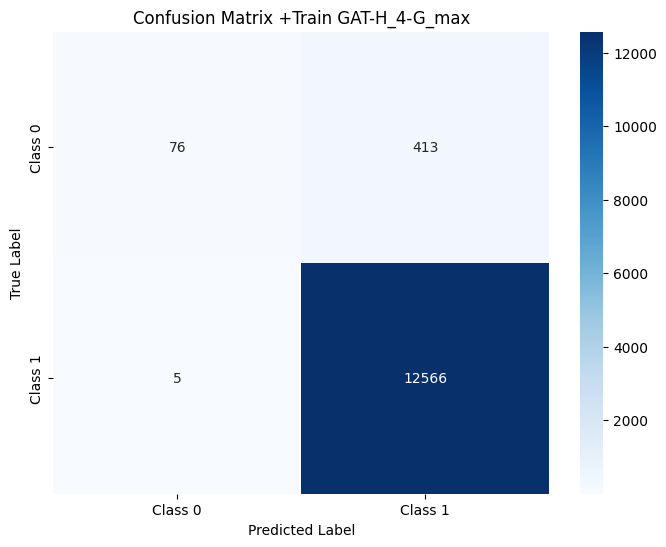

The function took 1.1023 seconds to execute.

📊 Classification Report - Validation (GAT-H_4-G_max)
              precision    recall  f1-score   support

     Class 0     0.9333    0.1148    0.2044       122
     Class 1     0.9668    0.9997    0.9830      3143

    accuracy                         0.9666      3265
   macro avg     0.9501    0.5572    0.5937      3265
weighted avg     0.9655    0.9666    0.9539      3265




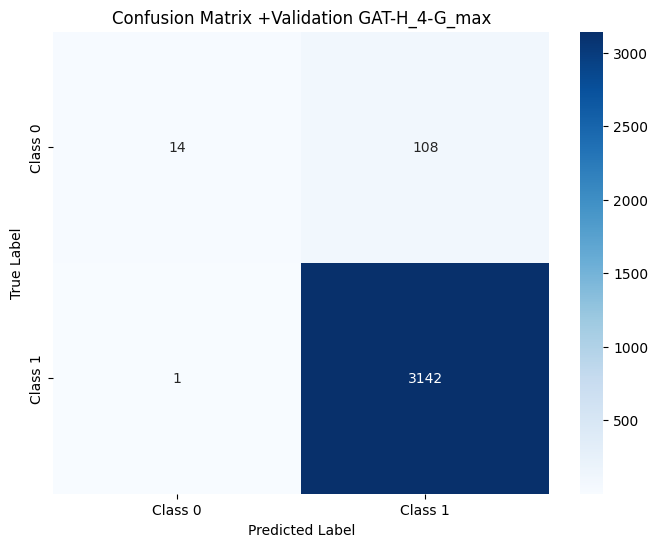

The function took 0.3373 seconds to execute.

📊 Classification Report - Test (GAT-H_4-G_max)
              precision    recall  f1-score   support

     Class 0     0.8333    0.1029    0.1832       243
     Class 1     0.9663    0.9992    0.9825      6262

    accuracy                         0.9657      6505
   macro avg     0.8998    0.5510    0.5828      6505
weighted avg     0.9614    0.9657    0.9526      6505




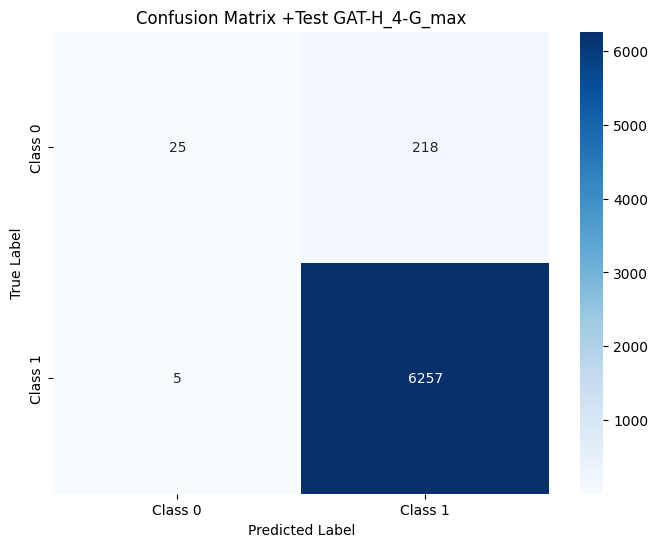

The function took 0.5869 seconds to execute.
▶▶▶ Result | Train: 96.80% | Val: 96.66% | Test: 96.57%

Start Experiment ───▶ [Heads: 4] | [Global Readout: sum]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:10<03:24,  2.16s/it]

Epoch 5/100 | Train Loss: 0.1140 | Val Loss: 0.1101


Training Epochs:  10%|█         | 10/100 [00:22<03:23,  2.26s/it]

Epoch 10/100 | Train Loss: 0.1084 | Val Loss: 0.1026


...

Epoch 25/100 | Train Loss: 0.0995 | Val Loss: 0.1018


Training Epochs:  30%|███       | 30/100 [01:07<02:32,  2.18s/it]

Epoch 30/100 | Train Loss: 0.0971 | Val Loss: 0.0984


Training Epochs:  33%|███▎      | 33/100 [01:15<02:33,  2.30s/it]


[Early Stopping] Triggered at epoch 34. No improvement over 15 consecutive epochs.
Epoch 34/100 | Final Train Loss: 0.0993 | Final Val Loss: 0.0994

Training complete. Execution time: 75.80 seconds.
Successfully restored the best model weights from 'best_model.pth'.


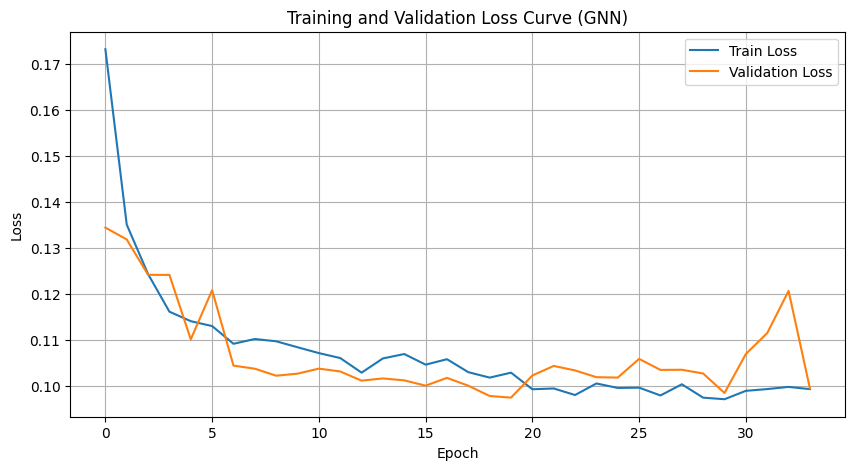


📊 Classification Report - Train (GAT-H_4-G_sum)
              precision    recall  f1-score   support

     Class 0     0.9152    0.3088    0.4618       489
     Class 1     0.9738    0.9989    0.9862     12571

    accuracy                         0.9730     13060
   macro avg     0.9445    0.6538    0.7240     13060
weighted avg     0.9716    0.9730    0.9665     13060




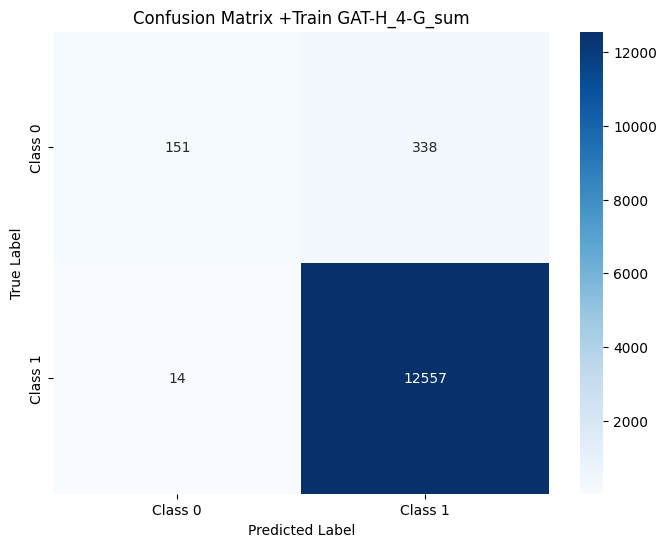

The function took 1.1321 seconds to execute.

📊 Classification Report - Validation (GAT-H_4-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8500    0.2787    0.4198       122
     Class 1     0.9727    0.9981    0.9852      3143

    accuracy                         0.9712      3265
   macro avg     0.9114    0.6384    0.7025      3265
weighted avg     0.9681    0.9712    0.9641      3265




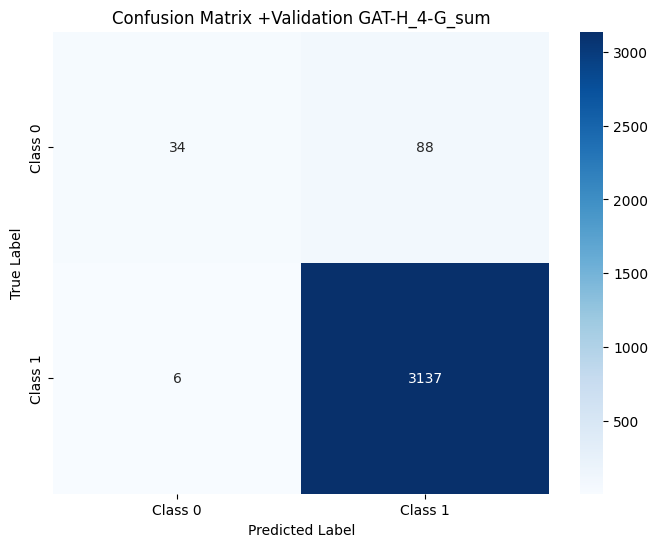

The function took 0.3458 seconds to execute.

📊 Classification Report - Test (GAT-H_4-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7761    0.2140    0.3355       243
     Class 1     0.9703    0.9976    0.9838      6262

    accuracy                         0.9683      6505
   macro avg     0.8732    0.6058    0.6596      6505
weighted avg     0.9631    0.9683    0.9596      6505




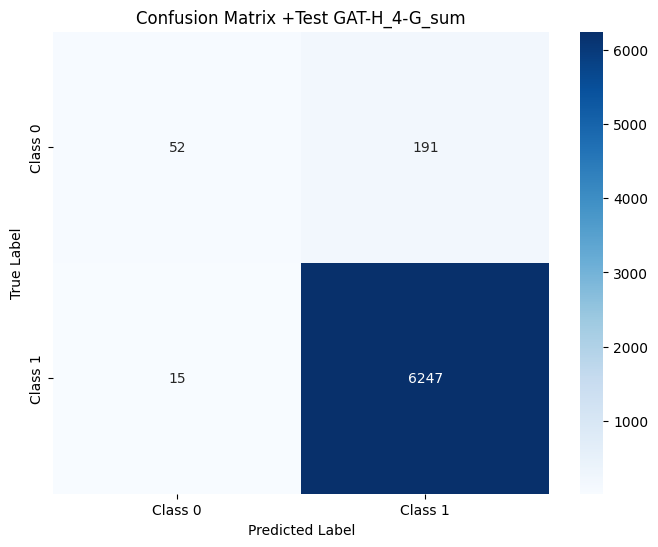

The function took 1.4282 seconds to execute.
▶▶▶ Result | Train: 97.30% | Val: 97.12% | Test: 96.83%

Start Experiment ───▶ [Heads: 8] | [Global Readout: mean]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:11<03:36,  2.28s/it]

Epoch 5/100 | Train Loss: 0.1171 | Val Loss: 0.1169


Training Epochs:  10%|█         | 10/100 [00:23<03:23,  2.27s/it]

Epoch 10/100 | Train Loss: 0.1123 | Val Loss: 0.1135


...

Epoch 45/100 | Train Loss: 0.1017 | Val Loss: 0.1051


Training Epochs:  50%|█████     | 50/100 [01:55<01:51,  2.24s/it]

Epoch 50/100 | Train Loss: 0.0985 | Val Loss: 0.1126


Training Epochs:  52%|█████▏    | 52/100 [02:02<01:53,  2.36s/it]


[Early Stopping] Triggered at epoch 53. No improvement over 15 consecutive epochs.
Epoch 53/100 | Final Train Loss: 0.0993 | Final Val Loss: 0.1119

Training complete. Execution time: 122.73 seconds.
Successfully restored the best model weights from 'best_model.pth'.


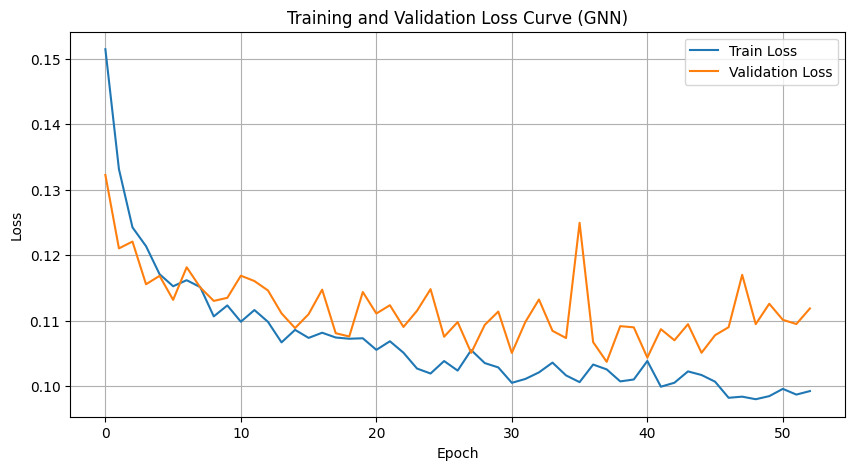


📊 Classification Report - Train (GAT-H_8-G_mean)
              precision    recall  f1-score   support

     Class 0     0.9007    0.2781    0.4250       489
     Class 1     0.9727    0.9988    0.9856     12571

    accuracy                         0.9718     13060
   macro avg     0.9367    0.6385    0.7053     13060
weighted avg     0.9700    0.9718    0.9646     13060




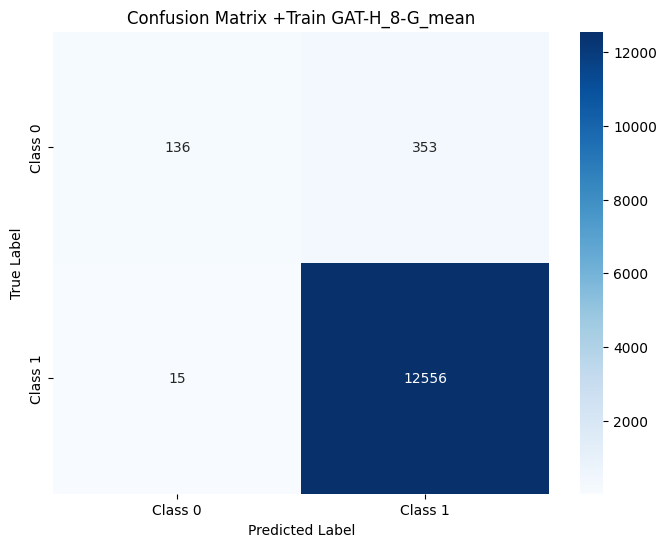

The function took 1.1908 seconds to execute.

📊 Classification Report - Validation (GAT-H_8-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7500    0.2459    0.3704       122
     Class 1     0.9715    0.9968    0.9840      3143

    accuracy                         0.9688      3265
   macro avg     0.8607    0.6214    0.6772      3265
weighted avg     0.9632    0.9688    0.9611      3265




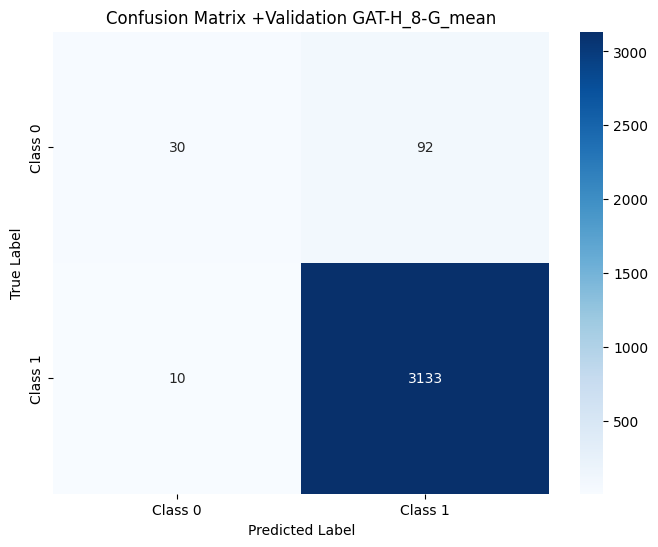

The function took 0.3530 seconds to execute.

📊 Classification Report - Test (GAT-H_8-G_mean)
              precision    recall  f1-score   support

     Class 0     0.7170    0.1564    0.2568       243
     Class 1     0.9682    0.9976    0.9827      6262

    accuracy                         0.9662      6505
   macro avg     0.8426    0.5770    0.6197      6505
weighted avg     0.9588    0.9662    0.9556      6505




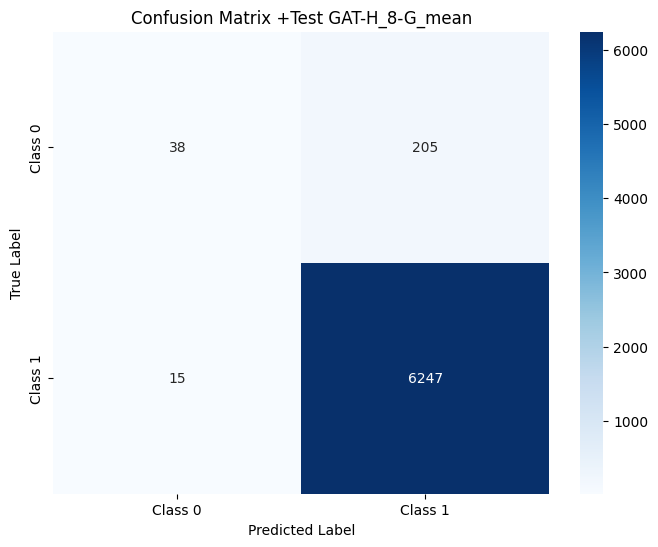

The function took 0.6341 seconds to execute.
▶▶▶ Result | Train: 97.18% | Val: 96.88% | Test: 96.62%

Start Experiment ───▶ [Heads: 8] | [Global Readout: max]
----------------------------------------------------------------------


Training Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
Training Epochs:   5%|▌         | 5/100 [00:12<03:47,  2.39s/it]

Epoch 5/100 | Train Loss: 0.1198 | Val Loss: 0.1316


Training Epochs:  10%|█         | 10/100 [00:23<03:28,  2.31s/it]

Epoch 10/100 | Train Loss: 0.1090 | Val Loss: 0.1146


...

Epoch 40/100 | Train Loss: 0.1003 | Val Loss: 0.1095


Training Epochs:  45%|████▌     | 45/100 [01:47<02:20,  2.55s/it]

Epoch 45/100 | Train Loss: 0.1040 | Val Loss: 0.1100


Training Epochs:  49%|████▉     | 49/100 [01:58<02:03,  2.43s/it]


[Early Stopping] Triggered at epoch 50. No improvement over 15 consecutive epochs.
Epoch 50/100 | Final Train Loss: 0.1002 | Final Val Loss: 0.1065

Training complete. Execution time: 118.99 seconds.
Successfully restored the best model weights from 'best_model.pth'.


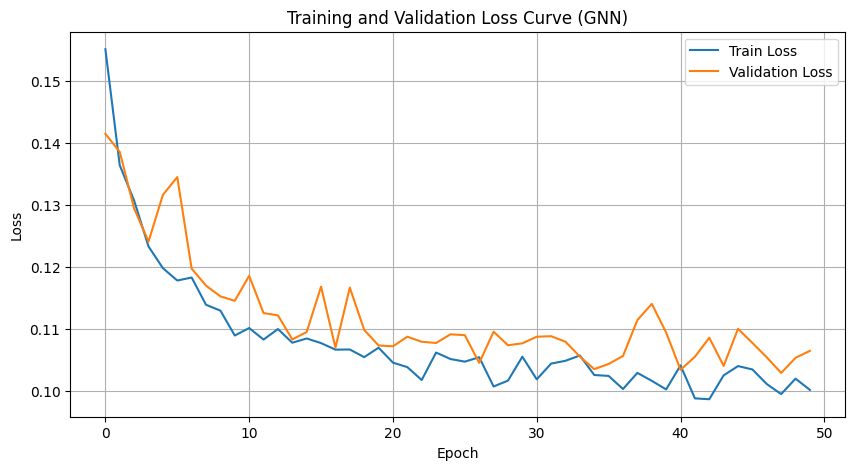


📊 Classification Report - Train (GAT-H_8-G_max)
              precision    recall  f1-score   support

     Class 0     0.9286    0.1063    0.1908       489
     Class 1     0.9664    0.9997    0.9828     12571

    accuracy                         0.9662     13060
   macro avg     0.9475    0.5530    0.5868     13060
weighted avg     0.9650    0.9662    0.9531     13060




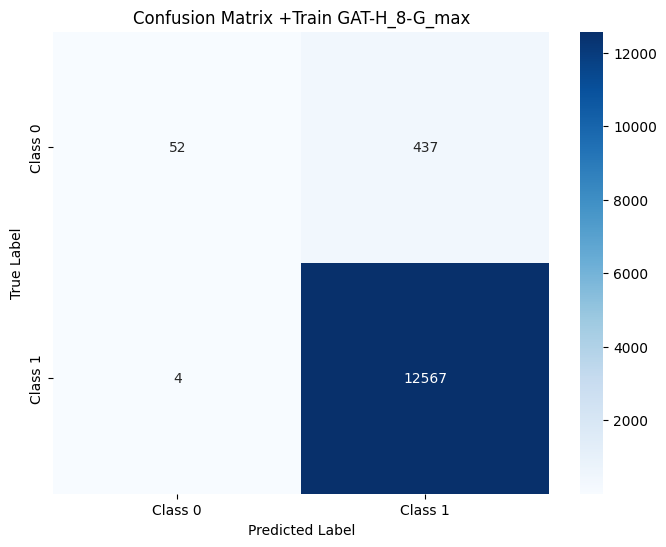

The function took 1.1934 seconds to execute.

📊 Classification Report - Validation (GAT-H_8-G_max)
              precision    recall  f1-score   support

     Class 0     0.9091    0.0820    0.1504       122
     Class 1     0.9656    0.9997    0.9823      3143

    accuracy                         0.9654      3265
   macro avg     0.9373    0.5408    0.5664      3265
weighted avg     0.9635    0.9654    0.9512      3265




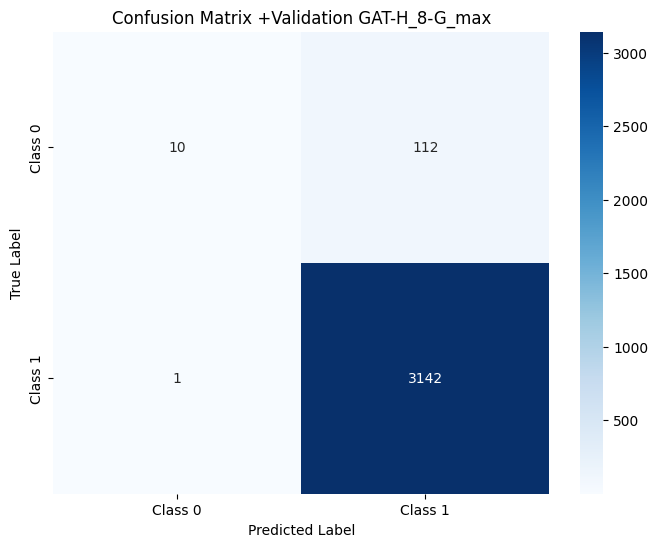

The function took 0.3337 seconds to execute.

📊 Classification Report - Test (GAT-H_8-G_max)
              precision    recall  f1-score   support

     Class 0     0.7778    0.0864    0.1556       243
     Class 1     0.9657    0.9990    0.9821      6262

    accuracy                         0.9650      6505
   macro avg     0.8718    0.5427    0.5688      6505
weighted avg     0.9587    0.9650    0.9512      6505




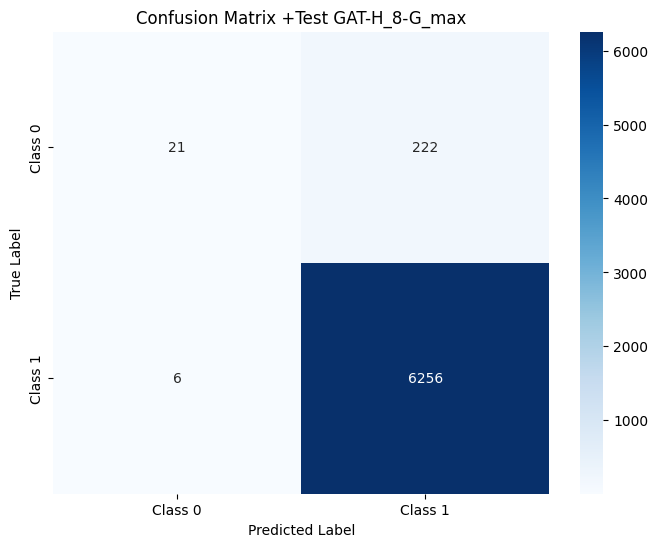

The function took 0.6076 seconds to execute.
▶▶▶ Result | Train: 96.62% | Val: 96.54% | Test: 96.50%

Start Experiment ───▶ [Heads: 8] | [Global Readout: sum]
----------------------------------------------------------------------


Training Epochs:   5%|▌         | 5/100 [00:11<03:29,  2.20s/it]

Epoch 5/100 | Train Loss: 0.1103 | Val Loss: 0.1126


Training Epochs:  10%|█         | 10/100 [00:23<03:30,  2.34s/it]

Epoch 10/100 | Train Loss: 0.1047 | Val Loss: 0.1163


...

Epoch 45/100 | Train Loss: 0.0980 | Val Loss: 0.1041


Training Epochs:  50%|█████     | 50/100 [01:55<01:51,  2.22s/it]

Epoch 50/100 | Train Loss: 0.0939 | Val Loss: 0.0996


Training Epochs:  52%|█████▏    | 52/100 [02:02<01:53,  2.36s/it]


[Early Stopping] Triggered at epoch 53. No improvement over 15 consecutive epochs.
Epoch 53/100 | Final Train Loss: 0.0939 | Final Val Loss: 0.1134

Training complete. Execution time: 122.82 seconds.
Successfully restored the best model weights from 'best_model.pth'.


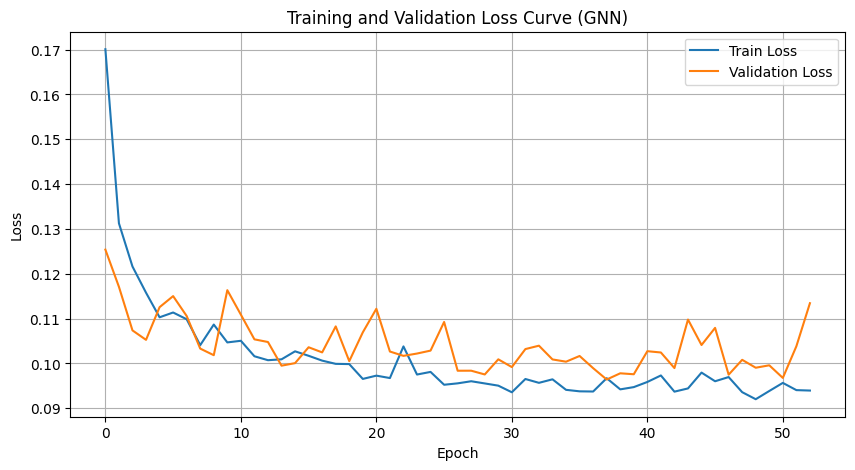


📊 Classification Report - Train (GAT-H_8-G_sum)
              precision    recall  f1-score   support

     Class 0     0.8547    0.4090    0.5533       489
     Class 1     0.9775    0.9973    0.9873     12571

    accuracy                         0.9753     13060
   macro avg     0.9161    0.7031    0.7703     13060
weighted avg     0.9729    0.9753    0.9710     13060




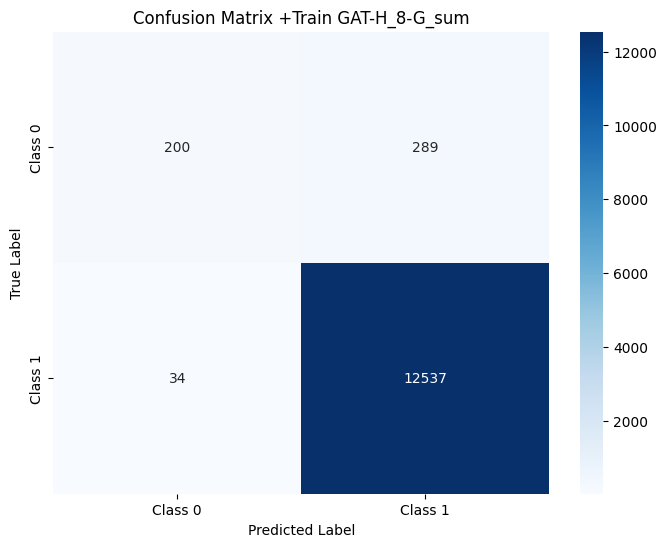

The function took 1.2018 seconds to execute.

📊 Classification Report - Validation (GAT-H_8-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7925    0.3443    0.4800       122
     Class 1     0.9751    0.9965    0.9857      3143

    accuracy                         0.9721      3265
   macro avg     0.8838    0.6704    0.7328      3265
weighted avg     0.9683    0.9721    0.9668      3265




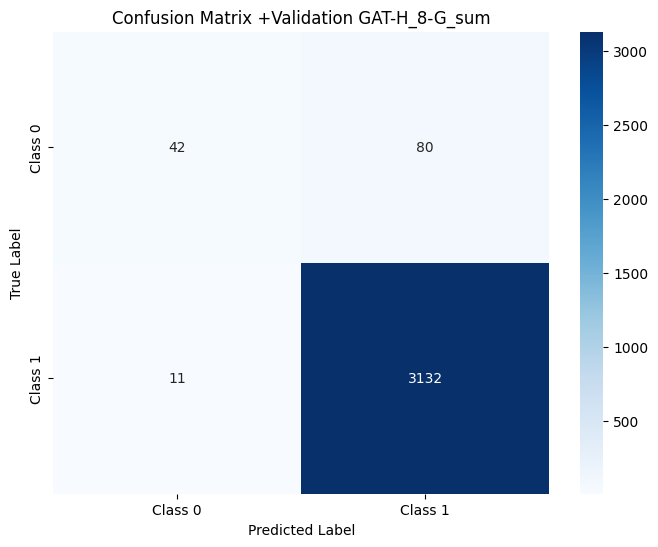

The function took 1.0254 seconds to execute.

📊 Classification Report - Test (GAT-H_8-G_sum)
              precision    recall  f1-score   support

     Class 0     0.7576    0.3086    0.4386       243
     Class 1     0.9738    0.9962    0.9848      6262

    accuracy                         0.9705      6505
   macro avg     0.8657    0.6524    0.7117      6505
weighted avg     0.9657    0.9705    0.9644      6505




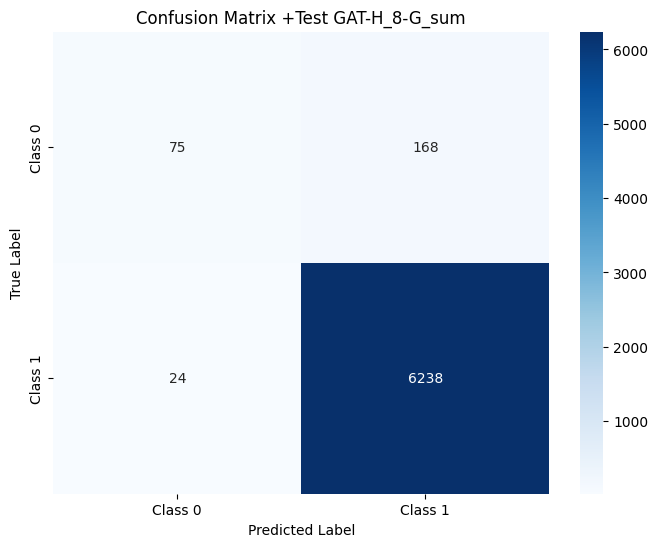

The function took 0.6393 seconds to execute.
▶▶▶ Result | Train: 97.53% | Val: 97.21% | Test: 97.05%

🏆 ALL GAT EXPERIMENTS COMPLETED!
 Attention_Heads Global_Aggregation  Train_Acc_%  Val_Acc_%  Test_Acc_%
               1               mean        96.84      96.81       96.57
               1                max        96.26      96.26       96.28
               1                sum        96.79      96.66       96.51
               4               mean        96.72      96.57       96.51
               4                max        96.80      96.66       96.57
               4                sum        97.30      97.12       96.83
               8               mean        97.18      96.88       96.62
               8                max        96.62      96.54       96.50
               8                sum        97.53      97.21       97.05


In [20]:
import pandas as pd
import torch

OPTIMIZER_LR = 0.002      # Stable learning rate sweet spot for multi-head attention weights

# 2D variation space: Attention Heads vs Global Graph Pooling Functions (3 x 3 = 9 variations)
attention_heads = [1, 4, 8]
global_aggregations = ['mean', 'max', 'sum']

# List to collect metric records across grid states
experimental_summary = []

print("============================================================")
print("🚀 Starting Streamlined Grid Search for GAT (9 Variations)...")
print(f"🔧 Configured Learning Rate: {OPTIMIZER_LR}")
print("============================================================")

for heads in attention_heads:
    for global_aggr in global_aggregations:
        
        print(f"\nStart Experiment ───▶ [Heads: {heads}] | [Global Readout: {global_aggr}]")
        print("-" * 70)
        
        # Initialize GAT model instance with current multi-head and readout configuration
        model = GAT(
            vocabulary_size=len(global_vocab_to_id),
            embedding_dim=FIXED_EMBEDDING_DIM,
            hidden_dim=FIXED_HIDDEN_DIM,
            output_dim=2,
            heads=heads,
            global_aggr=global_aggr,
            dropout_p=0.4
        ).to(device)
        
        # Reset optimizer to bind safely to the freshly minted parameter tree
        optimizer = torch.optim.Adam(model.parameters(), lr=OPTIMIZER_LR, weight_decay=5e-4)
        criterion = torch.nn.CrossEntropyLoss()
        
        # Stage 1: Train model using our early stopping training cycle
        training_loop(
            model=model, train_loader=train_loader, val_loader=val_loader,
            train_dataset=train_dataset, val_dataset=val_dataset,
            device=device, optimizer=optimizer, num_epochs=MAX_EPOCHS,
            criterion=criterion, patience=PATIENCE, min_delta=0.001
        )
        
        # Stage 2: Run diagnostic metric evaluations across splits
        current_model_tag = f"GAT-H_{heads}-G_{global_aggr}"
        train_acc = testing_model(model, train_loader, device, "Train", current_model_tag)
        val_acc = testing_model(model, val_loader, device, "Validation", current_model_tag)
        test_acc = testing_model(model, test_loader, device, "Test", current_model_tag)
        
        print(f"▶▶▶ Result | Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Test: {test_acc:.2f}%")
        
        # Stage 3: Collect current metric parameters for reporting structures
        experimental_summary.append({
            'Attention_Heads': heads,
            'Global_Aggregation': global_aggr,
            'Train_Acc_%': round(train_acc, 2),
            'Val_Acc_%': round(val_acc, 2),
            'Test_Acc_%': round(test_acc, 2)
        })

# Output the comprehensive GAT diagnostic table to console
df_results = pd.DataFrame(experimental_summary)
print("\n" + "=" * 80)
print("🏆 ALL GAT EXPERIMENTS COMPLETED!")
print("=" * 80)
print(df_results.to_string(index=False))

# Export data matrix out to a localized CSV format
df_results.to_csv('gat_aggregation_results.csv', index=False)